# 포트폴리오 검토 안내

> 이 노트북은 대출 상품별 고객 프로필을 분석해 안정적 이자이익과 잠재고객 관리 방향을 제안한 실제 해커톤 산출물입니다.

## 이 노트북에서 확인할 것

- 원화대출과 상품군별 고객 특성 비교
- 생애주기·기존 거래 관계를 반영한 잠재고객 해석
- 상품별 신규 발굴과 기존 고객 관리 방향

## 공개 범위와 실행 상태

- 원본 입력 파일 `data/hacktho_FF_final.csv`는 금융 고객 데이터로 공개하지 않습니다.
- 저장된 그래프와 지표는 당시 분석 결과이며, 고객 단위 표와 긴 탐색 출력은 공개본에서 제거했습니다.
- 원본 입력이 없으므로 현재 저장소에서 위에서 아래로 재실행되지는 않습니다. 전략 해석은 [결과 및 전략](../docs/results.md), 전체 흐름은 [README](../README.md)에서 확인하세요.

- 반복 탐색 출력은 제거하고 핵심 대출 분포 차트 4개만 남겼습니다. 최종 전략 시각화는 [README](../README.md)의 실제 발표 슬라이드에서 확인하세요.


### 아래 분석에서 만든 그래프들은 excel에서 다시 그려서 보고서, PPT에 사용하였음

In [ ]:
import pandas as pd

In [ ]:
# 부산은행 데이터 불러오기
from pathlib import Path

repository_root = Path.cwd().resolve()
if repository_root.name == 'notebooks':
    repository_root = repository_root.parent
df = pd.read_csv(repository_root / 'data' / 'hacktho_FF_final.csv')


### 한글 폰트 설치

In [65]:
# === Korean font bootstrap (run this once before plotting) ===
import os, sys, platform, urllib.request
import matplotlib, matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from pathlib import Path
import subprocess

def _has_font(name: str) -> bool:
    return any(f.name == name for f in fm.fontManager.ttflist)

def _set_font(name: str):
    matplotlib.rcParams["font.family"] = name
    matplotlib.rcParams["axes.unicode_minus"] = False
    print(f"[KOR FONT] 적용 폰트: {name}")

def apply_korean_font(local_font_path: str = None, try_download: bool = True):
    # 1) 시스템 기본 후보
    os_name = platform.system().lower()
    candidates = []
    if "windows" in os_name:
        candidates += ["Malgun Gothic"]
    elif "darwin" in os_name:
        candidates += ["AppleGothic"]
    candidates += [
        "NanumGothic", "Nanum Gothic",
        "Noto Sans CJK KR", "Noto Sans KR",
        "Spoqa Han Sans", "Batang", "Gulim", "Dotum"
    ]

    # 1-a) 이미 설치된 폰트 중에서 선택
    for name in candidates:
        if _has_font(name):
            _set_font(name)
            return name

    # 2) koreanize-matplotlib 시도 (자동으로 한글 폰트 세팅)
    try:
        import koreanize_matplotlib  # noqa
        matplotlib.rcParams["axes.unicode_minus"] = False
        print("[KOR FONT] koreanize-matplotlib 사용")
        return "koreanize_matplotlib_default"
    except Exception:
        # 설치 시도
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "koreanize-matplotlib"])
            import koreanize_matplotlib  # noqa
            matplotlib.rcParams["axes.unicode_minus"] = False
            print("[KOR FONT] koreanize-matplotlib 설치 후 적용")
            return "koreanize_matplotlib_default"
        except Exception:
            pass  # 계속 진행

    # 3) 사용자가 직접 준 폰트 파일 경로 등록
    if local_font_path and Path(local_font_path).exists():
        try:
            fm.fontManager.addfont(local_font_path)
            fm._rebuild()
            # 파일명으로 폰트 이름 추정
            # 등록 후 목록에서 최근 추가 항목의 name을 사용
            added_name = sorted(fm.fontManager.ttflist, key=lambda f: f.fname == local_font_path)[-1].name
            _set_font(added_name)
            return added_name
        except Exception as e:
            print(f"[WARN] 로컬 폰트 등록 실패: {e}")

    # 4) 마지막 수단: Noto Sans CJK KR 다운로드(네트워크 필요)
    if try_download:
        try:
            url = "https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/Korean/NotoSansCJKkr-Regular.otf"
            dest = Path.home() / ".matplot_kor_font" / "NotoSansCJKkr-Regular.otf"
            dest.parent.mkdir(parents=True, exist_ok=True)
            if not dest.exists():
                print(f"[DL] 다운로드 중… {url}")
                urllib.request.urlretrieve(url, dest)  # 네트워크 허용 환경에서만 동작
            fm.fontManager.addfont(str(dest))
            fm._rebuild()
            # 등록된 이름 찾기
            for f in fm.fontManager.ttflist:
                if f.fname == str(dest):
                    _set_font(f.name)
                    return f.name
            # fallback: 이름 모를 경우 직접 family에 파일 경로 지정은 불가 → 첫 번째 Noto 계열 찾기
            for name in ["Noto Sans CJK KR", "Noto Sans KR"]:
                if _has_font(name):
                    _set_font(name)
                    return name
        except Exception as e:
            print(f"[WARN] 다운로드/등록 실패: {e}")

    print("[KOR FONT] 한글 폰트를 여전히 찾지 못했습니다.")
    print(" - 해결책 A) 아래 경로 중 하나의 .ttf/.otf 파일을 local_font_path로 지정해 다시 실행:")
    print("    • Windows: C:/Windows/Fonts/malgun.ttf")
    print("    • macOS:   /Library/Fonts/AppleGothic.ttf")
    print("    • Linux:   /usr/share/fonts/truetype/nanum/NanumGothic.ttf (또는 NotoSansCJK *.otf)")
    print(" - 해결책 B) pip install koreanize-matplotlib 후 다시 실행")
    print(" - 해결책 C) 인터넷 가능 시 try_download=True 유지")

# === 여기서 한 가지 옵션을 선택 ===
# 1) 그냥 자동 시도 (추천)
apply_korean_font()

# 2) 로컬 폰트 파일 경로를 아신다면 지정 (예시)
# apply_korean_font(local_font_path="/usr/share/fonts/truetype/nanum/NanumGothic.ttf", try_download=False)

# 3) 네트워크 허용이면 자동 다운로드 허용 (기본값 True)
# apply_korean_font(try_download=True)

# 테스트 텍스트 (원하면 주석 해제)
# plt.figure()
# plt.title("한글 테스트: 급여/관계/구간 분포")
# plt.plot([0,1,2],[1,2,3])
# plt.show()


### 변수명 다시 영어로 개조

In [66]:
df.columns = [str(c).strip() for c in df.columns]

In [67]:
rename_map = {
'연령대': 'age_range',
'성별': 'gender',
'광역시도': 'region_1',
'시군구': 'region_2',
'고객등급구분코드': 'cust_grade',
'직업구분코드': 'job_dv',
'외국인여부': 'foreigner_yn',
'연체 이력 여부': 'delinq_hist_yn',
'모바일뱅킹 등록 여부': 'mob_yn',
'오픈뱅킹 가입 여부': 'openbank_yn',
'창구 방문 업무1': 'cntr_svc_1',
'창구 방문 업무2': 'cntr_svc_2',
'창구 방문 업무3': 'cntr_svc_3',
'급여이체 등록 여부': 'patroll_trf_yn',
'원화대출잔액': 'won_loan_range',
'주택담보대출': 'mortgage_loan_range',
'전세대출': 'cred_loan_range',
'소액대출': 'micro_loan_range',
'서민대출': 'lowinc_loan_range',
'기업대출잔액': 'cor_loan_range',
'입출금식예금평잔': 'inout_bal_range',
'적립식예금평잔': 'saving_bal_range',
'거치식예금평잔': 'deposit_bal_range',
'기타예금평잔': 'etc_bal_range',
'펀드잔액': 'fund_bal_range',
'방카슈랑스잔액': 'banca_bal_range',
'자산평잔_경남은행': 'knb_ast_range',
'자산평잔_투자증권': 'fn_ast_range',
'자산평잔_저축은행': 'sb_ast_range',
'신용카드 거래액 합계': 'cc_txn_amt_range',
'체크카드 거래액 합계': 'chk_txn_amt_range',
'신용카드 거래횟수': 'cc_txn_cnt_range',
'체크카드 거래횟수': 'chk_txn_cnt_range',
'자동이체 등록 수': 'auto_trf_reg_cnt_range',
'모바일 이체 횟수': 'mob_cnt_range',
'자동화기기 이용 횟수': 'atm_use_cnt_range',
'제휴 대출 보유 여부': 'partner_loan_yn',
'가입 기간': 'join_period_range',
'창구 방문 업무1 횟수': 'cntr_svc_1_cnt_range',
'창구 방문 업무2 횟수': 'cntr_svc_2_cnt_range',
'창구 방문 업무3 횟수': 'cntr_svc_3_cnt_range',
# '비이자수익 군집'은 그대로 두고,
'이자수익 군집': 'iz_cluster', # 이것만 바꿈
# 'Unnamed: 0'은 매핑 제외(그대로 유지)
}

In [68]:
to_apply = {k: v for k, v in rename_map.items() if k in df.columns}
df = df.rename(columns=to_apply)

# -----------------------------------------------------

# 기존 데이터 eda (df) 기준

### 입출금식예금평잔 분포

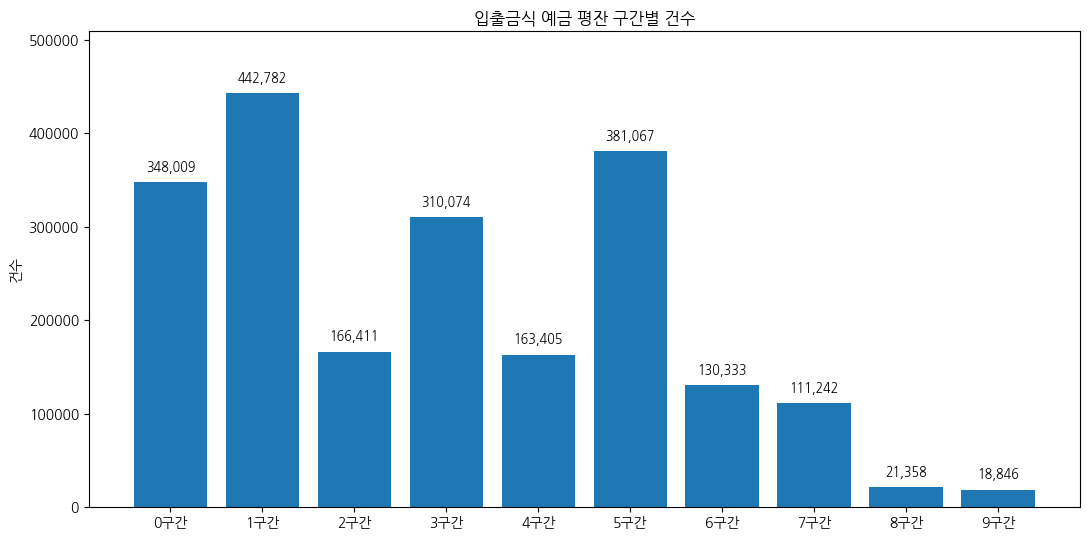

In [69]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트가 있다면 자동 적용(없어도 실행 가능)
try:
    import koreanize_matplotlib  # noqa
except Exception:
    pass

# --- 유틸: 값 -> 'x구간' 라벨로 통일 ---
def to_bin_label(x, keep_na=True):
    if pd.isna(x):
        return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)):       # 3 -> '3구간'
        return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x):# 3.0 -> '3구간'
        return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)           # '3구간' -> '3구간'
    if m:
        return f"{int(m.group(1))}구간"
    # '3' / '3.0' -> '3구간' 시도
    try:
        b = int(float(s))
        return f"{b}구간"
    except:
        return s  # 숫자 구간이 아니면 원문 유지

# --- 본 그래프 그리기 ---
def plot_inout_counts(df, col="inout_bal_range", bins=10, title=None, savepath=None):
    if col not in df.columns:
        raise KeyError(f"데이터프레임에 '{col}' 컬럼이 없습니다.")

    s = df[col].map(lambda x: to_bin_label(x, keep_na=False))
    # 0~(bins-1) 구간 우선 정렬, 나머지 라벨은 뒤에
    base_labels = [f"{i}구간" for i in range(bins)]
    counts = s.value_counts(dropna=False)

    # 지정 구간 카운트 (없으면 0으로)
    ordered = counts.reindex(base_labels, fill_value=0)

    # 그 외 라벨이 있으면 뒤에 붙이기
    others = counts[~counts.index.isin(base_labels)]
    if len(others):
        ordered = pd.concat([ordered, others])

    # 플롯
    x = np.arange(len(ordered))
    plt.figure(figsize=(11, 5.5))
    bars = plt.bar(x, ordered.values)
    plt.xticks(x, ordered.index, rotation=0)
    plt.ylabel("건수")
    ttl = title or f"{col} 구간별 건수"
    plt.title(ttl)

    ymax = ordered.max()
    plt.ylim(0, max(5, ymax * 1.15))

    # 막대 위에 숫자 라벨(천단위 콤마)
    for b, v in zip(bars, ordered.values):
        if v > 0:
            plt.text(b.get_x() + b.get_width()/2, b.get_height() + ymax*0.02,
                     f"{int(v):,}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=200)
    plt.show()

# 사용 예시
plot_inout_counts(df, col="inout_bal_range", bins=10, title="입출금식 예금 평잔 구간별 건수")
# 파일 저장하려면:
# plot_inout_counts(df, col="inout_bal_range", bins=10, savepath="inout_bal_range_counts.png")


# 초기군집별 기초 eda

### 각 집군을 df0 df1 df2으로 설정

In [70]:
df0 = df[df["iz_cluster"] == 0].copy()
df1 = df[df["iz_cluster"] == 1].copy()
df2 = df[df["iz_cluster"] == 2].copy()

### 집군 내 won 변수의 구간별 count

In [71]:
import pandas as pd
import numpy as np

# df0이 없다면 생성 (iz_cluster==0)
if "df0" not in globals():
    df0 = df[df["iz_cluster"] == 0].copy()

# 혼용된 표기(숫자/문자)를 'x구간'으로 통일
def to_binlabel(s: pd.Series) -> pd.Series:
    s = s.astype("string").str.replace(r"\s+", "", regex=True)
    only_num = s.str.fullmatch(r"\d+")
    s = s.mask(only_num, s + "구간")
    return s

# 0~9구간 순서대로 카운트 집계
bin_order = [f"{i}구간" for i in range(10)]
counts_df = (
    to_binlabel(df0["won_loan_range"])
    .value_counts()
    .reindex(bin_order)
    .fillna(0)
    .astype(int)
    .to_frame(name="count")
)

print(counts_df)


In [72]:
import pandas as pd
import numpy as np


# 혼용된 표기(숫자/문자)를 'x구간'으로 통일
def to_binlabel(s: pd.Series) -> pd.Series:
    s = s.astype("string").str.replace(r"\s+", "", regex=True)
    only_num = s.str.fullmatch(r"\d+")
    s = s.mask(only_num, s + "구간")
    return s

# 0~9구간 순서대로 카운트 집계
bin_order = [f"{i}구간" for i in range(10)]
counts_df = (
    to_binlabel(df1["won_loan_range"])
    .value_counts()
    .reindex(bin_order)
    .fillna(0)
    .astype(int)
    .to_frame(name="count")
)

print(counts_df)


In [73]:
import pandas as pd
import numpy as np


# 혼용된 표기(숫자/문자)를 'x구간'으로 통일
def to_binlabel(s: pd.Series) -> pd.Series:
    s = s.astype("string").str.replace(r"\s+", "", regex=True)
    only_num = s.str.fullmatch(r"\d+")
    s = s.mask(only_num, s + "구간")
    return s

# 0~9구간 순서대로 카운트 집계
bin_order = [f"{i}구간" for i in range(10)]
counts_df = (
    to_binlabel(df2["won_loan_range"])
    .value_counts()
    .reindex(bin_order)
    .fillna(0)
    .astype(int)
    .to_frame(name="count")
)

print(counts_df)


### 집군내 변수별 총 잔액합계 순위

In [74]:
import pandas as pd

# ---------------------------------------------
# 클러스터별( df0 / df1 / df2 ) 여신 변수 총 잔액합계 표 생성 (한 번에)
# - 가정: df0, df1, df2 가 이미 존재(iz_cluster==0/1/2 필터 결과)
#   * 만약 없다면 아래 주석 해제해서 자동 생성 가능
# ---------------------------------------------

# # (옵션) df0/df1/df2 자동 생성
# df0 = df[df["iz_cluster"] == 0].copy()
# df1 = df[df["iz_cluster"] == 1].copy()
# df2 = df[df["iz_cluster"] == 2].copy()

# 구간 → 중앙값 매핑
bin_to_median = {
    "0구간": 0,
    "1구간": 1500000,
    "2구간": 6500000,
    "3구간": 15000000,
    "4구간": 25000000,
    "5구간": 40000000,
    "6구간": 75000000,
    "7구간": 200000000,
    "8구간": 400000000,
    "9구간": 600000000
}

# 혼용 표기(숫자/문자) 통일: '3' -> '3구간'
def to_binlabel(s: pd.Series) -> pd.Series:
    s = s.astype("string").str.replace(r"\s+", "", regex=True)
    only_num = s.str.fullmatch(r"\d+")
    return s.mask(only_num, s + "구간")

# 중앙값 금액으로 변환
def to_mid_amount(s: pd.Series, mapping: dict) -> pd.Series:
    lab = to_binlabel(s)
    amt = lab.map(mapping)
    return pd.to_numeric(amt, errors="coerce").fillna(0)

# 대상 변수
loan_vars = [
    "mortgage_loan_range",  # 주담대
    "cred_loan_range",      # 전세
    "micro_loan_range",     # 소액
    "lowinc_loan_range",    # 서민
    "cor_loan_range",       # 기업
    "won_loan_range"        # 전체(참고용)
]

# 단일 클러스터(df0/df1/df2)에 대한 합계표 생성
def totals_for(df_cluster: pd.DataFrame, cluster_name: str) -> pd.DataFrame:
    rows = []
    for c in loan_vars:
        if c not in df_cluster.columns:
            continue
        amt = to_mid_amount(df_cluster[c], bin_to_median)
        total = float(amt.sum())
        rows.append({
            "cluster": cluster_name,
            "variable": c,
            "total_amount": total,           # 원
            "amount_억원": total / 1e8,
            "amount_조원": total / 1e12
        })
    return (pd.DataFrame(rows)
            .sort_values("total_amount", ascending=False)
            .reset_index(drop=True))

# 실행
totals_0 = totals_for(df0, "0")
totals_1 = totals_for(df1, "1")
totals_2 = totals_for(df2, "2")

print("\n[클러스터 0] 변수별 총 잔액합계 순위")
print(totals_0.to_string(index=False))

print("\n[클러스터 1] 변수별 총 잔액합계 순위")
print(totals_1.to_string(index=False))

print("\n[클러스터 2] 변수별 총 잔액합계 순위")
print(totals_2.to_string(index=False))

# (옵션) 세 클러스터 통합표
totals_all = pd.concat([totals_0, totals_1, totals_2], ignore_index=True)
print("\n[통합] 클러스터별 변수 총 잔액합계 (cluster별 내림차순)")
print(totals_all.sort_values(["cluster", "total_amount"], ascending=[True, False]).to_string(index=False))


In [75]:
import pandas as pd
import numpy as np

# ---------------------------------------------
# 클러스터별( df0 / df1 / df2 ) 여신 변수 총합 + 1인당 평균
# - 가정: df0, df1, df2 가 이미 존재(iz_cluster==0/1/2 필터 결과)
# ---------------------------------------------

# 구간 → 중앙값 매핑
bin_to_median = {
    "0구간": 0,
    "1구간": 1_500_000,
    "2구간": 6_500_000,
    "3구간": 15_000_000,
    "4구간": 25_000_000,
    "5구간": 40_000_000,
    "6구간": 75_000_000,
    "7구간": 200_000_000,
    "8구간": 400_000_000,
    "9구간": 600_000_000
}

# 혼용 표기(숫자/문자) 통일: '3' -> '3구간'
def to_binlabel(s: pd.Series) -> pd.Series:
    s = s.astype("string").str.replace(r"\s+", "", regex=True)
    only_num = s.str.fullmatch(r"\d+")
    return s.mask(only_num, s + "구간")

# 중앙값 금액으로 변환
def to_mid_amount(s: pd.Series, mapping: dict) -> pd.Series:
    lab = to_binlabel(s)
    amt = lab.map(mapping)
    return pd.to_numeric(amt, errors="coerce").fillna(0)

# 대상 변수
loan_vars = [
    "mortgage_loan_range",  # 주담대
    "cred_loan_range",      # 전세
    "micro_loan_range",     # 소액
    "lowinc_loan_range",    # 서민
    "cor_loan_range",       # 기업
    "won_loan_range"        # 전체(참고용)
]

# 단일 클러스터(df0/df1/df2)에 대한 합계 + 1인당 평균
def totals_and_avg_for(df_cluster: pd.DataFrame, cluster_name: str) -> pd.DataFrame:
    n = len(df_cluster)
    rows = []
    for c in loan_vars:
        if c not in df_cluster.columns:
            continue
        amt = to_mid_amount(df_cluster[c], bin_to_median)
        total = float(amt.sum())
        avg = (total / n) if n > 0 else np.nan
        rows.append({
            "cluster": cluster_name,
            "n_customers": n,
            "variable": c,
            "total_amount": total,            # 원
            "amount_억원": total / 1e8,
            "amount_조원": total / 1e12,
            "avg_amount_per_person": avg,     # 원/인
            "avg_만원_per_person": avg / 1e4  # 만원/인
        })
    out = (pd.DataFrame(rows)
           .sort_values("total_amount", ascending=False)
           .reset_index(drop=True))
    return out

# 실행
totals_0 = totals_and_avg_for(df0, "0")
totals_1 = totals_and_avg_for(df1, "1")
totals_2 = totals_and_avg_for(df2, "2")

print("\n[클러스터 0] 변수별 총합 + 1인당 평균")
print(totals_0.to_string(index=False))

print("\n[클러스터 1] 변수별 총합 + 1인당 평균")
print(totals_1.to_string(index=False))

print("\n[클러스터 2] 변수별 총합 + 1인당 평균")
print(totals_2.to_string(index=False))

# (옵션) 통합표
totals_all = pd.concat([totals_0, totals_1, totals_2], ignore_index=True)
print("\n[통합] 클러스터별 변수 총합 + 1인당 평균 (cluster별 total_amount 내림차순)")
print(totals_all.sort_values(["cluster", "total_amount"], ascending=[True, False]).to_string(index=False))


# 초기 0군집 전처리 (df0_0, df0_16 생성)

### 0구간인 애들의 특징

In [76]:
# df0에서 won_loan_range가 0구간인 행을 df0_0으로 만들고,
# 그 중 다른 대출변수(주담/전세/소액/서민/기업)가 5구간 이상인지 점검

import re
import numpy as np
import pandas as pd

# ---------------------------
# 1) 헬퍼: '3구간', '0', 0 등 → 정수 bin으로 변환
# ---------------------------
def bin_to_int(x):
    if pd.isna(x):
        return np.nan
    # 이미 숫자면 정수화
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    # '3구간' 패턴
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    # '0', '1' 같은 숫자 문자열
    try:
        return int(float(s))
    except:
        return np.nan

# ---------------------------
# 2) 대상 컬럼 세팅
# ---------------------------
# won_loan_range 오탈자 대비
won_candidates = [c for c in ["won_loan_range", "won_loan_rang"] if c in df0.columns]
if not won_candidates:
    raise KeyError("won_loan_range(또는 won_loan_rang) 컬럼이 df0에 없습니다.")
won_col = won_candidates[0]

other_loan_cols_all = [
    "mortgage_loan_range",  # 주담대
    "cred_loan_range",      # 전세대출
    "micro_loan_range",     # 소액대출
    "lowinc_loan_range",    # 서민대출
    "cor_loan_range"        # 기업대출
]
other_loan_cols = [c for c in other_loan_cols_all if c in df0.columns]
if not other_loan_cols:
    raise KeyError("다른 대출 변수(담보/전세/소액/서민/기업)가 df0에 없습니다.")

# ---------------------------
# 3) bin 정수화 컬럼 생성
# ---------------------------
df0 = df0.copy()
df0["_won_bin"] = df0[won_col].map(bin_to_int)

for c in other_loan_cols:
    df0[f"_{c}_bin"] = df0[c].map(bin_to_int)

# ---------------------------
# 4) won_loan 0구간 필터 → df0_0
# ---------------------------
df0_0 = df0[df0["_won_bin"] == 0].copy()

# ---------------------------
# 5) df0_0 내에서 다른 대출이 1구간 이상 있는지 점검
# ---------------------------
loan_bin_cols = [f"_{c}_bin" for c in other_loan_cols]
df0_0["has_other_loan_ge1"] = df0_0[loan_bin_cols].ge(1).any(axis=1)

df0_0_issue = df0_0[df0_0["has_other_loan_ge1"]].copy()

# ---------------------------
# 6) 요약 출력
# ---------------------------
print(f"[요약] df0 전체 행수: {len(df0)}")
print(f"[요약] won_loan 0구간(df0_0) 행수: {len(df0_0)}")
print(f"[요약] df0_0 중 다른 대출이 1구간 이상인 행수: {len(df0_0_issue)}")

print("\n[컬럼별 >=1구간 건수]")
for c, bc in zip(other_loan_cols, loan_bin_cols):
    cnt = df0_0[bc].ge(1).sum()
    print(f" - {c}: {cnt}")

print("\n[사례 상위 10건 미리보기]")
preview_cols = [won_col] + other_loan_cols + ["has_other_loan_ge1"]
print(df0_0_issue[preview_cols].head(10))

# 필요 시 다음 라인으로 df0_0, df0_0_issue를 계속 활용 가능
# df0_0.to_csv("df0_0.csv", index=False)
# df0_0_issue.to_csv("df0_0_issue_ge1.csv", index=False)


### df0_0 df0_16 정의

In [77]:
import re
import numpy as np
import pandas as pd

# --- 헬퍼: '3구간', '0구간', '0', 0 -> 정수 bin ---
def bin_to_int(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

# --- 대상 컬럼 식별(won_loan_range / won_loan_rang 대응) ---
won_candidates = [c for c in ["won_loan_range", "won_loan_rang"] if c in df0.columns]
if not won_candidates:
    raise KeyError("won_loan_range(또는 won_loan_rang) 컬럼이 df0에 없습니다.")
won_col = won_candidates[0]

# --- 분할 마스크: won == 0구간 ---
won_bin = df0[won_col].map(bin_to_int)
mask_won0 = (won_bin == 0)

# --- 분할 ---
df0_0 = df0.loc[mask_won0].copy()
df0_16 = df0.loc[~mask_won0].copy()

# --- 확인 출력 ---
print(f"df0 전체: {len(df0):,}")
print(f"df0_0 (won==0구간): {len(df0_0):,}")
print(f"df0_16 (그 외): {len(df0_16):,}")


# -----------------------------------------------------

# df0_16 (Standard 군집 정의)

### df0_16_1 (Standard 군집)

In [78]:
# df0_16에서 "won을 제외한 5개 loan 변수" 각각이 0구간인지 확인하고,
# 행별로 0구간 개수를 세어 분포(개수/비율)를 출력합니다.

import re
import numpy as np
import pandas as pd

# --- 헬퍼: '3구간', '0구간', '0', 0 -> 정수 bin ---
def bin_to_int(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

# --- 대상 데이터프레임 확인 ---
if "df0_16" not in globals():
    raise RuntimeError("df0_16이 존재하지 않습니다. 먼저 df0에서 won==0/그외로 분리하세요.")

# --- won을 제외한 5개 loan 변수 ---
loan_cols_all = [
    "mortgage_loan_range",  # 주담대
    "cred_loan_range",      # 전세대출
    "micro_loan_range",     # 소액대출
    "lowinc_loan_range",    # 서민대출
    "cor_loan_range"        # 기업대출
]
loan_cols = [c for c in loan_cols_all if c in df0_16.columns]
if len(loan_cols) != 5:
    missing = [c for c in loan_cols_all if c not in loan_cols]
    raise KeyError(f"다음 컬럼이 df0_16에 없습니다: {missing}")

# --- 0구간 여부(0/1) 만들기 ---
df = df0_16.copy()
zero_flags = {}
for c in loan_cols:
    bin_col = df[c].map(bin_to_int)
    zero_flags[c] = (bin_col == 0).astype(int)  # NaN은 False(0) 처리

zero_mat = pd.DataFrame(zero_flags, index=df.index)

# --- 행별 0구간 개수 ---
df["num_zero_loans_excl_won"] = zero_mat.sum(axis=1)

# --- 분포(개수/비율) 계산 ---
total_n = len(df)
counts = df["num_zero_loans_excl_won"].value_counts().sort_index()
# 0~5 모두 포함되도록 재색인
counts = counts.reindex(range(0, len(loan_cols)+1), fill_value=0)

summary = pd.DataFrame({
    "zero_count": counts.index,
    "n_customers": counts.values,
    "ratio": (counts.values / total_n)
})
summary["ratio_pct"] = (summary["ratio"] * 100).round(2)

# --- 출력 ---
print(f"[대상] df0_16 전체 행수: {total_n:,}")
print("\n[0구간 개수별 분포]")
print(summary.to_string(index=False))

# (선택) 결과 활용 예:
# df0_16_zero1 = df[df["num_zero_loans_excl_won"] == 1]
# df0_16_zero2 = df[df["num_zero_loans_excl_won"] == 2]


In [79]:
# df0_16 중에서 "won을 제외한 5개 loan 변수" 중 0구간이 아닌(>0) 게
# 정확히 1개인 사람들을 df0_16_1으로 정의하고,
# 그들이 어떤 대출(어느 변수)만 보유했는지 분포를 확인

import re
import numpy as np
import pandas as pd

# --- 헬퍼: '3구간', '0구간', '0', 0 -> 정수 bin ---
def bin_to_int(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

# --- 대상 데이터프레임 확인 ---
if "df0_16" not in globals():
    raise RuntimeError("df0_16이 존재하지 않습니다. 먼저 df0에서 won==0/그외로 분리하세요.")

# --- won을 제외한 5개 loan 변수 ---
loan_cols_all = [
    "mortgage_loan_range",  # 주담대
    "cred_loan_range",      # 전세대출
    "micro_loan_range",     # 소액대출
    "lowinc_loan_range",    # 서민대출
    "cor_loan_range"        # 기업대출
]
loan_cols = [c for c in loan_cols_all if c in df0_16.columns]
if len(loan_cols) != 5:
    missing = [c for c in loan_cols_all if c not in loan_cols]
    raise KeyError(f"다음 컬럼이 df0_16에 없습니다: {missing}")

# --- bin/flag 생성 ---
df = df0_16.copy()
for c in loan_cols:
    df[f"_{c}_bin"] = df[c].map(bin_to_int)
    df[f"_{c}_nonzero"] = (df[f"_{c}_bin"] > 0).astype(int)

flag_cols = [f"_{c}_nonzero" for c in loan_cols]

# --- 행별 비0구간(>0) 개수 ---
df["num_nonzero_loans_excl_won"] = df[flag_cols].sum(axis=1)

# --- 필터: 비0구간이 정확히 1개인 사람들 ---
df0_16_1 = df[df["num_nonzero_loans_excl_won"] == 1].copy()

# --- 단일 보유 대출 종류 식별(벡터화) ---
idx = df0_16_1[flag_cols].values.argmax(axis=1)  # sum==1이므로 안전
df0_16_1["single_loan_type"] = np.array(loan_cols)[idx]

# --- 요약 분포(개수/비율) ---
type_counts = df0_16_1["single_loan_type"].value_counts()
summary = (type_counts.rename_axis("loan_type")
                      .reset_index(name="n")
                      .sort_values("loan_type"))
summary["ratio"] = summary["n"] / len(df0_16_1)
summary["ratio_pct"] = (summary["ratio"] * 100).round(2)

# --- 출력 ---
print(f"[대상] df0_16 전체: {len(df0_16):,}")
print(f"[선택] df0_16_1 (won 제외 5개 중 비0구간이 정확히 1개): {len(df0_16_1):,}\n")
print("[단일 보유 대출 종류 분포]")
print(summary.to_string(index=False))

# --- 샘플 확인 ---
preview_cols = loan_cols + ["single_loan_type"]
print("\n[샘플 10건]")
print(df0_16_1[preview_cols].head(10))

# --- (선택) 중간 생성 컬럼 정리 ---
drop_cols = [f"_{c}_bin" for c in loan_cols] + flag_cols + ["num_nonzero_loans_excl_won"]
df0_16_1 = df0_16_1.drop(columns=drop_cols)


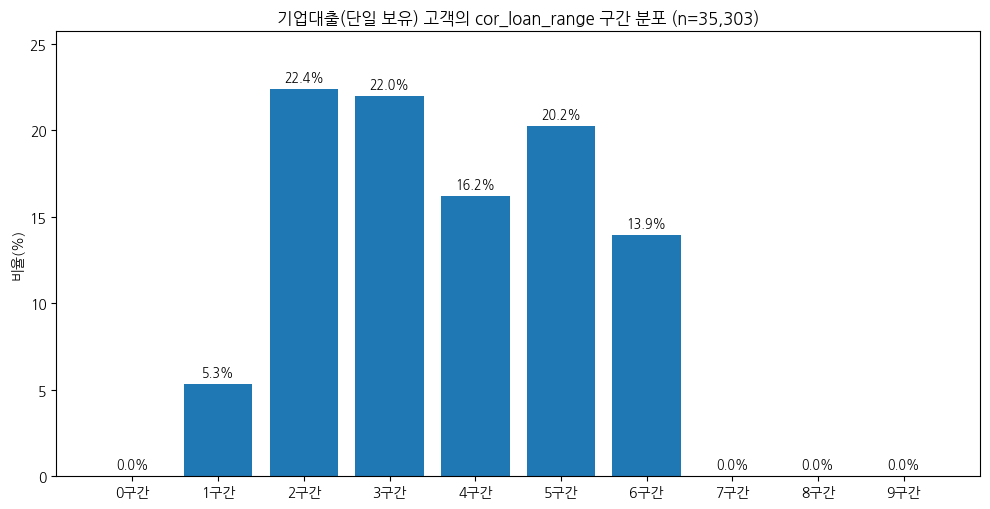

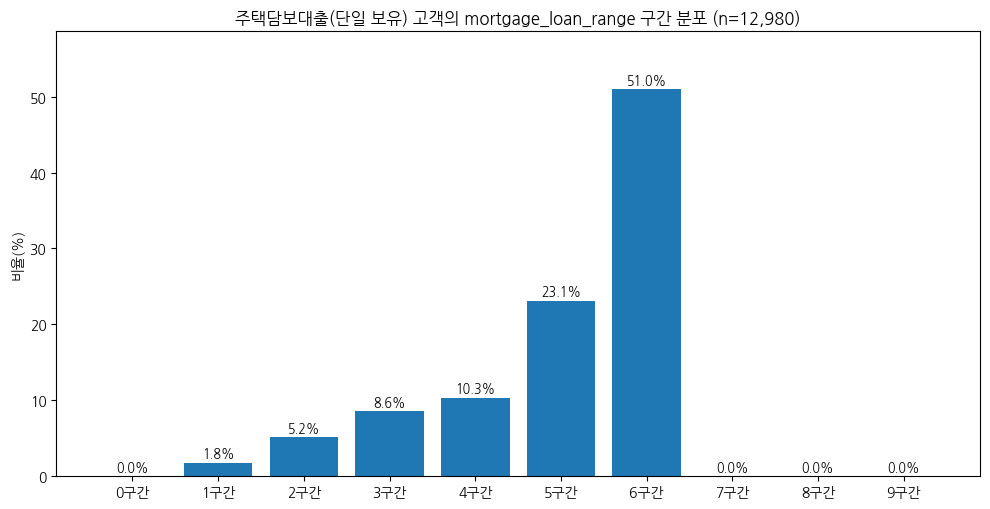

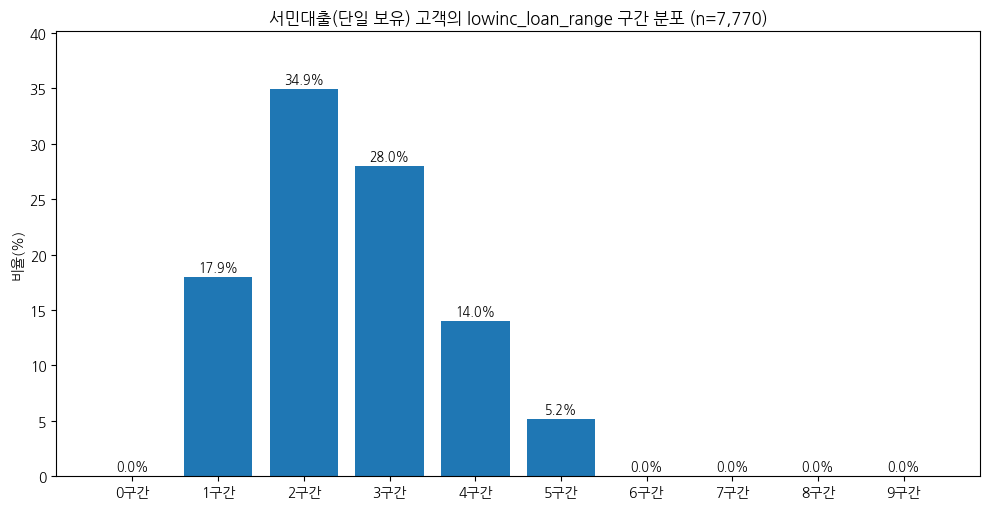

In [80]:
# df0_16_1 안에서
# - cor_loan_range, mortgage_loan_range, lowinc_loan_range 각각
#   "그 대출만 보유(single_loan_type==해당 컬럼)" 고객의 구간 분포 막대그래프 그리기 (비율 %)

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# (한글 폰트는 이미 설치/적용되었다고 가정; 안전하게 import만 시도)
try:
    import koreanize_matplotlib  # noqa
except Exception:
    pass

# --- 스칼라용: '3구간', '0구간', '0','0.0', 0 -> int ---
def bin_to_int(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

# --- 대상/라벨 ---
targets_all = ["cor_loan_range", "mortgage_loan_range", "lowinc_loan_range"]
loan_kor = {
    "cor_loan_range": "기업대출(단일 보유)",
    "mortgage_loan_range": "주택담보대출(단일 보유)",
    "lowinc_loan_range": "서민대출(단일 보유)",
}

# --- 존재 확인 ---
if "df0_16_1" not in globals():
    raise RuntimeError("df0_16_1이 없습니다.")
if "single_loan_type" not in df0_16_1.columns:
    raise RuntimeError("df0_16_1에 single_loan_type 컬럼이 없습니다. 먼저 생성하세요.")

targets = [c for c in targets_all if c in df0_16_1.columns]
if not targets:
    raise KeyError("대상 컬럼이 df0_16_1에 없습니다.")

# --- 그리기 함수 ---
def plot_bin_distribution(df, loan_col, n_bins=10):
    sub = df[df["single_loan_type"] == loan_col].copy()
    n = len(sub)
    title_label = loan_kor.get(loan_col, loan_col)
    if n == 0:
        print(f"[스킵] {title_label}: 대상 없음")
        return

    sub["_bin"] = sub[loan_col].map(bin_to_int)
    counts = sub["_bin"].value_counts(dropna=True).sort_index()
    counts = counts.reindex(range(0, n_bins), fill_value=0)

    ratio = (counts / n * 100).round(2)
    x = np.arange(n_bins)
    labels = [f"{i}구간" for i in range(n_bins)]

    plt.figure(figsize=(10, 5.2))
    bars = plt.bar(x, ratio.values)
    plt.xticks(x, labels, rotation=0)
    plt.ylabel("비율(%)")
    plt.title(f"{title_label} 고객의 {loan_col} 구간 분포 (n={n:,})")

    # 막대 위 라벨
    for b, val in zip(bars, ratio.values):
        plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3, f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

    plt.ylim(0, max(5, ratio.max()*1.15))
    plt.tight_layout()
    plt.show()

# --- 실행: 각 대출변수별 그래프 ---
for col in targets:
    plot_bin_distribution(df0_16_1, col)


# df1 (Premium 군집 정의)

### df0과 동일하게 진행 (df1_1 -> Premium 군집)

In [81]:
# df1에서도 "won을 제외한 5개 loan 변수" 각각이 0구간인지 확인하고,
# 행별로 0구간 개수를 세어 분포(개수/비율)를 출력하는 유틸 + 실행 예시

import re
import numpy as np
import pandas as pd

# --- 헬퍼: '3구간', '0구간', '0', 0 -> 정수 bin ---
def bin_to_int(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def zero_count_dist(df, df_name="df1", loan_cols=None):
    """
    df: 대상 데이터프레임
    df_name: 출력용 이름
    loan_cols: won을 제외한 5개 대출 컬럼 목록(미지정시 자동 탐색)
    반환: (df_out, summary)
      - df_out: num_zero_loans_excl_won 컬럼이 추가된 df
      - summary: 0구간 개수별 분포(개수/비율) 테이블
    """
    # 기본 5개 대출 컬럼(원하는 경우 바꿔서 전달 가능)
    default_loan_cols = [
        "mortgage_loan_range",  # 주담대
        "cred_loan_range",      # 전세대출
        "micro_loan_range",     # 소액대출
        "lowinc_loan_range",    # 서민대출
        "cor_loan_range"        # 기업대출
    ]
    if loan_cols is None:
        loan_cols = [c for c in default_loan_cols if c in df.columns]

    missing = [c for c in default_loan_cols if c not in loan_cols]
    if len(loan_cols) != 5:
        raise KeyError(f"대상 5개 대출 컬럼을 모두 찾지 못했습니다. 누락: {missing}")

    # 0구간 여부(0/1) 행렬 생성
    zero_flags = {}
    for c in loan_cols:
        bin_col = df[c].map(bin_to_int)
        zero_flags[c] = (bin_col == 0).astype(int)  # NaN은 0 처리

    zero_mat = pd.DataFrame(zero_flags, index=df.index)

    # 행별 0구간 개수
    df_out = df.copy()
    df_out["num_zero_loans_excl_won"] = zero_mat.sum(axis=1)

    # 분포(개수/비율)
    total_n = len(df_out)
    counts = df_out["num_zero_loans_excl_won"].value_counts().sort_index()
    counts = counts.reindex(range(0, len(loan_cols)+1), fill_value=0)  # 0~5 모두 표시

    summary = pd.DataFrame({
        "zero_count": counts.index,
        "n_customers": counts.values,
        "ratio": (counts.values / total_n)
    })
    summary["ratio_pct"] = (summary["ratio"] * 100).round(2)

    # 출력
    print(f"[대상] {df_name} 전체 행수: {total_n:,}")
    print("\n[0구간 개수별 분포]")
    print(summary.to_string(index=False))

    return df_out, summary

# --------------------------
# 실행 예시 (df1 대상)
# --------------------------
# df1는 이미 메모리에 있다고 가정
df1_out, summary_df1 = zero_count_dist(df1, df_name="df1")

# (선택) 활용 예: 0구간이 1개/2개인 서브셋
# df1_zero1 = df1_out[df1_out["num_zero_loans_excl_won"] == 1]
# df1_zero2 = df1_out[df1_out["num_zero_loans_excl_won"] == 2]


In [82]:
# df1에서 "won을 제외한 5개 loan 변수" 중
#  - 0구간이 아닌(>0) 게 정확히 1개인 행 → df1_1
#  - 0구간이 아닌(>0) 게 정확히 2개인 행 → df1_2
# 를 생성하고, 각 분포(단일/쌍 조합)를 요약 출력

import re
import itertools
import numpy as np
import pandas as pd

# --- 헬퍼: '3구간', '0구간', '0', 0 -> 정수 bin ---
def bin_to_int(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

# --- 대상 데이터프레임 확인 ---
if "df1" not in globals():
    raise RuntimeError("df1이 메모리에 없습니다.")

# --- won을 제외한 5개 loan 변수 ---
loan_cols_all = [
    "mortgage_loan_range",  # 주담대
    "cred_loan_range",      # 전세대출
    "micro_loan_range",     # 소액대출
    "lowinc_loan_range",    # 서민대출
    "cor_loan_range"        # 기업대출
]
loan_cols = [c for c in loan_cols_all if c in df1.columns]
if len(loan_cols) != 5:
    missing = [c for c in loan_cols_all if c not in loan_cols]
    raise KeyError(f"다음 컬럼이 df1에 없습니다: {missing}")

# --- bin/flag 생성 ---
df = df1.copy()
for c in loan_cols:
    df[f"_{c}_bin"] = df[c].map(bin_to_int)
    df[f"_{c}_nonzero"] = (df[f"_{c}_bin"] > 0).astype(int)  # NaN은 0 처리

flag_cols = [f"_{c}_nonzero" for c in loan_cols]

# --- 행별 '비0구간(>0)' 개수 ---
df["_num_nonzero_loans_excl_won"] = df[flag_cols].sum(axis=1)

# =========================================================
# 1) 0구간이 아닌 게 정확히 1개 → df1_1
# =========================================================
df1_1 = df[df["_num_nonzero_loans_excl_won"] == 1].copy()

# 단일 보유 대출 라벨
if len(df1_1):
    idx_1 = df1_1[flag_cols].values.argmax(axis=1)  # 합이 1이므로 안전
    df1_1["single_loan_type"] = np.array(loan_cols)[idx_1]
else:
    df1_1["single_loan_type"] = []

# 요약 분포
type_counts_1 = df1_1["single_loan_type"].value_counts()
summary_1 = (type_counts_1.rename_axis("loan_type")
                         .reset_index(name="n")
                         .sort_values("loan_type"))
summary_1["ratio"] = summary_1["n"] / len(df1_1) if len(df1_1) else 0
summary_1["ratio_pct"] = (summary_1["ratio"] * 100).round(2)

print(f"[대상] df1 전체: {len(df1):,}")
print(f"[df1_1] 비0구간이 정확히 1개: {len(df1_1):,}")
print("[단일 보유 대출 종류 분포]")
print(summary_1.to_string(index=False))

# =========================================================
# 2) 0구간이 아닌 게 정확히 2개 → df1_2 (10가지 조합)
# =========================================================
df1_2 = df[df["_num_nonzero_loans_excl_won"] == 2].copy()
n_two = len(df1_2)

combos = list(itertools.combinations(loan_cols, 2))
rows = []
pair_label = np.array([""] * n_two, dtype=object)

if n_two:
    mat_two = df1_2[flag_cols].values  # (n_two, 5)
    for a, b in combos:
        ia, ib = loan_cols.index(a), loan_cols.index(b)
        # 정확히 a,b 두 개만 비0
        mask_pair = (mat_two[:, ia] == 1) & (mat_two[:, ib] == 1) & (mat_two.sum(axis=1) == 2)
        cnt = int(mask_pair.sum())
        rows.append({
            "pair": f"{a}+{b}",
            "n": cnt,
            "ratio": (cnt / n_two) if n_two else 0,
            "ratio_pct": round((cnt / n_two) * 100, 2) if n_two else 0.0
        })
        pair_label[mask_pair] = f"{a}+{b}"

summary_2 = pd.DataFrame(rows).sort_values(["n","pair"], ascending=[False, True]) if rows else pd.DataFrame(columns=["pair","n","ratio","ratio_pct"])

print(f"\n[df1_2] 비0구간이 정확히 2개: {n_two:,}")
print("[조합(2개)별 분포]")
print(summary_2.to_string(index=False))

# 라벨 부여
if n_two:
    df1_2["two_loan_types"] = pair_label

# --- (선택) 샘플 확인 ---
preview_cols_1 = loan_cols + ["single_loan_type"]
print("\n[샘플 10건 - df1_1]")
print(df1_1[preview_cols_1].head(10))

preview_cols_2 = loan_cols + (["two_loan_types"] if n_two else [])
print("\n[샘플 10건 - df1_2]")
print(df1_2[preview_cols_2].head(10))

# --- (선택) 중간 생성 컬럼 정리 ---
tmp_cols = [f"_{c}_bin" for c in loan_cols] + flag_cols + ["_num_nonzero_loans_excl_won"]
df1_1 = df1_1.drop(columns=[c for c in tmp_cols if c in df1_1.columns], errors="ignore")
df1_2 = df1_2.drop(columns=[c for c in tmp_cols if c in df1_2.columns], errors="ignore")


In [83]:
# df1_1 안에서
# - cor_loan_range, mortgage_loan_range, lowinc_loan_range 각각
#   "그 대출만 보유(single_loan_type==해당 컬럼)" 고객의 구간 분포 막대그래프 그리기 (비율 %)

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# (한글 폰트는 이미 설치/적용되었다고 가정)
try:
    import koreanize_matplotlib  # noqa
except Exception:
    pass

# --- 스칼라 변환: '3구간', '0구간', '0','0.0', 0 -> int ---
def bin_to_int(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

# --- 대상/라벨 ---
targets_all = ["mortgage_loan_range", "cor_loan_range", "cred_loan_range"]
loan_kor = {
    "mortgage_loan_range": "주택담보대출(단일 보유)",
    "cor_loan_range": "기업대출(단일 보유)",
    "cred_loan_range": "전세대출(단일 보유)",
}

# --- 존재 확인 ---
if "df1_1" not in globals():
    raise RuntimeError("df1_1이 없습니다.")
if "single_loan_type" not in df1_1.columns:
    raise RuntimeError("df1_1에 single_loan_type 컬럼이 없습니다. 먼저 생성하세요.")

targets = [c for c in targets_all if c in df1_1.columns]
if not targets:
    raise KeyError("대상 컬럼이 df1_1에 없습니다.")

# --- 그리기 함수 ---
def plot_bin_distribution(df, loan_col, n_bins=10):
    sub = df[df["single_loan_type"] == loan_col].copy()
    n = len(sub)
    title_label = loan_kor.get(loan_col, loan_col)
    if n == 0:
        print(f"[스킵] {title_label}: 대상 없음")
        return

    sub["_bin"] = sub[loan_col].map(bin_to_int)
    counts = sub["_bin"].value_counts(dropna=True).sort_index()
    counts = counts.reindex(range(0, n_bins), fill_value=0)

    ratio = (counts / n * 100).round(2)
    x = np.arange(n_bins)
    labels = [f"{i}구간" for i in range(n_bins)]

    plt.figure(figsize=(10, 5.2))
    bars = plt.bar(x, ratio.values, color="skyblue")
    plt.xticks(x, labels, rotation=0)
    plt.ylabel("비율(%)")
    plt.title(f"{title_label} 고객의 {loan_col} 구간 분포 (n={n:,})")

    # 막대 위 라벨
    for b, val in zip(bars, ratio.values):
        plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

    plt.ylim(0, max(5, ratio.max()*1.15))
    plt.tight_layout()
    plt.show()

# --- 실행: 각 대출변수별 그래프 ---
for col in targets:
    plot_bin_distribution(df1_1, col)


In [84]:
# df1_2의 각 행(사람)이 가진 "비0구간인 대출 2개"의 (변수,구간) 조합을
# 1:1로 매핑해 전부 집계합니다.
# -> 각 행은 정확히 하나의 조합으로만 카운트되므로
#    ratio_pct(= df1_2 전체 대비 비율)들을 모두 합치면 100%가 됩니다.
#
# 예: mortgage7 + cor3, cred6 + lowinc2 … 등
# (주의) df1_2는 정의상 두 대출 모두 >0구간이므로 (7,0) 같은 조합은 존재하지 않습니다.
#        0구간을 포함해 보고 싶다면 df1 기준으로 동일 로직을 적용하세요.

import re
import numpy as np
import pandas as pd

# --- 헬퍼: '3구간', '0구간', '0', 0 -> 정수 bin ---
def bin_to_int(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

# --- 입력 체크 ---
if "df1_2" not in globals():
    raise RuntimeError("df1_2가 없습니다. 먼저 df1에서 비0구간 2개 조건으로 df1_2를 생성하세요.")

loan_cols_all = [
    "mortgage_loan_range",
    "cred_loan_range",
    "micro_loan_range",
    "lowinc_loan_range",
    "cor_loan_range",
]
loan_cols = [c for c in loan_cols_all if c in df1_2.columns]
missing = [c for c in loan_cols_all if c not in loan_cols]
if missing:
    raise KeyError(f"다음 컬럼이 df1_2에 없습니다: {missing}")
if len(loan_cols) != 5:
    raise ValueError("대상 대출 컬럼이 5개가 아닙니다. 스키마를 확인하세요.")

# --- bin 변환 및 비0 플래그 ---
df = df1_2.copy()
for c in loan_cols:
    df[f"_{c}_bin"] = df[c].map(bin_to_int)

flag_cols = []
for c in loan_cols:
    f = f"_{c}_nonzero"
    df[f] = (df[f"_{c}_bin"] > 0).astype(int)  # NaN은 0 취급
    flag_cols.append(f)

# --- 안전 필터: 비0구간 대출이 정확히 2개인 행만 유지(정의 위반 행 제거) ---
df["_num_nz"] = df[flag_cols].sum(axis=1)
bad = df["_num_nz"] != 2
if bad.any():
    print(f"[경고] df1_2 내 비0구간 대출 개수가 2개가 아닌 행 {int(bad.sum()):,}건을 제외합니다.")
df = df.loc[~bad].copy()
N_total = len(df)

# --- 각 행을 "유일한 조합"으로 변환: (var_a, bin_a) + (var_b, bin_b)
#     변수명은 사전순으로 정렬해 라벨 일관성 확보
pairs_rows = []
for i, row in df.iterrows():
    nonzeros = [c for c in loan_cols if row[f"_{c}_nonzero"] == 1]
    # 안전: 정확히 2개
    if len(nonzeros) != 2:
        continue
    a, b = sorted(nonzeros)
    bin_a = int(row[f"_{a}_bin"]) if pd.notna(row[f"_{a}_bin"]) else -1
    bin_b = int(row[f"_{b}_bin"]) if pd.notna(row[f"_{b}_bin"]) else -1
    pairs_rows.append((f"{a}+{b}", a, bin_a, b, bin_b))

pair_bin_df = pd.DataFrame(pairs_rows, columns=["pair","var_a","bin_a","var_b","bin_b"])

# --- 집계: (pair, var_a, bin_a, var_b, bin_b)별 count/비율 ---
agg = (pair_bin_df
       .groupby(["pair","var_a","bin_a","var_b","bin_b"], dropna=False)
       .size()
       .reset_index(name="n"))

agg["ratio"] = agg["n"] / N_total if N_total else 0.0
agg["ratio_pct"] = (agg["ratio"] * 100).round(2)
agg["bin_a_label"] = agg["bin_a"].map(lambda x: "NA" if x == -1 else f"{x}구간")
agg["bin_b_label"] = agg["bin_b"].map(lambda x: "NA" if x == -1 else f"{x}구간")

# 정렬: 전체 비중 기준 상위
agg_sorted = agg.sort_values(["ratio","n","pair","var_a","bin_a","var_b","bin_b"],
                             ascending=[False, False, True, True, True, True, True])

# --- 출력 ---
print(f"[대상] df1_2 행수: {N_total:,}")
print("\n[비율 기준 상위 20개 조합]  (각 행은 df1_2 내 유일 조합이므로 ratio_pct 합계=100%)")
cols_show = ["pair","var_a","bin_a_label","var_b","bin_b_label","n","ratio_pct"]
print(agg_sorted[cols_show].head(20).to_string(index=False))

# (검증) 전체 비율 합계 확인
total_ratio = agg_sorted["ratio"].sum()
print(f"\n[검증] 비율 합계: {total_ratio*100:.2f}%  (이 값이 100%여야 정상)")
# (선택) CSV 저장
# agg_sorted.to_csv("df1_2_all_unique_pair_bin_combos.csv", index=False)


# df2 (VIP 군집 정의)

### df2 대출 개수별 분포 확인

In [85]:
# df2에서도 "won을 제외한 5개 loan 변수" 각각이 0구간인지 확인하고,
# 행별로 0구간 개수를 세어 분포(개수/비율)를 출력하는 유틸 + 실행 예시

import re
import numpy as np
import pandas as pd

# --- 헬퍼: '3구간', '0구간', '0', 0 -> 정수 bin ---
def bin_to_int(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def zero_count_dist(df, df_name="df2", loan_cols=None):
    """
    df: 대상 데이터프레임
    df_name: 출력용 이름
    loan_cols: won을 제외한 5개 대출 컬럼 목록(미지정시 자동 탐색)
    반환: (df_out, summary)
      - df_out: num_zero_loans_excl_won 컬럼이 추가된 df
      - summary: 0구간 개수별 분포(개수/비율) 테이블
    """
    # 기본 5개 대출 컬럼
    default_loan_cols = [
        "mortgage_loan_range",  # 주담대
        "cred_loan_range",      # 전세대출
        "micro_loan_range",     # 소액대출
        "lowinc_loan_range",    # 서민대출
        "cor_loan_range"        # 기업대출
    ]
    if loan_cols is None:
        loan_cols = [c for c in default_loan_cols if c in df.columns]

    missing = [c for c in default_loan_cols if c not in loan_cols]
    if len(loan_cols) != 5:
        raise KeyError(f"대상 5개 대출 컬럼을 모두 찾지 못했습니다. 누락: {missing}")

    # 0구간 여부(0/1) 행렬
    zero_flags = {}
    for c in loan_cols:
        bin_col = df[c].map(bin_to_int)
        zero_flags[c] = (bin_col == 0).astype(int)  # NaN은 0 처리

    zero_mat = pd.DataFrame(zero_flags, index=df.index)

    # 행별 0구간 개수
    df_out = df.copy()
    df_out["num_zero_loans_excl_won"] = zero_mat.sum(axis=1)

    # 분포(개수/비율)
    total_n = len(df_out)
    counts = df_out["num_zero_loans_excl_won"].value_counts().sort_index()
    counts = counts.reindex(range(0, len(loan_cols)+1), fill_value=0)  # 0~5 모두 표시

    summary = pd.DataFrame({
        "zero_count": counts.index,
        "n_customers": counts.values,
        "ratio": (counts.values / total_n)
    })
    summary["ratio_pct"] = (summary["ratio"] * 100).round(2)

    # 출력
    print(f"[대상] {df_name} 전체 행수: {total_n:,}")
    print("\n[0구간 개수별 분포]")
    print(summary.to_string(index=False))

    return df_out, summary

# --------------------------
# 실행 예시 (df2 대상)
# --------------------------
# df2는 이미 메모리에 있다고 가정
df2_out, summary_df2 = zero_count_dist(df2, df_name="df2")

# (선택) 활용 예: 0구간이 1개/2개인 서브셋
# df2_zero1 = df2_out[df2_out["num_zero_loans_excl_won"] == 1]
# df2_zero2 = df2_out[df2_out["num_zero_loans_excl_won"] == 2]


### df2-1(VIP 군집) 정의

In [86]:
# df2에서 "won을 제외한 5개 loan 변수" 중
#  - 0구간이 아닌(>0) 게 정확히 1개인 행 → df2_1
#  - 0구간이 아닌(>0) 게 정확히 2개인 행 → df2_2
# 를 생성하고, 각 분포(단일/쌍 조합)를 요약 출력합니다.

import re
import itertools
import numpy as np
import pandas as pd

# --- 헬퍼: '3구간', '0구간', '0', 0 -> 정수 bin ---
def bin_to_int(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

# --- 대상 데이터프레임 확인 ---
if "df2" not in globals():
    raise RuntimeError("df2가 메모리에 없습니다.")

# --- won을 제외한 5개 loan 변수 ---
loan_cols_all = [
    "mortgage_loan_range",  # 주담대
    "cred_loan_range",      # 전세대출
    "micro_loan_range",     # 소액대출
    "lowinc_loan_range",    # 서민대출
    "cor_loan_range"        # 기업대출
]
loan_cols = [c for c in loan_cols_all if c in df2.columns]
if len(loan_cols) != 5:
    missing = [c for c in loan_cols_all if c not in loan_cols]
    raise KeyError(f"다음 컬럼이 df2에 없습니다: {missing}")

# --- bin/flag 생성 ---
df = df2.copy()
for c in loan_cols:
    df[f"_{c}_bin"] = df[c].map(bin_to_int)
    df[f"_{c}_nonzero"] = (df[f"_{c}_bin"] > 0).astype(int)  # NaN은 0 처리

flag_cols = [f"_{c}_nonzero" for c in loan_cols]

# --- 행별 '비0구간(>0)' 개수 ---
df["_num_nonzero_loans_excl_won"] = df[flag_cols].sum(axis=1)

# =========================================================
# 1) 0구간이 아닌 게 정확히 1개 → df2_1
# =========================================================
df2_1 = df[df["_num_nonzero_loans_excl_won"] == 1].copy()

# 단일 보유 대출 라벨
if len(df2_1):
    idx_1 = df2_1[flag_cols].values.argmax(axis=1)  # 합이 1이므로 안전
    df2_1["single_loan_type"] = np.array(loan_cols)[idx_1]
else:
    df2_1["single_loan_type"] = []

# 요약 분포
type_counts_1 = df2_1["single_loan_type"].value_counts()
summary_1 = (type_counts_1.rename_axis("loan_type")
                         .reset_index(name="n")
                         .sort_values("loan_type"))
summary_1["ratio"] = summary_1["n"] / len(df2_1) if len(df2_1) else 0
summary_1["ratio_pct"] = (summary_1["ratio"] * 100).round(2)

print(f"[대상] df2 전체: {len(df2):,}")
print(f"[df2_1] 비0구간이 정확히 1개: {len(df2_1):,}")
print("[단일 보유 대출 종류 분포]")
print(summary_1.to_string(index=False))

# =========================================================
# 2) 0구간이 아닌 게 정확히 2개 → df2_2 (10가지 조합)
# =========================================================
df2_2 = df[df["_num_nonzero_loans_excl_won"] == 2].copy()
n_two = len(df2_2)

combos = list(itertools.combinations(loan_cols, 2))
rows = []
pair_label = np.array([""] * n_two, dtype=object)

if n_two:
    mat_two = df2_2[flag_cols].values  # (n_two, 5)
    for a, b in combos:
        ia, ib = loan_cols.index(a), loan_cols.index(b)
        # 정확히 a,b 두 개만 비0
        mask_pair = (mat_two[:, ia] == 1) & (mat_two[:, ib] == 1) & (mat_two.sum(axis=1) == 2)
        cnt = int(mask_pair.sum())
        rows.append({
            "pair": f"{a}+{b}",
            "n": cnt,
            "ratio": (cnt / n_two) if n_two else 0,
            "ratio_pct": round((cnt / n_two) * 100, 2) if n_two else 0.0
        })
        pair_label[mask_pair] = f"{a}+{b}"

summary_2 = (pd.DataFrame(rows)
             .sort_values(["n","pair"], ascending=[False, True])
             if rows else pd.DataFrame(columns=["pair","n","ratio","ratio_pct"]))

print(f"\n[df2_2] 비0구간이 정확히 2개: {n_two:,}")
print("[조합(2개)별 분포]")
print(summary_2.to_string(index=False))

# 라벨 부여
if n_two:
    df2_2["two_loan_types"] = pair_label

# --- (선택) 샘플 확인 ---
preview_cols_1 = loan_cols + ["single_loan_type"]
print("\n[샘플 10건 - df2_1]")
print(df2_1[preview_cols_1].head(10))

preview_cols_2 = loan_cols + (["two_loan_types"] if n_two else [])
print("\n[샘플 10건 - df2_2]")
print(df2_2[preview_cols_2].head(10))

# --- (선택) 중간 생성 컬럼 정리 ---
tmp_cols = [f"_{c}_bin" for c in loan_cols] + flag_cols + ["_num_nonzero_loans_excl_won"]
df2_1 = df2_1.drop(columns=[c for c in tmp_cols if c in df2_1.columns], errors="ignore")
df2_2 = df2_2.drop(columns=[c for c in tmp_cols if c in df2_2.columns], errors="ignore")


### df2 3번째

In [87]:
# df2_1 안에서
# - cor_loan_range, mortgage_loan_range, lowinc_loan_range 각각
#   "그 대출만 보유(single_loan_type==해당 컬럼)" 고객의 구간 분포 막대그래프 그리기 (비율 %)

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# (한글 폰트는 이미 설치/적용되었다고 가정)
try:
    import koreanize_matplotlib  # noqa
except Exception:
    pass

# --- 스칼라 변환: '3구간', '0구간', '0','0.0', 0 -> int ---
def bin_to_int(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

# --- 대상/라벨 ---
targets_all = ["mortgage_loan_range", "cor_loan_range", "cred_loan_range"]
loan_kor = {
    "mortgage_loan_range": "주택담보대출(단일 보유)",
    "cor_loan_range": "기업대출(단일 보유)",
    "cred_loan_range": "전세대출(단일 보유)",
}

# --- 존재 확인 ---
if "df1_1" not in globals():
    raise RuntimeError("df1_1이 없습니다.")
if "single_loan_type" not in df1_1.columns:
    raise RuntimeError("df1_1에 single_loan_type 컬럼이 없습니다. 먼저 생성하세요.")

targets = [c for c in targets_all if c in df1_1.columns]
if not targets:
    raise KeyError("대상 컬럼이 df1_1에 없습니다.")

# --- 그리기 함수 ---
def plot_bin_distribution(df, loan_col, n_bins=10):
    sub = df[df["single_loan_type"] == loan_col].copy()
    n = len(sub)
    title_label = loan_kor.get(loan_col, loan_col)
    if n == 0:
        print(f"[스킵] {title_label}: 대상 없음")
        return

    sub["_bin"] = sub[loan_col].map(bin_to_int)
    counts = sub["_bin"].value_counts(dropna=True).sort_index()
    counts = counts.reindex(range(0, n_bins), fill_value=0)

    ratio = (counts / n * 100).round(2)
    x = np.arange(n_bins)
    labels = [f"{i}구간" for i in range(n_bins)]

    plt.figure(figsize=(10, 5.2))
    bars = plt.bar(x, ratio.values, color="skyblue")
    plt.xticks(x, labels, rotation=0)
    plt.ylabel("비율(%)")
    plt.title(f"{title_label} 고객의 {loan_col} 구간 분포 (n={n:,})")

    # 막대 위 라벨
    for b, val in zip(bars, ratio.values):
        plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

    plt.ylim(0, max(5, ratio.max()*1.15))
    plt.tight_layout()
    plt.show()

# --- 실행: 각 대출변수별 그래프 ---
for col in targets:
    plot_bin_distribution(df2_1, col)


In [88]:
# df2_2에서 "비0구간인 대출 2개"의 (변수,구간) 조합을 전부 집계하여
# 각 조합의 개수(n)와 df2_2 전체 대비 비율(ratio_pct)을 계산합니다.
# -> 각 행(사람)은 정확히 한 조합으로만 카운트되므로 ratio_pct 합은 100%가 됩니다.
#
# 출력:
#  - 상위 20개 조합(비율 기준) 출력
#  - (선택) 전체 테이블은 agg_sorted 변수로 활용/저장 가능

import re
import numpy as np
import pandas as pd

# --- 헬퍼: '3구간', '0구간', '0', 0 -> 정수 bin ---
def bin_to_int(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

# --- 입력 체크 ---
if "df2_2" not in globals():
    raise RuntimeError("df2_2가 없습니다. 먼저 df2에서 비0구간 2개 조건으로 df2_2를 생성하세요.")

loan_cols_all = [
    "mortgage_loan_range",
    "cred_loan_range",
    "micro_loan_range",
    "lowinc_loan_range",
    "cor_loan_range",
]
loan_cols = [c for c in loan_cols_all if c in df2_2.columns]
missing = [c for c in loan_cols_all if c not in loan_cols]
if missing:
    raise KeyError(f"다음 컬럼이 df2_2에 없습니다: {missing}")
if len(loan_cols) != 5:
    raise ValueError("대상 대출 컬럼이 5개가 아닙니다. 스키마를 확인하세요.")

# --- bin 변환 및 비0 플래그 ---
df = df2_2.copy()
for c in loan_cols:
    df[f"_{c}_bin"] = df[c].map(bin_to_int)

flag_cols = []
for c in loan_cols:
    f = f"_{c}_nonzero"
    df[f] = (df[f"_{c}_bin"] > 0).astype(int)  # NaN은 0 취급
    flag_cols.append(f)

# --- 안전 필터: 비0구간 대출이 정확히 2개인 행만 유지(정의 위반 행 제거) ---
df["_num_nz"] = df[flag_cols].sum(axis=1)
bad = df["_num_nz"] != 2
if bad.any():
    print(f"[경고] df2_2 내 비0구간 대출 개수가 2개가 아닌 행 {int(bad.sum()):,}건을 제외합니다.")
df = df.loc[~bad].copy()
N_total = len(df)

# --- 각 행을 "유일한 조합"으로 변환: (var_a, bin_a) + (var_b, bin_b)
#     변수명은 사전순으로 정렬해 라벨 일관성 확보
pairs_rows = []
for i, row in df.iterrows():
    nonzeros = [c for c in loan_cols if row[f"_{c}_nonzero"] == 1]
    # 정확히 2개여야 함
    if len(nonzeros) != 2:
        continue
    a, b = sorted(nonzeros)
    bin_a = int(row[f"_{a}_bin"]) if pd.notna(row[f"_{a}_bin"]) else -1
    bin_b = int(row[f"_{b}_bin"]) if pd.notna(row[f"_{b}_bin"]) else -1
    pairs_rows.append((f"{a}+{b}", a, bin_a, b, bin_b))

pair_bin_df = pd.DataFrame(pairs_rows, columns=["pair","var_a","bin_a","var_b","bin_b"])

# --- 집계: (pair, var_a, bin_a, var_b, bin_b)별 count/비율 ---
agg = (pair_bin_df
       .groupby(["pair","var_a","bin_a","var_b","bin_b"], dropna=False)
       .size()
       .reset_index(name="n"))

agg["ratio"] = agg["n"] / N_total if N_total else 0.0
agg["ratio_pct"] = (agg["ratio"] * 100).round(2)
agg["bin_a_label"] = agg["bin_a"].map(lambda x: "NA" if x == -1 else f"{x}구간")
agg["bin_b_label"] = agg["bin_b"].map(lambda x: "NA" if x == -1 else f"{x}구간")

# 정렬: 전체 비중 기준 상위
agg_sorted = agg.sort_values(["ratio","n","pair","var_a","bin_a","var_b","bin_b"],
                             ascending=[False, False, True, True, True, True, True])

# --- 출력 ---
print(f"[대상] df2_2 행수: {N_total:,}")
print("\n[비율 기준 상위 20개 조합]  (각 조합은 유일 매핑이므로 ratio_pct 합계=100%)")
cols_show = ["pair","var_a","bin_a_label","var_b","bin_b_label","n","ratio_pct"]
print(agg_sorted[cols_show].head(20).to_string(index=False))

# (검증) 전체 비율 합계 확인
total_ratio = agg_sorted["ratio"].sum()
print(f"\n[검증] 비율 합계: {total_ratio*100:.2f}%  (이 값이 100%여야 정상)")

# (선택) 전체 결과 저장
# agg_sorted.to_csv("df2_2_all_unique_pair_bin_combos.csv", index=False)
#87.63%

# -------------------------------------------------------

# 기업대출 EDA

### Standard 기업대출 유무 비교

In [89]:
import re
import numpy as np
import pandas as pd

# ==============================
# 유틸: 구간/값 라벨 통일
# ==============================
def to_bin_label(x, keep_na=True):
    """
    '3구간', '0', 0, '0.0' 등 -> '3구간'으로 통일.
    숫자 구간이 아니면 원문 값 유지.
    """
    if pd.isna(x):
        return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)):
        return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x):
        return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return f"{int(m.group(1))}구간"
    try:
        b = int(float(s))
        return f"{b}구간"
    except:
        return s  # 숫자 구간이 아니면 원문 그대로

def bin_to_int(x):
    """필터링용: '3구간'/'0'/0/'0.0' -> 3/0/..., 실패 시 np.nan"""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def label_value(col, v):
    """*_range면 'x구간' 라벨, 아니면 원문/NA"""
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    else:
        return "NA" if pd.isna(v) else v

# ==============================
# 한 DF에서 변수별 (값별) 분포표 생성
# ==============================
def value_ratio_table(df, cols=None, limit_levels_per_var=None):
    """
    df의 각 변수(var)별 (값 value) 빈도/비율을 세로로 쌓아 반환.
    반환: var, value, n, pct
    """
    if cols is None:
        cols = list(df.columns)

    pieces = []
    N = len(df)
    for col in cols:
        vals = df[col].map(lambda x: label_value(col, x))
        vc = vals.value_counts(dropna=False)

        tmp = vc.reset_index()
        tmp.columns = ["value", "n"]

        if limit_levels_per_var is not None:
            tmp = tmp.head(limit_levels_per_var)

        tmp["var"] = col
        tmp["pct"] = (tmp["n"] / N * 100).round(2) if N else 0.0
        pieces.append(tmp[["var","value","n","pct"]])

    out = pd.concat(pieces, axis=0, ignore_index=True) if pieces else \
          pd.DataFrame(columns=["var","value","n","pct"])
    return out

# ==============================
# 두 집합 비교 및 차이 계산
# ==============================
def compare_two_groups(df_a, df_b, cols=None,
                       label_a="cor", label_b="noncor",
                       limit_levels_per_var=None):
    """
    df_a vs df_b 변수별 (값별) 분포를 병합, pct_diff(df_b - df_a)와 abs_diff 계산.
    """
    t_a = value_ratio_table(df_a, cols=cols, limit_levels_per_var=limit_levels_per_var)
    t_b = value_ratio_table(df_b, cols=cols, limit_levels_per_var=limit_levels_per_var)

    t_a = t_a.rename(columns={"n": f"n_{label_a}", "pct": f"pct_{label_a}"})
    t_b = t_b.rename(columns={"n": f"n_{label_b}", "pct": f"pct_{label_b}"})

    comp = pd.merge(t_a, t_b, on=["var","value"], how="outer")
    for c in [f"n_{label_a}", f"n_{label_b}", f"pct_{label_a}", f"pct_{label_b}"]:
        comp[c] = comp[c].fillna(0)

    comp["pct_diff"] = (comp[f"pct_{label_b}"] - comp[f"pct_{label_a}"]).round(2)
    comp["abs_diff"] = comp["pct_diff"].abs()
    return comp

def top_abs_diff_by_var(comp_df, topn=5, label_a="cor", label_b="noncor"):
    out = (
        comp_df.sort_values(["var","abs_diff"], ascending=[True, False])
               .groupby("var", group_keys=False).head(topn)
               .sort_values(["abs_diff","var"], ascending=[False, True])
    )
    show_cols = ["var","value",
                 f"n_{label_a}", f"pct_{label_a}",
                 f"n_{label_b}", f"pct_{label_b}",
                 "pct_diff"]
    return out[show_cols]

# ==============================
# 실행: df0_16_1 내부 cor vs non-cor 비교
# ==============================
if "df0_16_1" not in globals():
    raise RuntimeError("df1_1이 메모리에 없습니다.")
if "cor_loan_range" not in df1_1.columns:
    raise KeyError("df1_1에 cor_loan_range 컬럼이 없습니다.")

df = df0_16_1.copy()
# cor / non-cor 플래그
df["cor_flag"] = (df["cor_loan_range"].map(bin_to_int).fillna(0) > 0)

df_cor    = df[df["cor_flag"] == True].copy()
df_noncor = df[df["cor_flag"] == False].copy()

print(f"[대상] df0_16_1 cor={len(df_cor):,} | df0_16_1 non-cor={len(df_noncor):,}")

# 비교 컬럼 (누수/직접변수 및 ID성 컬럼 제외 권장)
exclude_cols = {
    "cor_flag",
    "single_loan_type",
    "Unnamed: 0", "Unnamed: 0.1",
    # 대출 자체를 직격하는 변수(누수)
    "cor_loan_range","cor_loan_amt",
    "mortgage_loan_range","mortgage_loan_amt",
    "lowinc_loan_range","lowinc_loan_amt",
    "won_loan_range","won_loan_amt",
    # 필요시 파생도 제외 예: "_won_bin"
}
cols = [c for c in df.columns if c not in exclude_cols]

# (옵션) 각 변수에서 값 종류가 너무 많으면 상위 빈도 k개만 사용
LIMIT_LEVELS = None  # 예: 30

comp = compare_two_groups(df_cor, df_noncor, cols=cols,
                          label_a="cor", label_b="noncor",
                          limit_levels_per_var=LIMIT_LEVELS)

# 전체 절대 비율차 Top N
TOP_OVERALL_N = 50
top_overall = (comp.sort_values("abs_diff", ascending=False)
                   .head(TOP_OVERALL_N)[
                       ["var","value","n_cor","pct_cor","n_noncor","pct_noncor","pct_diff"]
                   ])
print("\n[전체 상위] 절대 비율차 Top {} (noncor - cor, %) ----------".format(TOP_OVERALL_N))
print(top_overall.to_string(index=False))

# 변수별 절대 비율차 Top K
TOP_PER_VAR_K = 5
top_by_var = top_abs_diff_by_var(comp, topn=TOP_PER_VAR_K, label_a="cor", label_b="noncor")
print("\n[변수별 상위] 절대 비율차 Top {} (noncor - cor, %) ----------".format(TOP_PER_VAR_K))
print(top_by_var.to_string(index=False))

# (원하면) 전체 결과 저장
# comp[["var","value","n_cor","pct_cor","n_noncor","pct_noncor","pct_diff","abs_diff"]].to_csv("df1_cor_vs_noncor_compare.csv", index=False)


In [90]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) cor / non-cor 분할
# =========================
def bin_to_int(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

if "df0_16_1" not in globals():
    raise RuntimeError("df0_16_1이 메모리에 없습니다.")
if "cor_loan_range" not in df0_16_1.columns:
    raise KeyError("df0_16_1에 cor_loan_range 컬럼이 없습니다.")

df_all = df0_16_1.copy()
df_cor = df_all[df_all["cor_loan_range"].map(bin_to_int).fillna(0) > 0].copy()
df_noncor = df_all[df_all["cor_loan_range"].map(bin_to_int).fillna(0) == 0].copy()

print(f"[대상] cor={len(df_cor):,} | non-cor={len(df_noncor):,}")

# =========================
# 1) 비율 계산 & 정렬 유틸
# =========================
def category_ratio(s: pd.Series):
    """NaN→'NA' 치환 후 비율(%) 반환"""
    s2 = s.fillna("NA")
    vc = s2.value_counts(dropna=False)
    return (vc / vc.sum() * 100).round(2)

def align_categories(pct_a: pd.Series, pct_b: pd.Series, order=None, top_k=None):
    """
    두 분포의 카테고리를 정합. order 지정 없으면 (a+b) 빈도 높은 순.
    top_k 지정 시 상위 k + '기타'로 묶음.
    """
    idx_union = pct_a.index.union(pct_b.index)

    # 정렬 기준
    if order is not None:
        cats = [c for c in order if c in idx_union] + [c for c in idx_union if c not in order]
    else:
        total = pct_a.reindex(idx_union, fill_value=0) + pct_b.reindex(idx_union, fill_value=0)
        cats = total.sort_values(ascending=False).index.tolist()

    # 상위 k + 기타
    if top_k is not None and len(cats) > top_k:
        keep = cats[:top_k]
        keep_plus_etc = keep + ["기타"]

        def to_topk(pct):
            base = pct.reindex(keep, fill_value=0)
            others_sum = pct[~pct.index.isin(keep)].sum() if len(pct) else 0
            out = base.reindex(keep_plus_etc, fill_value=0).copy()
            out.loc["기타"] = out.loc["기타"] + others_sum
            return out

        a = to_topk(pct_a)
        b = to_topk(pct_b)
        cats = keep_plus_etc
    else:
        a = pct_a.reindex(cats, fill_value=0)
        b = pct_b.reindex(cats, fill_value=0)

    return cats, a, b

def plot_side_by_side_ratios(df_a, df_b, col, group_a_label="기업대출 보유(cor)", group_b_label="비보유(non-cor)",
                             order=None, top_k=None, title_kor=None):
    """두 집단 카테고리 비율을 나란히 막대그래프로 비교"""
    if col not in df_a.columns:
        print(f"[스킵] {col}: 데이터프레임에 없음")
        return
    pct_a = category_ratio(df_a[col])
    pct_b = category_ratio(df_b[col])
    cats, a, b = align_categories(pct_a, pct_b, order=order, top_k=top_k)

    x = np.arange(len(cats))
    width = 0.38

    plt.figure(figsize=(11, 5.5))
    bars1 = plt.bar(x - width/2, a.values, width, label=group_a_label)
    bars2 = plt.bar(x + width/2, b.values, width, label=group_b_label)

    plt.xticks(x, cats, rotation=0)
    plt.ylabel("비율(%)")
    ttl = title_kor if title_kor else col
    plt.title(f"{ttl} 분포 비교")

    ymax = max(a.max(), b.max())
    plt.ylim(0, max(5, ymax * 1.2))
    plt.legend()

    # 막대 위 퍼센트 라벨
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x() + bar.get_width()/2, h + (ymax*0.02),
                     f"{h:.1f}%", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

# =========================
# 2) 변수별 그래프 호출
# =========================
# 의미 있는 순서가 있는 변수들
yn_order = ["y", "n", "NA"]
join_period_order = ["3년 이내", "5년 이내", "10년 이내", "10년 이상", "NA"]

# 카테고리 많을 수 있는 변수는 상위 K + '기타'
TOPK_REGION = 15
TOPK_JOB = 10

# 2-1) job_dv
plot_side_by_side_ratios(
    df_cor, df_noncor,
    col="job_dv",
    order=None,                # 빈도순
    top_k=TOPK_JOB,
    title_kor="직업구분(job_dv)"
)

# 2-2) region_1
plot_side_by_side_ratios(
    df_cor, df_noncor,
    col="region_1",
    order=None,
    top_k=TOPK_REGION,
    title_kor="지역 대분류(region_1)"
)

# 2-3) delinq_hist_yn (연체 이력)
plot_side_by_side_ratios(
    df_cor, df_noncor,
    col="delinq_hist_yn",
    order=yn_order,
    top_k=None,
    title_kor="연체 이력 여부(delinq_hist_yn)"
)

# 2-4) partner_loan_yn (핀테크 제휴대출 여부)
plot_side_by_side_ratios(
    df_cor, df_noncor,
    col="partner_loan_yn",
    order=yn_order,
    top_k=None,
    title_kor="핀테크 제휴대출 여부(partner_loan_yn)"
)

# 2-5) join_period_range (거래기간 구간)
plot_side_by_side_ratios(
    df_cor, df_noncor,
    col="join_period_range",
    order=join_period_order,
    top_k=None,
    title_kor="거래기간 구간(join_period_range)"
)

# 2-6) 비이자수익 군집
plot_side_by_side_ratios(
    df_cor, df_noncor,
    col="비이자수익 군집",
    order=None,                # 필요 시 [0,1,2,3,"NA"] 등으로 고정 가능
    top_k=None,
    title_kor="비이자수익 군집"
)


###  Premium 기업대출 유무 비교

In [91]:
import re
import numpy as np
import pandas as pd

# ==============================
# 유틸: 구간/값 라벨 통일
# ==============================
def to_bin_label(x, keep_na=True):
    """
    '3구간', '0', 0, '0.0' 등 -> '3구간'으로 통일.
    숫자 구간이 아니면 원문 값 유지.
    """
    if pd.isna(x):
        return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)):
        return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x):
        return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return f"{int(m.group(1))}구간"
    try:
        b = int(float(s))
        return f"{b}구간"
    except:
        return s  # 숫자 구간이 아니면 원문 그대로

def bin_to_int(x):
    """필터링용: '3구간'/'0'/0/'0.0' -> 3/0/..., 실패 시 np.nan"""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def label_value(col, v):
    """*_range면 'x구간' 라벨, 아니면 원문/NA"""
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    else:
        return "NA" if pd.isna(v) else v

# ==============================
# 한 DF에서 변수별 (값별) 분포표 생성
# ==============================
def value_ratio_table(df, cols=None, limit_levels_per_var=None):
    """
    df의 각 변수(var)별 (값 value) 빈도/비율을 세로로 쌓아 반환.
    반환: var, value, n, pct
    """
    if cols is None:
        cols = list(df.columns)

    pieces = []
    N = len(df)
    for col in cols:
        vals = df[col].map(lambda x: label_value(col, x))
        vc = vals.value_counts(dropna=False)

        tmp = vc.reset_index()
        tmp.columns = ["value", "n"]

        if limit_levels_per_var is not None:
            tmp = tmp.head(limit_levels_per_var)

        tmp["var"] = col
        tmp["pct"] = (tmp["n"] / N * 100).round(2) if N else 0.0
        pieces.append(tmp[["var","value","n","pct"]])

    out = pd.concat(pieces, axis=0, ignore_index=True) if pieces else \
          pd.DataFrame(columns=["var","value","n","pct"])
    return out

# ==============================
# 두 집합 비교 및 차이 계산
# ==============================
def compare_two_groups(df_a, df_b, cols=None,
                       label_a="cor", label_b="noncor",
                       limit_levels_per_var=None):
    """
    df_a vs df_b 변수별 (값별) 분포를 병합, pct_diff(df_b - df_a)와 abs_diff 계산.
    """
    t_a = value_ratio_table(df_a, cols=cols, limit_levels_per_var=limit_levels_per_var)
    t_b = value_ratio_table(df_b, cols=cols, limit_levels_per_var=limit_levels_per_var)

    t_a = t_a.rename(columns={"n": f"n_{label_a}", "pct": f"pct_{label_a}"})
    t_b = t_b.rename(columns={"n": f"n_{label_b}", "pct": f"pct_{label_b}"})

    comp = pd.merge(t_a, t_b, on=["var","value"], how="outer")
    for c in [f"n_{label_a}", f"n_{label_b}", f"pct_{label_a}", f"pct_{label_b}"]:
        comp[c] = comp[c].fillna(0)

    comp["pct_diff"] = (comp[f"pct_{label_b}"] - comp[f"pct_{label_a}"]).round(2)
    comp["abs_diff"] = comp["pct_diff"].abs()
    return comp

def top_abs_diff_by_var(comp_df, topn=5, label_a="cor", label_b="noncor"):
    out = (
        comp_df.sort_values(["var","abs_diff"], ascending=[True, False])
               .groupby("var", group_keys=False).head(topn)
               .sort_values(["abs_diff","var"], ascending=[False, True])
    )
    show_cols = ["var","value",
                 f"n_{label_a}", f"pct_{label_a}",
                 f"n_{label_b}", f"pct_{label_b}",
                 "pct_diff"]
    return out[show_cols]

# ==============================
# 실행: df1_1 내부 cor vs non-cor 비교
# ==============================
if "df1_1" not in globals():
    raise RuntimeError("df1_1이 메모리에 없습니다.")
if "cor_loan_range" not in df1_1.columns:
    raise KeyError("df1_1에 cor_loan_range 컬럼이 없습니다.")

df = df1_1.copy()
# cor / non-cor 플래그
df["cor_flag"] = (df["cor_loan_range"].map(bin_to_int).fillna(0) > 0)

df_cor    = df[df["cor_flag"] == True].copy()
df_noncor = df[df["cor_flag"] == False].copy()

print(f"[대상] df1_1 cor={len(df_cor):,} | df1_1 non-cor={len(df_noncor):,}")

# 비교 컬럼 (누수/직접변수 및 ID성 컬럼 제외 권장)
exclude_cols = {
    "cor_flag",
    "single_loan_type",
    "Unnamed: 0", "Unnamed: 0.1",
    # 대출 자체를 직격하는 변수(누수)
    "cor_loan_range","cor_loan_amt",
    "mortgage_loan_range","mortgage_loan_amt",
    "lowinc_loan_range","lowinc_loan_amt",
    "won_loan_range","won_loan_amt",
    # 필요시 파생도 제외 예: "_won_bin"
}
cols = [c for c in df.columns if c not in exclude_cols]

# (옵션) 각 변수에서 값 종류가 너무 많으면 상위 빈도 k개만 사용
LIMIT_LEVELS = None  # 예: 30

comp = compare_two_groups(df_cor, df_noncor, cols=cols,
                          label_a="cor", label_b="noncor",
                          limit_levels_per_var=LIMIT_LEVELS)

# 전체 절대 비율차 Top N
TOP_OVERALL_N = 50
top_overall = (comp.sort_values("abs_diff", ascending=False)
                   .head(TOP_OVERALL_N)[
                       ["var","value","n_cor","pct_cor","n_noncor","pct_noncor","pct_diff"]
                   ])
print("\n[전체 상위] 절대 비율차 Top {} (noncor - cor, %) ----------".format(TOP_OVERALL_N))
print(top_overall.to_string(index=False))

# 변수별 절대 비율차 Top K
TOP_PER_VAR_K = 5
top_by_var = top_abs_diff_by_var(comp, topn=TOP_PER_VAR_K, label_a="cor", label_b="noncor")
print("\n[변수별 상위] 절대 비율차 Top {} (noncor - cor, %) ----------".format(TOP_PER_VAR_K))
print(top_by_var.to_string(index=False))

# (원하면) 전체 결과 저장
# comp[["var","value","n_cor","pct_cor","n_noncor","pct_noncor","pct_diff","abs_diff"]].to_csv("df1_cor_vs_noncor_compare.csv", index=False)


In [92]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트가 있다 하셨으니, 있으면 적용
try:
    import koreanize_matplotlib  # noqa
except Exception:
    pass

# -------------------------------
# 유틸: 구간/라벨 처리
# -------------------------------
def bin_to_int(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, np.integer)): return int(x)
    if isinstance(x, float) and not np.isnan(x): return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def to_bin_label(x, keep_na=True):
    """'3구간','0','0.0',0 -> '3구간' 통일. 숫자 구간 아니면 원문"""
    if pd.isna(x): return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)): return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x): return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return f"{int(m.group(1))}구간"
    try:
        b = int(float(s)); return f"{b}구간"
    except:
        return s

def label_value(col, v):
    """*_range면 구간라벨, 아니면 원문(NA는 'NA')"""
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    return "NA" if pd.isna(v) else v

def is_range_column(col):
    return col.endswith("_range")

# -------------------------------
# 비율 계산 & 카테고리 정렬
# -------------------------------
def category_ratio(series: pd.Series):
    s = series.fillna("NA")
    vc = s.value_counts(dropna=False)
    return (vc / vc.sum() * 100).round(2)

def align_categories(pct_a: pd.Series, pct_b: pd.Series, *, order=None, top_k=None, force_range_order=False):
    idx_union = pct_a.index.union(pct_b.index)

    if force_range_order:
        # '0구간'..'9구간'이 주로 대상이므로 숫자 기준 정렬
        nums = []
        for cat in idx_union:
            m = re.fullmatch(r'(\d+)구간', str(cat))
            nums.append(int(m.group(1)) if m else 9999)
        cats = [x for _, x in sorted(zip(nums, idx_union), key=lambda z: z[0])]
    elif order is not None:
        cats = [c for c in order if c in idx_union] + [c for c in idx_union if c not in order]
    else:
        total = pct_a.reindex(idx_union, fill_value=0) + pct_b.reindex(idx_union, fill_value=0)
        cats = total.sort_values(ascending=False).index.tolist()

    if top_k is not None and len(cats) > top_k:
        keep = cats[:top_k]
        keep_plus = keep + ["기타"]

        def to_topk(pct):
            base = pct.reindex(keep, fill_value=0)
            others = pct[~pct.index.isin(keep)].sum() if len(pct) else 0
            out = base.reindex(keep_plus, fill_value=0).copy()
            out.loc["기타"] = out.loc["기타"] + others
            return out

        a = to_topk(pct_a); b = to_topk(pct_b); cats = keep_plus
    else:
        a = pct_a.reindex(cats, fill_value=0)
        b = pct_b.reindex(cats, fill_value=0)
    return cats, a, b

def plot_side_by_side_ratios(df_a, df_b, col, *, title=None, order=None, top_k=None, force_range_order=False,
                             label_a="기업대출 보유(cor)", label_b="비보유(non-cor)"):
    if col not in df_a.columns:
        print(f"[스킵] {col}: 데이터에 없음")
        return
    # 라벨 통일
    a_vals = df_a[col].map(lambda x: label_value(col, x))
    b_vals = df_b[col].map(lambda x: label_value(col, x))

    pct_a = category_ratio(a_vals)
    pct_b = category_ratio(b_vals)

    cats, a, b = align_categories(pct_a, pct_b, order=order, top_k=top_k, force_range_order=force_range_order)

    x = np.arange(len(cats))
    width = 0.38

    plt.figure(figsize=(11, 5.5))
    bars1 = plt.bar(x - width/2, a.values, width, label=label_a)
    bars2 = plt.bar(x + width/2, b.values, width, label=label_b)

    plt.xticks(x, cats, rotation=0)
    plt.ylabel("비율(%)")
    ttl = title if title else col
    plt.title(f"{ttl} 분포 비교")
    ymax = max(a.max(), b.max())
    plt.ylim(0, max(5, ymax*1.2))
    plt.legend()

    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x()+bar.get_width()/2, h + (ymax*0.02), f"{h:.1f}%", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

# -------------------------------
# 대상 DF 선택 및 cor/non-cor 분할
# -------------------------------
if "df1_1" in globals():
    df = df1_1.copy()
    which = "df1_1"
elif "df0_16_1" in globals():
    df = df0_16_1.copy()
    which = "df0_16_1"
else:
    raise RuntimeError("df1_1 또는 df0_16_1이 메모리에 없습니다.")

if "cor_loan_range" not in df.columns:
    raise KeyError(f"{which}에 cor_loan_range 컬럼이 없습니다.")

# cor 플래그
df["cor_flag"] = (df["cor_loan_range"].map(bin_to_int).fillna(0) > 0)
df_cor    = df[df["cor_flag"] == True].copy()
df_noncor = df[df["cor_flag"] == False].copy()
print(f"[대상] {which} cor={len(df_cor):,} | non-cor={len(df_noncor):,}")

# -------------------------------
# 변수 이름 alias 처리 (사용자 입력 → 실제 컬럼명)
# -------------------------------
alias = {
    "직업": "job_dv",
    "region1": "region_1",
    "region_1": "region_1",
}
vars_to_plot = [
    alias.get("직업", "job_dv"),
    alias.get("region1", "region_1"),
    "inout_bal_range",
    "cntr_svc_1_cnt_range",
    "mob_cnt_range",
]

# -------------------------------
# 그리기 호출
# -------------------------------
# 1) 직업 (카테고리 많을 수 있어 상위 12 + '기타')
plot_side_by_side_ratios(
    df_cor, df_noncor,
    vars_to_plot[0],
    title="직업구분(job_dv)",
    top_k=12,
    force_range_order=False
)

# 2) region_1 (상위 15 + '기타')
plot_side_by_side_ratios(
    df_cor, df_noncor,
    vars_to_plot[1],
    title="지역 대분류(region_1)",
    top_k=15,
    force_range_order=False
)

# 3) inout_bal_range (0~9구간 순서 고정)
plot_side_by_side_ratios(
    df_cor, df_noncor,
    vars_to_plot[2],
    title="입출금식 예금 평잔 구간(inout_bal_range)",
    top_k=None,
    force_range_order=True
)

# 4) cntr_svc_1_cnt_range (0~9구간 순서 고정)
plot_side_by_side_ratios(
    df_cor, df_noncor,
    vars_to_plot[3],
    title="채널이용(1) 건수 구간(cntr_svc_1_cnt_range)",
    top_k=None,
    force_range_order=True
)

# 5) mob_cnt_range (0~9구간 순서 고정)
plot_side_by_side_ratios(
    df_cor, df_noncor,
    vars_to_plot[4],
    title="모바일 이용 건수 구간(mob_cnt_range)",
    top_k=None,
    force_range_order=True
)


### VIP 기업대출 유무 비교

In [93]:
import re
import numpy as np
import pandas as pd

# ==============================
# 유틸: 구간/값 라벨 통일
# ==============================
def to_bin_label(x, keep_na=True):
    """
    '3구간', '0', 0, '0.0' 등 -> '3구간'으로 통일.
    숫자 구간이 아니면 원문 값 유지.
    """
    if pd.isna(x):
        return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)):
        return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x):
        return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return f"{int(m.group(1))}구간"
    try:
        b = int(float(s))
        return f"{b}구간"
    except:
        return s  # 숫자 구간이 아니면 원문 그대로

def bin_to_int(x):
    """필터링용: '3구간'/'0'/0/'0.0' -> 3/0/..., 실패 시 np.nan"""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def label_value(col, v):
    """*_range면 'x구간' 라벨, 아니면 원문/NA"""
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    else:
        return "NA" if pd.isna(v) else v

# ==============================
# 한 DF에서 변수별 (값별) 분포표 생성
# ==============================
def value_ratio_table(df, cols=None, limit_levels_per_var=None):
    """
    df의 각 변수(var)별 (값 value) 빈도/비율을 세로로 쌓아 반환.
    반환: var, value, n, pct
    """
    if cols is None:
        cols = list(df.columns)

    pieces = []
    N = len(df)
    for col in cols:
        vals = df[col].map(lambda x: label_value(col, x))
        vc = vals.value_counts(dropna=False)

        # 항상 ["value","n"] 보장
        tmp = vc.reset_index()
        tmp.columns = ["value", "n"]

        if limit_levels_per_var is not None:
            tmp = tmp.head(limit_levels_per_var)

        tmp["var"] = col
        tmp["pct"] = (tmp["n"] / N * 100).round(2) if N else 0.0
        pieces.append(tmp[["var","value","n","pct"]])

    out = pd.concat(pieces, axis=0, ignore_index=True) if pieces else \
          pd.DataFrame(columns=["var","value","n","pct"])
    return out

# ==============================
# 두 집합 비교 및 차이 계산
# ==============================
def compare_two_groups(df_a, df_b, cols=None,
                       label_a="cor", label_b="noncor",
                       limit_levels_per_var=None):
    """
    df_a vs df_b 변수별 (값별) 분포를 병합, pct_diff(df_b - df_a)와 abs_diff 계산.
    """
    t_a = value_ratio_table(df_a, cols=cols, limit_levels_per_var=limit_levels_per_var)
    t_b = value_ratio_table(df_b, cols=cols, limit_levels_per_var=limit_levels_per_var)

    t_a = t_a.rename(columns={"n": f"n_{label_a}", "pct": f"pct_{label_a}"})
    t_b = t_b.rename(columns={"n": f"n_{label_b}", "pct": f"pct_{label_b}"})

    comp = pd.merge(t_a, t_b, on=["var","value"], how="outer")
    for c in [f"n_{label_a}", f"n_{label_b}", f"pct_{label_a}", f"pct_{label_b}"]:
        comp[c] = comp[c].fillna(0)

    comp["pct_diff"] = (comp[f"pct_{label_b}"] - comp[f"pct_{label_a}"]).round(2)
    comp["abs_diff"] = comp["pct_diff"].abs()
    return comp

def top_abs_diff_by_var(comp_df, topn=5, label_a="cor", label_b="noncor"):
    out = (
        comp_df.sort_values(["var","abs_diff"], ascending=[True, False])
               .groupby("var", group_keys=False).head(topn)
               .sort_values(["abs_diff","var"], ascending=[False, True])
    )
    show_cols = ["var","value",
                 f"n_{label_a}", f"pct_{label_a}",
                 f"n_{label_b}", f"pct_{label_b}",
                 "pct_diff"]
    return out[show_cols]

# ==============================
# 실행: df2_1 내부 cor vs non-cor 비교
# ==============================
if "df2_1" not in globals():
    raise RuntimeError("df2_1이 메모리에 없습니다.")
if "cor_loan_range" not in df2_1.columns:
    raise KeyError("df2_1에 cor_loan_range 컬럼이 없습니다.")

df = df2_1.copy()

# cor / non-cor 플래그
df["cor_flag"] = (df["cor_loan_range"].map(bin_to_int).fillna(0) > 0)
df_cor    = df[df["cor_flag"] == True].copy()
df_noncor = df[df["cor_flag"] == False].copy()

print(f"[대상] df2_1 cor={len(df_cor):,} | df2_1 non-cor={len(df_noncor):,}")

# 비교 컬럼 (누수/직접변수 및 ID성 컬럼 제외 권장)
exclude_cols = {
    "cor_flag",
    "single_loan_type",
    "Unnamed: 0", "Unnamed: 0.1",
    # 대출 자체를 직격하는 변수(누수)
    "cor_loan_range","cor_loan_amt",
    "mortgage_loan_range","mortgage_loan_amt",
    "lowinc_loan_range","lowinc_loan_amt",
    "won_loan_range","won_loan_amt",
    # 필요시 파생도 제외 예: "_won_bin"
}
cols = [c for c in df.columns if c not in exclude_cols]

# (옵션) 값이 너무 많은 변수는 상위 빈도 k개만 분석
LIMIT_LEVELS = None  # 예: 30

# 비교 수행
comp = compare_two_groups(df_cor, df_noncor, cols=cols,
                          label_a="cor", label_b="noncor",
                          limit_levels_per_var=LIMIT_LEVELS)

# 전체 절대 비율차 Top N
TOP_OVERALL_N = 50
top_overall = (comp.sort_values("abs_diff", ascending=False)
                   .head(TOP_OVERALL_N)[
                       ["var","value","n_cor","pct_cor","n_noncor","pct_noncor","pct_diff"]
                   ])
print("\n[전체 상위] 절대 비율차 Top {} (noncor - cor, %) ----------".format(TOP_OVERALL_N))
print(top_overall.to_string(index=False))

# 변수별 절대 비율차 Top K
TOP_PER_VAR_K = 5
top_by_var = top_abs_diff_by_var(comp, topn=TOP_PER_VAR_K, label_a="cor", label_b="noncor")
print("\n[변수별 상위] 절대 비율차 Top {} (noncor - cor, %) ----------".format(TOP_PER_VAR_K))
print(top_by_var.to_string(index=False))

# (원하면) 전체 결과 저장
# comp[["var","value","n_cor","pct_cor","n_noncor","pct_noncor","pct_diff","abs_diff"]].to_csv("df2_cor_vs_noncor_compare.csv", index=False)


In [94]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트가 설치되어 있다 하셨으니 있으면 적용
try:
    import koreanize_matplotlib  # noqa
except Exception:
    pass

# -------------------------------
# 유틸: 구간/라벨 처리
# -------------------------------
def bin_to_int(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, np.integer)): return int(x)
    if isinstance(x, float) and not np.isnan(x): return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def to_bin_label(x, keep_na=True):
    """'3구간','0','0.0',0 -> '3구간' 통일. 숫자 구간 아니면 원문"""
    if pd.isna(x): return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)): return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x): return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return f"{int(m.group(1))}구간"
    try:
        b = int(float(s)); return f"{b}구간"
    except:
        return s

def label_value(col, v):
    """*_range면 구간라벨, 아니면 원문(NA는 'NA')"""
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    return "NA" if pd.isna(v) else v

# -------------------------------
# 비율 계산 & 카테고리 정렬
# -------------------------------
def category_ratio(series: pd.Series):
    s = series.fillna("NA")
    vc = s.value_counts(dropna=False)
    return (vc / vc.sum() * 100).round(2)

def align_categories(pct_a: pd.Series, pct_b: pd.Series, *, order=None, top_k=None, force_range_order=False):
    idx_union = pct_a.index.union(pct_b.index)

    if force_range_order:
        # '0구간'..'9구간' 같은 숫자 구간을 숫자 기준으로 정렬
        nums = []
        for cat in idx_union:
            m = re.fullmatch(r'(\d+)구간', str(cat))
            nums.append(int(m.group(1)) if m else 9999)
        cats = [x for _, x in sorted(zip(nums, idx_union), key=lambda z: z[0])]
    elif order is not None:
        cats = [c for c in order if c in idx_union] + [c for c in idx_union if c not in order]
    else:
        total = pct_a.reindex(idx_union, fill_value=0) + pct_b.reindex(idx_union, fill_value=0)
        cats = total.sort_values(ascending=False).index.tolist()

    if top_k is not None and len(cats) > top_k:
        keep = cats[:top_k]
        keep_plus = keep + ["기타"]

        def to_topk(pct):
            base = pct.reindex(keep, fill_value=0)
            others = pct[~pct.index.isin(keep)].sum() if len(pct) else 0
            out = base.reindex(keep_plus, fill_value=0).copy()
            out.loc["기타"] = out.loc["기타"] + others
            return out

        a = to_topk(pct_a); b = to_topk(pct_b); cats = keep_plus
    else:
        a = pct_a.reindex(cats, fill_value=0)
        b = pct_b.reindex(cats, fill_value=0)
    return cats, a, b

def plot_side_by_side_ratios(df_a, df_b, col, *, title=None, order=None, top_k=None, force_range_order=False,
                             label_a="기업대출 보유(cor)", label_b="비보유(non-cor)"):
    if col not in df_a.columns:
        print(f"[스킵] {col}: 데이터프레임에 없음")
        return
    a_vals = df_a[col].map(lambda x: label_value(col, x))
    b_vals = df_b[col].map(lambda x: label_value(col, x))

    pct_a = category_ratio(a_vals)
    pct_b = category_ratio(b_vals)

    cats, a, b = align_categories(pct_a, pct_b, order=order, top_k=top_k, force_range_order=force_range_order)

    x = np.arange(len(cats))
    width = 0.38

    plt.figure(figsize=(11, 5.5))
    bars1 = plt.bar(x - width/2, a.values, width, label=label_a)
    bars2 = plt.bar(x + width/2, b.values, width, label=label_b)

    plt.xticks(x, cats, rotation=0)
    plt.ylabel("비율(%)")
    ttl = title if title else col
    plt.title(f"{ttl} 분포 비교")
    ymax = max(a.max(), b.max())
    plt.ylim(0, max(5, ymax*1.2))
    plt.legend()

    # 막대 위 퍼센트 라벨
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x()+bar.get_width()/2, h + (ymax*0.02), f"{h:.1f}%", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

# -------------------------------
# 대상 DF: df2_1 사용
# -------------------------------
if "df2_1" not in globals():
    raise RuntimeError("df2_1이 메모리에 없습니다.")
if "cor_loan_range" not in df2_1.columns:
    raise KeyError("df2_1에 cor_loan_range 컬럼이 없습니다.")

df = df2_1.copy()
df["cor_flag"] = (df["cor_loan_range"].map(bin_to_int).fillna(0) > 0)
df_cor    = df[df["cor_flag"] == True].copy()
df_noncor = df[df["cor_flag"] == False].copy()
print(f"[대상] df2_1 cor={len(df_cor):,} | non-cor={len(df_noncor):,}")

# -------------------------------
# 변수별 옵션(정렬/TopK) & 그리기
# -------------------------------
# 의미 순서가 있는 변수들
age_order = ["20대","30대","40대","50대","60대","70대","80대이상","NA"]
join_period_order = ["3년 이내","5년 이내","10년 이내","10년 이상","NA"]
cust_grade_order = [0.0, 11.0, 12.0, 13.0, "NA"]  # 실제 값 형태에 맞춰 필요시 조정

# 카테고리 많은 변수는 상위 K + '기타'
TOPK_JOB = 12
TOPK_REGION = 15
TOPK_CNTR_SVC = 12  # cntr_svc_1 / cntr_svc_2 코드 많을 수 있음

vars_to_plot = [
    "cust_grade",
    "cntr_svc_1_cnt_range",
    "cntr_svc_1",
    "inout_bal_range",
    "banca_bal_range",
    "job_dv",
    "mob_cnt_range",
    "age_range",
    "cntr_svc_2_cnt_range",
    "cntr_svc_2",
    "auto_trf_reg_cnt_range",
    "비이자수익 군집",
    "region_1",
    "join_period_range",
]

# 1) cust_grade (내부 등급)
plot_side_by_side_ratios(df_cor, df_noncor, "cust_grade",
                         title="고객등급(cust_grade)", order=cust_grade_order, top_k=None)

# 2) cntr_svc_1_cnt_range (0~9구간 순)
plot_side_by_side_ratios(df_cor, df_noncor, "cntr_svc_1_cnt_range",
                         title="채널이용(1) 건수 구간", force_range_order=True)

# 3) cntr_svc_1 (코드 상위 K + 기타)
plot_side_by_side_ratios(df_cor, df_noncor, "cntr_svc_1",
                         title="채널이용(1) 코드", top_k=TOPK_CNTR_SVC)

# 4) inout_bal_range (0~9구간 순)
plot_side_by_side_ratios(df_cor, df_noncor, "inout_bal_range",
                         title="입출금식 예금 평잔 구간", force_range_order=True)

# 5) banca_bal_range (0~9구간 순)
plot_side_by_side_ratios(df_cor, df_noncor, "banca_bal_range",
                         title="방카슈랑스 잔액 구간", force_range_order=True)

# 6) job_dv (상위 K + 기타)
plot_side_by_side_ratios(df_cor, df_noncor, "job_dv",
                         title="직업구분(job_dv)", top_k=TOPK_JOB)

# 7) mob_cnt_range (0~9구간 순)
plot_side_by_side_ratios(df_cor, df_noncor, "mob_cnt_range",
                         title="모바일 이용 건수 구간", force_range_order=True)

# 8) age_range (연령 순서 고정)
plot_side_by_side_ratios(df_cor, df_noncor, "age_range",
                         title="연령대(age_range)", order=age_order)

# 9) cntr_svc_2_cnt_range (0~9구간 순)
plot_side_by_side_ratios(df_cor, df_noncor, "cntr_svc_2_cnt_range",
                         title="채널이용(2) 건수 구간", force_range_order=True)

# 10) cntr_svc_2 (코드 상위 K + 기타)
plot_side_by_side_ratios(df_cor, df_noncor, "cntr_svc_2",
                         title="채널이용(2) 코드", top_k=TOPK_CNTR_SVC)

# 11) auto_trf_reg_cnt_range (0~9구간 순)
plot_side_by_side_ratios(df_cor, df_noncor, "auto_trf_reg_cnt_range",
                         title="자동이체 등록 건수 구간", force_range_order=True)

# 12) 비이자수익 군집 (0,1,2,3 순서 가정)
plot_side_by_side_ratios(df_cor, df_noncor, "비이자수익 군집",
                         title="비이자수익 군집", order=[0,1,2,3,"NA"])

# 13) region_1 (상위 15 + 기타)
plot_side_by_side_ratios(df_cor, df_noncor, "region_1",
                         title="지역 대분류(region_1)", top_k=TOPK_REGION)

# 14) join_period_range (의미 순서 고정)
plot_side_by_side_ratios(df_cor, df_noncor, "join_period_range",
                         title="거래기간 구간(join_period_range)", order=join_period_order)


### 기업대출 추가 EDA

In [95]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 자동 적용(없어도 실행 가능)
try:
    import koreanize_matplotlib  # noqa
except Exception:
    pass

# -------------------------------
# 공통 유틸
# -------------------------------
def bin_to_int(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, np.integer)): return int(x)
    if isinstance(x, float) and not np.isnan(x): return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def to_bin_label(x, keep_na=True):
    """'3구간','0','0.0',0 -> '3구간' 통일. 숫자 구간 아니면 원문"""
    if pd.isna(x): return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)): return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x): return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return f"{int(m.group(1))}구간"
    try:
        b = int(float(s)); return f"{b}구간"
    except:
        return s

def cust_grade_label(v):
    """cust_grade를 '00/11/12/13/NA'로 통일"""
    if pd.isna(v): return "NA"
    s = str(v).strip()
    try:
        n = int(float(s))
        return "00" if n == 0 else f"{n:02d}"
    except:
        return s.zfill(2) if s.isdigit() else s

def label_value(col, v):
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    if col == "cust_grade":
        return cust_grade_label(v)
    return "NA" if pd.isna(v) else v

def category_ratio(series: pd.Series):
    s = series.fillna("NA")
    vc = s.value_counts(dropna=False)
    return (vc / vc.sum() * 100).round(2)

def align_categories(pct_a, pct_b, *, order=None, force_range_order=False):
    idx_union = pct_a.index.union(pct_b.index)
    if force_range_order:
        nums = []
        for cat in idx_union:
            m = re.fullmatch(r'(\d+)구간', str(cat))
            nums.append(int(m.group(1)) if m else 9999)
        cats = [x for _, x in sorted(zip(nums, idx_union), key=lambda z: z[0])]
    elif order is not None:
        cats = [c for c in order if c in idx_union] + [c for c in idx_union if c not in order]
    else:
        total = pct_a.reindex(idx_union, fill_value=0) + pct_b.reindex(idx_union, fill_value=0)
        cats = total.sort_values(ascending=False).index.tolist()
    a = pct_a.reindex(cats, fill_value=0)
    b = pct_b.reindex(cats, fill_value=0)
    return cats, a, b

def plot_side_by_side_ratios(df_a, df_b, col, *, title=None, order=None, force_range_order=False,
                             label_a="기업대출 보유(cor)", label_b="기업대출 비보유(noncor)"):
    if col not in df_a.columns:
        print(f"[스킵] {col}: 데이터프레임에 없음")
        return
    a_vals = df_a[col].map(lambda x: label_value(col, x))
    b_vals = df_b[col].map(lambda x: label_value(col, x))

    pct_a = category_ratio(a_vals)
    pct_b = category_ratio(b_vals)
    cats, a, b = align_categories(pct_a, pct_b, order=order, force_range_order=force_range_order)

    x = np.arange(len(cats)); width = 0.38
    plt.figure(figsize=(11, 5.5))
    bars1 = plt.bar(x - width/2, a.values, width, label=label_a)
    bars2 = plt.bar(x + width/2, b.values, width, label=label_b)
    plt.xticks(x, cats, rotation=0)
    plt.ylabel("비율(%)")
    plt.title(title if title else f"{col} 분포 비교")
    ymax = max(a.max(), b.max()); plt.ylim(0, max(5, ymax*1.2))
    plt.legend()
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x()+bar.get_width()/2, h + (ymax*0.02), f"{h:.1f}%",
                     ha="center", va="bottom", fontsize=9)
    plt.tight_layout(); plt.show()

# -------------------------------
# 데이터 준비: df0_16_1에서 cor vs noncor
# -------------------------------
if "df0_16_1" not in globals():
    raise RuntimeError("df0_16_1이 메모리에 없습니다.")
if "cor_loan_range" not in df0_16_1.columns:
    raise KeyError("df0_16_1에 cor_loan_range 컬럼이 없습니다.")

df = df1_1.copy()
df["cor_flag"] = (df["cor_loan_range"].map(bin_to_int).fillna(0) > 0)

df_cor    = df[df["cor_flag"]].copy()    # 기업대출 보유
df_noncor = df[~df["cor_flag"]].copy()   # 기업대출 비보유
print(f"[대상] cor={len(df_cor):,} | noncor={len(df_noncor):,}")

# -------------------------------
# 세 변수 그리기
# -------------------------------
cust_grade_order = ["00","11","12","13","NA"]

# 1) 고객등급
plot_side_by_side_ratios(df_cor, df_noncor, "cust_grade",
                         title="고객등급(cust_grade): cor vs noncor",
                         order=cust_grade_order)

# 2) 1채널이용건수
plot_side_by_side_ratios(df_cor, df_noncor, "cntr_svc_1_cnt_range",
                         title="1채널이용건수(cntr_svc_1_cnt_range): cor vs noncor",
                         force_range_order=True)

# 3) 방카슈랑스 잔액
plot_side_by_side_ratios(df_cor, df_noncor, "banca_bal_range",
                         title="방카슈랑스 잔액 구간(banca_bal_range): cor vs noncor",
                         force_range_order=True)

# 4) 입출예금 잔액
plot_side_by_side_ratios(df_cor, df_noncor, "inout_bal_range",
                         title="입출예금 잔액 구간(inout_bal_range): cor vs noncor",
                         force_range_order=True)


### 기업대출보유 (세 군집별 비교)

In [96]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트(있으면 자동 적용; 없어도 실행 가능)
try:
    import koreanize_matplotlib  # noqa
except Exception:
    pass

# -------------------------------
# 유틸
# -------------------------------
def bin_to_int(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, np.integer)): return int(x)
    if isinstance(x, float) and not np.isnan(x): return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def to_bin_label(x, keep_na=True):
    """'3구간','0','0.0',0 -> '3구간' 통일. 숫자 구간 아니면 원문 유지"""
    if pd.isna(x): return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)): return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x): return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return f"{int(m.group(1))}구간"
    try:
        b = int(float(s)); return f"{b}구간"
    except:
        return s

def cust_grade_label(v):
    """cust_grade를 '00/11/12/13/NA'로 통일"""
    if pd.isna(v): return "NA"
    s = str(v).strip()
    try:
        n = int(float(s))
        return "00" if n == 0 else f"{n:02d}"
    except:
        return s.zfill(2) if s.isdigit() else s

def label_value(col, v):
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    if col == "cust_grade":
        return cust_grade_label(v)
    return "NA" if pd.isna(v) else v

def category_ratio(series: pd.Series):
    s = series.fillna("NA")
    vc = s.value_counts(dropna=False)
    return (vc / max(vc.sum(), 1) * 100).round(2)

def align_categories_3(p0: pd.Series, p1: pd.Series, p2: pd.Series,
                       *, order=None, top_k=None, force_range_order=False):
    """세 그룹(p0,p1,p2) 카테고리를 정렬·정합. top_k 지정 시 '기타'로 묶음."""
    idx_union = p0.index.union(p1.index).union(p2.index)

    if force_range_order:
        nums = []
        for cat in idx_union:
            m = re.fullmatch(r'(\d+)구간', str(cat))
            nums.append(int(m.group(1)) if m else 9999)
        cats = [x for _, x in sorted(zip(nums, idx_union), key=lambda z: z[0])]
    elif order is not None:
        cats = [c for c in order if c in idx_union] + [c for c in idx_union if c not in order]
    else:
        total = p0.reindex(idx_union, fill_value=0) + p1.reindex(idx_union, fill_value=0) + p2.reindex(idx_union, fill_value=0)
        cats = total.sort_values(ascending=False).index.tolist()

    def _topk(p):
        if top_k is None or len(cats) <= top_k:
            return p.reindex(cats, fill_value=0), cats
        keep = cats[:top_k]
        keep_plus = keep + ["기타"]
        base = p.reindex(keep, fill_value=0)
        others = p[~p.index.isin(keep)].sum() if len(p) else 0
        out = base.reindex(keep_plus, fill_value=0).copy()
        out.loc["기타"] = out.loc["기타"] + others
        return out, keep_plus

    a, cats_a = _topk(p0)
    b, cats_b = _topk(p1)
    c, cats_c = _topk(p2)
    # 세 시리즈의 카테고리 집합을 다시 한번 통일
    final_cats = cats_a
    for s in (b, c):
        final_cats = pd.Index(final_cats).union(s.index).tolist()
    a = a.reindex(final_cats, fill_value=0)
    b = b.reindex(final_cats, fill_value=0)
    c = c.reindex(final_cats, fill_value=0)
    return final_cats, a, b, c

def plot_three_groups_ratios(df0, df1, df2, col, *,
                             title=None, order=None, top_k=None, force_range_order=False,
                             labels=("df0_16_1(기업대출)","df1_1(기업대출)","df2_1(기업대출)")):
    for name, df in zip(labels, (df0, df1, df2)):
        if col not in df.columns:
            print(f"[스킵] {col}: {name}에 컬럼이 없습니다.")
            return

    s0 = df0[col].map(lambda x: label_value(col, x))
    s1 = df1[col].map(lambda x: label_value(col, x))
    s2 = df2[col].map(lambda x: label_value(col, x))

    p0 = category_ratio(s0); p1 = category_ratio(s1); p2 = category_ratio(s2)
    cats, a, b, c = align_categories_3(p0, p1, p2, order=order, top_k=top_k, force_range_order=force_range_order)

    x = np.arange(len(cats)); width = 0.24
    plt.figure(figsize=(12, 6))
    bars0 = plt.bar(x - width,     a.values, width, label=labels[0])
    bars1 = plt.bar(x,             b.values, width, label=labels[1])
    bars2 = plt.bar(x + width,     c.values, width, label=labels[2])
    plt.xticks(x, cats, rotation=0)
    plt.ylabel("비율(%)")
    plt.title(title if title else f"{col} 분포 비교 (세 군집)")
    ymax = max(a.max(), b.max(), c.max())
    plt.ylim(0, max(5, ymax*1.2))
    plt.legend()

    for bar in list(bars0) + list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x()+bar.get_width()/2, h + (ymax*0.02),
                     f"{h:.1f}%", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()

# -------------------------------
# 데이터 준비: 각 DF에서 기업대출 보유자만 추출
# -------------------------------
for name in ["df0_16_1","df1_1","df2_1"]:
    if name not in globals():
        raise RuntimeError(f"{name}이(가) 메모리에 없습니다.")
    if "cor_loan_range" not in globals()[name].columns:
        raise KeyError(f"{name}에 'cor_loan_range' 컬럼이 없습니다.")

def cor_only(df):
    m = df["cor_loan_range"].map(bin_to_int).fillna(0) > 0
    return df[m].copy()

df0_cor = cor_only(df0_16_1)
df1_cor = cor_only(df1_1)
df2_cor = cor_only(df2_1)
print(f"[대상] df0_cor={len(df0_cor):,} | df1_cor={len(df1_cor):,} | df2_cor={len(df2_cor):,}")

# -------------------------------
# 변수별 옵션
# -------------------------------
cust_grade_order = ["00","11","12","13","NA"]
TOPK_REGION1 = 15
TOPK_JOB = 12

# -------------------------------
# 6개 변수 비교 그래프
# -------------------------------
# 1) 직업 (job_dv) — 상위 12 + '기타'
plot_three_groups_ratios(df0_cor, df1_cor, df2_cor, "job_dv",
                         title="직업구분(job_dv): 기업대출 3군집 비교",
                         top_k=TOPK_JOB)

# 2) 지역1 (region_1) — 상위 15 + '기타'
plot_three_groups_ratios(df0_cor, df1_cor, df2_cor, "region_1",
                         title="지역 대분류(region_1): 기업대출 3군집 비교",
                         top_k=TOPK_REGION1)

# 3) 입출금식 예금 평잔 (inout_bal_range) — 0~9구간 순
plot_three_groups_ratios(df0_cor, df1_cor, df2_cor, "inout_bal_range",
                         title="입출금식 예금 평잔 구간(inout_bal_range): 기업대출 3군집 비교",
                         force_range_order=True)

# 4) 고객등급 (cust_grade) — 00/11/12/13/NA 순
plot_three_groups_ratios(df0_cor, df1_cor, df2_cor, "cust_grade",
                         title="고객등급(cust_grade): 기업대출 3군집 비교",
                         order=cust_grade_order)

# 5) 1채널이용건수 (cntr_svc_1_cnt_range) — 0~9구간 순
plot_three_groups_ratios(df0_cor, df1_cor, df2_cor, "cntr_svc_1_cnt_range",
                         title="1채널이용건수 구간(cntr_svc_1_cnt_range): 기업대출 3군집 비교",
                         force_range_order=True)

# 6) 방카슈랑스 잔액 (banca_bal_range) — 0~9구간 순
plot_three_groups_ratios(df0_cor, df1_cor, df2_cor, "banca_bal_range",
                         title="방카슈랑스 잔액 구간(banca_bal_range): 기업대출 3군집 비교",
                         force_range_order=True)

# (원하면 저장) plot_three_groups_ratios 함수 내부에 plt.savefig("파일명.png", dpi=200) 한 줄 추가 가능


In [97]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트(설치돼 있으면 자동 적용)
try:
    import koreanize_matplotlib  # noqa
except Exception:
    pass

# -------------------------------
# 유틸
# -------------------------------
def bin_to_int(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, np.integer)): return int(x)
    if isinstance(x, float) and not np.isnan(x): return int(x)
    s = str(x).strip()
    m = re.search(r"(\d+)\s*구간", s)
    if m: return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def cor_only(df):
    return df[df["cor_loan_range"].map(bin_to_int).fillna(0) > 0].copy()

def ratio(s: pd.Series) -> pd.Series:
    s = s.fillna("NA")
    vc = s.value_counts(dropna=False)
    return (vc / max(vc.sum(), 1) * 100).round(2)

def align_topk_three(p0: pd.Series, p1: pd.Series, p2: pd.Series, top_k=5):
    """세 분포 시리즈에서 합산 비중 상위 top_k를 남기고 나머지는 '기타'로 묶어 정렬."""
    union = p0.index.union(p1.index).union(p2.index)
    total = p0.reindex(union, fill_value=0) + p1.reindex(union, fill_value=0) + p2.reindex(union, fill_value=0)
    keep = total.sort_values(ascending=False).head(top_k).index.tolist()
    final = keep + ["기타"]

    def to_topk(p):
        base = p.reindex(keep, fill_value=0)
        others = p[~p.index.isin(keep)].sum() if len(p) else 0
        out = base.reindex(final, fill_value=0).copy()
        out.loc["기타"] = out.loc["기타"] + others
        return out

    a = to_topk(p0); b = to_topk(p1); c = to_topk(p2)
    return final, a, b, c

def plot_top5_counter_service_three_groups(df0, df1, df2, service_col="cntr_svc_1",
                                           labels=("df0_16_1(기업대출)", "df1_1(기업대출)", "df2_1(기업대출)"),
                                           top_k=5, title=None):
    # 존재 확인
    for name, d in zip(labels, (df0, df1, df2)):
        if service_col not in d.columns:
            raise KeyError(f"'{service_col}' 컬럼이 {name}에 없습니다.")

    # 분포(%) 계산
    p0 = ratio(df0[service_col])
    p1 = ratio(df1[service_col])
    p2 = ratio(df2[service_col])

    cats, a, b, c = align_topk_three(p0, p1, p2, top_k=top_k)

    # 플롯
    x = np.arange(len(cats)); width = 0.26
    plt.figure(figsize=(12, 6))
    bars0 = plt.bar(x - width, a.values, width, label=labels[0])
    bars1 = plt.bar(x,         b.values, width, label=labels[1])
    bars2 = plt.bar(x + width, c.values, width, label=labels[2])
    plt.xticks(x, cats, rotation=0)
    plt.ylabel("비율(%)")
    plt.title(title or f"{service_col} 상위 {top_k} + 기타: 기업대출 3군집 비교")
    ymax = max(a.max(), b.max(), c.max())
    plt.ylim(0, max(5, ymax*1.2))
    plt.legend()

    for bar in list(bars0) + list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x()+bar.get_width()/2, h + ymax*0.02,
                     f"{h:.1f}%", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()

# -------------------------------
# 실행: 세 군집(기업대출 보유) 추출 & 그리기
# -------------------------------
# 전제: df0_16_1, df1_1, df2_1, 그리고 cor_loan_range가 존재
for name in ["df0_16_1","df1_1","df2_1"]:
    if name not in globals():
        raise RuntimeError(f"{name}이(가) 메모리에 없습니다.")
    if "cor_loan_range" not in globals()[name].columns:
        raise KeyError(f"{name}에 'cor_loan_range' 컬럼이 없습니다.")

df0_cor = cor_only(df0_16_1)
df1_cor = cor_only(df1_1)
df2_cor = cor_only(df2_1)
print(f"[대상] df0_cor={len(df0_cor):,} | df1_cor={len(df1_cor):,} | df2_cor={len(df2_cor):,}")

# 창구방문시 첫 업무 컬럼명 지정(필요시 변경)
SERVICE_COL = "cntr_svc_1"

plot_top5_counter_service_three_groups(
    df0_cor, df1_cor, df2_cor,
    service_col=SERVICE_COL,
    labels=("df0_16_1(기업대출)","df1_1(기업대출)","df2_1(기업대출)"),
    top_k=5,
    title="창구방문 첫 업무 상위 5 + 기타"
)
# 저장하려면 plot 함수 내부에 plt.savefig('svc_top5_three_groups.png', dpi=200) 한 줄 추가


# 주택담보대출 EDA

### Standard 주담대출 유무 비교

In [98]:
import re
import numpy as np
import pandas as pd

# ==============================
# 유틸: 구간/값 라벨 통일
# ==============================
def to_bin_label(x, keep_na=True):
    """
    '3구간', '0', 0, '0.0' 등 -> '3구간'으로 통일.
    숫자 구간이 아니면 원문 값 유지.
    """
    if pd.isna(x):
        return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)):
        return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x):
        return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return f"{int(m.group(1))}구간"
    try:
        b = int(float(s))
        return f"{b}구간"
    except:
        return s  # 숫자 구간이 아니면 원문 그대로

def bin_to_int(x):
    """필터링용: '3구간'/'0'/0/'0.0' -> 3/0/..., 실패 시 np.nan"""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def label_value(col, v):
    """*_range면 'x구간' 라벨, 아니면 원문/NA"""
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    else:
        return "NA" if pd.isna(v) else v

# ==============================
# 한 DF에서 변수별 (값별) 분포표 생성
# ==============================
def value_ratio_table(df, cols=None, limit_levels_per_var=None):
    """
    df의 각 변수(var)별 (값 value) 빈도/비율을 세로로 쌓아 반환.
    반환: var, value, n, pct
    """
    if cols is None:
        cols = list(df.columns)

    pieces = []
    N = len(df)
    for col in cols:
        vals = df[col].map(lambda x: label_value(col, x))
        vc = vals.value_counts(dropna=False)

        tmp = vc.reset_index()
        tmp.columns = ["value", "n"]

        if limit_levels_per_var is not None:
            tmp = tmp.head(limit_levels_per_var)

        tmp["var"] = col
        tmp["pct"] = (tmp["n"] / N * 100).round(2) if N else 0.0
        pieces.append(tmp[["var","value","n","pct"]])

    out = pd.concat(pieces, axis=0, ignore_index=True) if pieces else \
          pd.DataFrame(columns=["var","value","n","pct"])
    return out

# ==============================
# 두 집합 비교 및 차이 계산
# ==============================
def compare_two_groups(df_yes, df_no, cols=None,
                       label_yes="mrtg_yes", label_no="mrtg_no",
                       limit_levels_per_var=None):
    """
    df_yes vs df_no 변수별 (값별) 분포를 병합, pct_diff(df_no - df_yes)와 abs_diff 계산.
    """
    t_yes = value_ratio_table(df_yes, cols=cols, limit_levels_per_var=limit_levels_per_var)
    t_no  = value_ratio_table(df_no,  cols=cols, limit_levels_per_var=limit_levels_per_var)

    t_yes = t_yes.rename(columns={"n": f"n_{label_yes}", "pct": f"pct_{label_yes}"})
    t_no  = t_no.rename(columns={"n": f"n_{label_no}",  "pct": f"pct_{label_no}"})

    comp = pd.merge(t_yes, t_no, on=["var","value"], how="outer")
    for c in [f"n_{label_yes}", f"n_{label_no}", f"pct_{label_yes}", f"pct_{label_no}"]:
        comp[c] = comp[c].fillna(0)

    comp["pct_diff"] = (comp[f"pct_{label_no}"] - comp[f"pct_{label_yes}"]).round(2)
    comp["abs_diff"] = comp["pct_diff"].abs()
    return comp

def top_abs_diff_by_var(comp_df, topn=5, label_yes="mrtg_yes", label_no="mrtg_no"):
    out = (
        comp_df.sort_values(["var","abs_diff"], ascending=[True, False])
               .groupby("var", group_keys=False).head(topn)
               .sort_values(["abs_diff","var"], ascending=[False, True])
    )
    show_cols = ["var","value",
                 f"n_{label_yes}", f"pct_{label_yes}",
                 f"n_{label_no}",  f"pct_{label_no}",
                 "pct_diff"]
    return out[show_cols]

# ==============================
# 실행: df0_16_1에서 주담대 보유 vs 비보유 비교
# ==============================
if "df0_16_1" not in globals():
    raise RuntimeError("df0_16_1이 메모리에 없습니다.")
if "mortgage_loan_range" not in df0_16_1.columns:
    raise KeyError("df0_16_1에 mortgage_loan_range 컬럼이 없습니다.")

df = df0_16_1.copy()

# 주담대 보유 여부 플래그
df["mrtg_flag"] = (df["mortgage_loan_range"].map(bin_to_int).fillna(0) > 0)

df_yes = df[df["mrtg_flag"] == True].copy()   # 주담대 보유
df_no  = df[df["mrtg_flag"] == False].copy()  # 주담대 비보유

print(f"[대상] mortgage_yes={len(df_yes):,} | mortgage_no={len(df_no):,}")

# 비교 컬럼 (누수/직접변수 및 ID성 컬럼 제외 권장)
exclude_cols = {
    "mrtg_flag",
    "single_loan_type",
    "Unnamed: 0", "Unnamed: 0.1",
    # 대출 자체를 직격하는 변수(누수) — 필요에 따라 조정
    "mortgage_loan_range","mortgage_loan_amt",
    "cor_loan_range","cor_loan_amt",
    "lowinc_loan_range","lowinc_loan_amt",
    "won_loan_range","won_loan_amt",
    "cred_loan_range","cred_loan_amt",
    "micro_loan_range","micro_loan_amt",
}
cols = [c for c in df.columns if c not in exclude_cols]

# (옵션) 값 종류가 너무 많은 변수는 상위 빈도 k개만 사용
LIMIT_LEVELS = None  # 예: 30

# 비교 수행
comp = compare_two_groups(df_yes, df_no, cols=cols,
                          label_yes="mrtg_yes", label_no="mrtg_no",
                          limit_levels_per_var=LIMIT_LEVELS)

# 전체 절대 비율차 Top N
TOP_OVERALL_N = 50
top_overall = (comp.sort_values("abs_diff", ascending=False)
                   .head(TOP_OVERALL_N)[
                       ["var","value","n_mrtg_yes","pct_mrtg_yes","n_mrtg_no","pct_mrtg_no","pct_diff"]
                   ])
print("\n[전체 상위] 절대 비율차 Top {} (mrtg_no - mrtg_yes, %) ----------".format(TOP_OVERALL_N))
print(top_overall.to_string(index=False))

# 변수별 절대 비율차 Top K
TOP_PER_VAR_K = 5
top_by_var = top_abs_diff_by_var(comp, topn=TOP_PER_VAR_K,
                                 label_yes="mrtg_yes", label_no="mrtg_no")
print("\n[변수별 상위] 절대 비율차 Top {} (mrtg_no - mrtg_yes, %) ----------".format(TOP_PER_VAR_K))
print(top_by_var.to_string(index=False))

# (원하면) 전체 결과 저장
# comp[["var","value","n_mrtg_yes","pct_mrtg_yes","n_mrtg_no","pct_mrtg_no","pct_diff","abs_diff"]].to_csv("df0_mortgage_yes_vs_no_compare.csv", index=False)


In [99]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트가 있다면 자동 적용 (없어도 무관)
try:
    import koreanize_matplotlib  # noqa
except Exception:
    pass

# -------------------------------
# 유틸: 구간/라벨 처리
# -------------------------------
def bin_to_int(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, np.integer)): return int(x)
    if isinstance(x, float) and not np.isnan(x): return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def to_bin_label(x, keep_na=True):
    """'3구간','0','0.0',0 -> '3구간' 통일. 숫자 구간 아니면 원문"""
    if pd.isna(x): return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)): return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x): return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return f"{int(m.group(1))}구간"
    try:
        b = int(float(s)); return f"{b}구간"
    except:
        return s

def label_value(col, v):
    """*_range면 구간라벨, 아니면 원문(NA는 'NA')"""
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    return "NA" if pd.isna(v) else v

# -------------------------------
# 비율 계산 & 카테고리 정렬
# -------------------------------
def category_ratio(series: pd.Series):
    s = series.fillna("NA")
    vc = s.value_counts(dropna=False)
    return (vc / vc.sum() * 100).round(2)

def align_categories(pct_a: pd.Series, pct_b: pd.Series, *, order=None, top_k=None, force_range_order=False):
    idx_union = pct_a.index.union(pct_b.index)

    if force_range_order:
        # '0구간'..'9구간' 같은 숫자 구간을 숫자 기준으로 정렬
        nums = []
        for cat in idx_union:
            m = re.fullmatch(r'(\d+)구간', str(cat))
            nums.append(int(m.group(1)) if m else 9999)
        cats = [x for _, x in sorted(zip(nums, idx_union), key=lambda z: z[0])]
    elif order is not None:
        cats = [c for c in order if c in idx_union] + [c for c in idx_union if c not in order]
    else:
        total = pct_a.reindex(idx_union, fill_value=0) + pct_b.reindex(idx_union, fill_value=0)
        cats = total.sort_values(ascending=False).index.tolist()

    if top_k is not None and len(cats) > top_k:
        keep = cats[:top_k]
        keep_plus = keep + ["기타"]

        def to_topk(pct):
            base = pct.reindex(keep, fill_value=0)
            others = pct[~pct.index.isin(keep)].sum() if len(pct) else 0
            out = base.reindex(keep_plus, fill_value=0).copy()
            out.loc["기타"] = out.loc["기타"] + others
            return out

        a = to_topk(pct_a); b = to_topk(pct_b); cats = keep_plus
    else:
        a = pct_a.reindex(cats, fill_value=0)
        b = pct_b.reindex(cats, fill_value=0)
    return cats, a, b

def plot_side_by_side_ratios(df_a, df_b, col, *,
                             title=None, order=None, top_k=None, force_range_order=False,
                             label_a="주담대 보유(mrtg_yes)", label_b="주담대 비보유(mrtg_no)"):
    if col not in df_a.columns:
        print(f"[스킵] {col}: 데이터프레임에 없음")
        return
    a_vals = df_a[col].map(lambda x: label_value(col, x))
    b_vals = df_b[col].map(lambda x: label_value(col, x))

    pct_a = category_ratio(a_vals)
    pct_b = category_ratio(b_vals)

    cats, a, b = align_categories(pct_a, pct_b, order=order, top_k=top_k, force_range_order=force_range_order)

    x = np.arange(len(cats))
    width = 0.38

    plt.figure(figsize=(11, 5.5))
    bars1 = plt.bar(x - width/2, a.values, width, label=label_a)
    bars2 = plt.bar(x + width/2, b.values, width, label=label_b)

    plt.xticks(x, cats, rotation=0)
    plt.ylabel("비율(%)")
    ttl = title if title else col
    plt.title(f"{ttl} 분포 비교")
    ymax = max(a.max(), b.max())
    plt.ylim(0, max(5, ymax*1.2))
    plt.legend()

    # 막대 위 퍼센트 라벨
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x()+bar.get_width()/2, h + (ymax*0.02), f"{h:.1f}%", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

# -------------------------------
# 대상 DF 및 그룹 분할
# -------------------------------
if "df0_16_1" not in globals():
    raise RuntimeError("df0_16_1이 메모리에 없습니다.")
if "mortgage_loan_range" not in df0_16_1.columns:
    raise KeyError("df0_16_1에 mortgage_loan_range 컬럼이 없습니다.")

df = df0_16_1.copy()
df["mrtg_flag"] = (df["mortgage_loan_range"].map(bin_to_int).fillna(0) > 0)

df_yes = df[df["mrtg_flag"] == True].copy()   # 주담대 보유
df_no  = df[df["mrtg_flag"] == False].copy()  # 주담대 비보유
print(f"[대상] mortgage_yes={len(df_yes):,} | mortgage_no={len(df_no):,}")

# -------------------------------
# 변수별 옵션(정렬/TopK) & 그리기
# -------------------------------
yn_order = ["y","n","NA"]
age_order = ["20대","30대","40대","50대","60대","70대","80대이상","NA"]
cust_grade_order = [0.0, 11.0, 12.0, 13.0, "NA"]  # 실제 데이터 타입/라벨에 맞게 필요시 수정
TOPK_JOB = 12
TOPK_REGION = 15

vars_to_plot = [
    "job_dv",
    "patroll_trf_yn",
    "inout_bal_range",
    "delinq_hist_yn",
    "age_range",
    "비이자수익 군집",
    "atm_use_cnt_range",
    "mob_cnt_range",
    "cust_grade",
    "region_1",
]

# 1) job_dv (상위 12 + '기타')
plot_side_by_side_ratios(df_yes, df_no, "job_dv",
                         title="직업구분(job_dv)", top_k=TOPK_JOB)

# 2) patroll_trf_yn (y/n 순서)
plot_side_by_side_ratios(df_yes, df_no, "patroll_trf_yn",
                         title="급여이체 여부(patroll_trf_yn)", order=yn_order)

# 3) inout_bal_range (0~9구간 순)
plot_side_by_side_ratios(df_yes, df_no, "inout_bal_range",
                         title="입출금식 예금 평잔 구간(inout_bal_range)", force_range_order=True)

# 4) delinq_hist_yn (y/n 순서)
plot_side_by_side_ratios(df_yes, df_no, "delinq_hist_yn",
                         title="연체 이력 여부(delinq_hist_yn)", order=yn_order)

# 5) age_range (연령 순서)
plot_side_by_side_ratios(df_yes, df_no, "age_range",
                         title="연령대(age_range)", order=age_order)

# 6) 비이자수익 군집 (0,1,2,3 순서 가정)
plot_side_by_side_ratios(df_yes, df_no, "비이자수익 군집",
                         title="비이자수익 군집", order=[0,1,2,3,"NA"])

# 7) atm_use_cnt_range (0~9구간 순)
plot_side_by_side_ratios(df_yes, df_no, "atm_use_cnt_range",
                         title="ATM 이용 건수 구간(atm_use_cnt_range)", force_range_order=True)

# 8) mob_cnt_range (0~9구간 순)
plot_side_by_side_ratios(df_yes, df_no, "mob_cnt_range",
                         title="모바일 이용 건수 구간(mob_cnt_range)", force_range_order=True)

# 9) cust_grade (내부 등급 고정 순서; 필요시 수정)
plot_side_by_side_ratios(df_yes, df_no, "cust_grade",
                         title="고객등급(cust_grade)", order=cust_grade_order)

# 10) region_1 (상위 15 + '기타')
plot_side_by_side_ratios(df_yes, df_no, "region_1",
                         title="지역 대분류(region_1)", top_k=TOPK_REGION)


### Premium 주담대출 유무 비교

In [100]:
import re
import numpy as np
import pandas as pd

# ==============================
# 유틸: 구간/값 라벨 통일
# ==============================
def to_bin_label(x, keep_na=True):
    """
    '3구간', '0', 0, '0.0' 등 -> '3구간'으로 통일.
    숫자 구간이 아니면 원문 값 유지.
    """
    if pd.isna(x):
        return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)):
        return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x):
        return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return f"{int(m.group(1))}구간"
    try:
        b = int(float(s))
        return f"{b}구간"
    except:
        return s  # 숫자 구간이 아니면 원문 그대로

def bin_to_int(x):
    """필터링용: '3구간'/'0'/0/'0.0' -> 3/0/..., 실패 시 np.nan"""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def label_value(col, v):
    """*_range면 'x구간' 라벨, 아니면 원문/NA"""
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    else:
        return "NA" if pd.isna(v) else v

# ==============================
# 한 DF에서 변수별 (값별) 분포표 생성
# ==============================
def value_ratio_table(df, cols=None, limit_levels_per_var=None):
    """
    df의 각 변수(var)별 (값 value) 빈도/비율을 세로로 쌓아 반환.
    반환: var, value, n, pct
    """
    if cols is None:
        cols = list(df.columns)

    pieces = []
    N = len(df)
    for col in cols:
        vals = df[col].map(lambda x: label_value(col, x))
        vc = vals.value_counts(dropna=False)

        tmp = vc.reset_index()
        tmp.columns = ["value", "n"]  # 항상 동일한 컬럼명 보장

        if limit_levels_per_var is not None:
            tmp = tmp.head(limit_levels_per_var)

        tmp["var"] = col
        tmp["pct"] = (tmp["n"] / N * 100).round(2) if N else 0.0
        pieces.append(tmp[["var","value","n","pct"]])

    out = pd.concat(pieces, axis=0, ignore_index=True) if pieces else \
          pd.DataFrame(columns=["var","value","n","pct"])
    return out

# ==============================
# 두 집합 비교 및 차이 계산
# ==============================
def compare_two_groups(df_yes, df_no, cols=None,
                       label_yes="mrtg_yes", label_no="mrtg_no",
                       limit_levels_per_var=None):
    """
    df_yes vs df_no 변수별 (값별) 분포를 병합, pct_diff(df_no - df_yes)와 abs_diff 계산.
    """
    t_yes = value_ratio_table(df_yes, cols=cols, limit_levels_per_var=limit_levels_per_var)
    t_no  = value_ratio_table(df_no,  cols=cols, limit_levels_per_var=limit_levels_per_var)

    t_yes = t_yes.rename(columns={"n": f"n_{label_yes}", "pct": f"pct_{label_yes}"})
    t_no  = t_no.rename(columns={"n": f"n_{label_no}",  "pct": f"pct_{label_no}"})

    comp = pd.merge(t_yes, t_no, on=["var","value"], how="outer")
    for c in [f"n_{label_yes}", f"n_{label_no}", f"pct_{label_yes}", f"pct_{label_no}"]:
        comp[c] = comp[c].fillna(0)

    comp["pct_diff"] = (comp[f"pct_{label_no}"] - comp[f"pct_{label_yes}"]).round(2)
    comp["abs_diff"] = comp["pct_diff"].abs()
    return comp

def top_abs_diff_by_var(comp_df, topn=5, label_yes="mrtg_yes", label_no="mrtg_no"):
    out = (
        comp_df.sort_values(["var","abs_diff"], ascending=[True, False])
               .groupby("var", group_keys=False).head(topn)
               .sort_values(["abs_diff","var"], ascending=[False, True])
    )
    show_cols = ["var","value",
                 f"n_{label_yes}", f"pct_{label_yes}",
                 f"n_{label_no}",  f"pct_{label_no}",
                 "pct_diff"]
    return out[show_cols]

# ==============================
# 실행: df1_1에서 주담대 보유 vs 비보유 비교
# ==============================
if "df1_1" not in globals():
    raise RuntimeError("df1_1이 메모리에 없습니다.")
if "mortgage_loan_range" not in df1_1.columns:
    raise KeyError("df1_1에 mortgage_loan_range 컬럼이 없습니다.")

df = df1_1.copy()

# 주담대 보유 여부 플래그
df["mrtg_flag"] = (df["mortgage_loan_range"].map(bin_to_int).fillna(0) > 0)

df_yes = df[df["mrtg_flag"] == True].copy()   # 주담대 보유
df_no  = df[df["mrtg_flag"] == False].copy()  # 주담대 비보유

print(f"[대상] df1_1 mortgage_yes={len(df_yes):,} | mortgage_no={len(df_no):,}")

# 비교 컬럼 (누수/직접변수 및 ID성 컬럼 제외 권장)
exclude_cols = {
    "mrtg_flag",
    "single_loan_type",
    "Unnamed: 0", "Unnamed: 0.1",
    # 대출 자체를 직격하는 변수(누수) — 필요에 따라 조정/추가
    "mortgage_loan_range","mortgage_loan_amt",
    "cor_loan_range","cor_loan_amt",
    "lowinc_loan_range","lowinc_loan_amt",
    "won_loan_range","won_loan_amt",
    "cred_loan_range","cred_loan_amt",
    "micro_loan_range","micro_loan_amt",
}
cols = [c for c in df.columns if c not in exclude_cols]

# (옵션) 값 종류가 너무 많은 변수는 상위 빈도 k개만 사용
LIMIT_LEVELS = None  # 예: 30

# 비교 수행
comp = compare_two_groups(df_yes, df_no, cols=cols,
                          label_yes="mrtg_yes", label_no="mrtg_no",
                          limit_levels_per_var=LIMIT_LEVELS)

# 전체 절대 비율차 Top N
TOP_OVERALL_N = 50
top_overall = (comp.sort_values("abs_diff", ascending=False)
                   .head(TOP_OVERALL_N)[
                       ["var","value","n_mrtg_yes","pct_mrtg_yes","n_mrtg_no","pct_mrtg_no","pct_diff"]
                   ])
print("\n[전체 상위] 절대 비율차 Top {} (mrtg_no - mrtg_yes, %) ----------".format(TOP_OVERALL_N))
print(top_overall.to_string(index=False))

# 변수별 절대 비율차 Top K
TOP_PER_VAR_K = 5
top_by_var = top_abs_diff_by_var(comp, topn=TOP_PER_VAR_K,
                                 label_yes="mrtg_yes", label_no="mrtg_no")
print("\n[변수별 상위] 절대 비율차 Top {} (mrtg_no - mrtg_yes, %) ----------".format(TOP_PER_VAR_K))
print(top_by_var.to_string(index=False))

# (원하면) 전체 결과 저장
# comp[["var","value","n_mrtg_yes","pct_mrtg_yes","n_mrtg_no","pct_mrtg_no","pct_diff","abs_diff"]].to_csv("df1_mortgage_yes_vs_no_compare.csv", index=False)


In [101]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트가 있다면 자동 적용 (없어도 실행엔 지장 없음)
try:
    import koreanize_matplotlib  # noqa
except Exception:
    pass

# -------------------------------
# 유틸: 구간/라벨 처리
# -------------------------------
def bin_to_int(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, np.integer)): return int(x)
    if isinstance(x, float) and not np.isnan(x): return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def to_bin_label(x, keep_na=True):
    """'3구간','0','0.0',0 -> '3구간' 통일. 숫자 구간 아니면 원문"""
    if pd.isna(x): return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)): return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x): return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return f"{int(m.group(1))}구간"
    try:
        b = int(float(s)); return f"{b}구간"
    except:
        return s

def label_value(col, v):
    """*_range면 구간라벨, 아니면 원문(NA는 'NA')"""
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    return "NA" if pd.isna(v) else v

# -------------------------------
# 비율 계산 & 카테고리 정렬
# -------------------------------
def category_ratio(series: pd.Series):
    s = series.fillna("NA")
    vc = s.value_counts(dropna=False)
    return (vc / vc.sum() * 100).round(2)

def align_categories(pct_a: pd.Series, pct_b: pd.Series, *, order=None, top_k=None, force_range_order=False):
    idx_union = pct_a.index.union(pct_b.index)

    if force_range_order:
        # '0구간'..'9구간' 같은 숫자 구간을 숫자 기준으로 정렬
        nums = []
        for cat in idx_union:
            m = re.fullmatch(r'(\d+)구간', str(cat))
            nums.append(int(m.group(1)) if m else 9999)
        cats = [x for _, x in sorted(zip(nums, idx_union), key=lambda z: z[0])]
    elif order is not None:
        cats = [c for c in order if c in idx_union] + [c for c in idx_union if c not in order]
    else:
        total = pct_a.reindex(idx_union, fill_value=0) + pct_b.reindex(idx_union, fill_value=0)
        cats = total.sort_values(ascending=False).index.tolist()

    if top_k is not None and len(cats) > top_k:
        keep = cats[:top_k]
        keep_plus = keep + ["기타"]

        def to_topk(pct):
            base = pct.reindex(keep, fill_value=0)
            others = pct[~pct.index.isin(keep)].sum() if len(pct) else 0
            out = base.reindex(keep_plus, fill_value=0).copy()
            out.loc["기타"] = out.loc["기타"] + others
            return out

        a = to_topk(pct_a); b = to_topk(pct_b); cats = keep_plus
    else:
        a = pct_a.reindex(cats, fill_value=0)
        b = pct_b.reindex(cats, fill_value=0)
    return cats, a, b

def plot_side_by_side_ratios(df_a, df_b, col, *,
                             title=None, order=None, top_k=None, force_range_order=False,
                             label_a="주담대 보유(mrtg_yes)", label_b="주담대 비보유(mrtg_no)"):
    if col not in df_a.columns:
        print(f"[스킵] {col}: 데이터프레임에 없음")
        return
    a_vals = df_a[col].map(lambda x: label_value(col, x))
    b_vals = df_b[col].map(lambda x: label_value(col, x))

    pct_a = category_ratio(a_vals)
    pct_b = category_ratio(b_vals)
    cats, a, b = align_categories(pct_a, pct_b, order=order, top_k=top_k, force_range_order=force_range_order)

    x = np.arange(len(cats))
    width = 0.38
    plt.figure(figsize=(11, 5.5))
    bars1 = plt.bar(x - width/2, a.values, width, label=label_a)
    bars2 = plt.bar(x + width/2, b.values, width, label=label_b)

    plt.xticks(x, cats, rotation=0)
    plt.ylabel("비율(%)")
    ttl = title if title else col
    plt.title(f"{ttl} 분포 비교")
    ymax = max(a.max(), b.max())
    plt.ylim(0, max(5, ymax*1.2))
    plt.legend()

    # 막대 위 퍼센트 라벨
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x()+bar.get_width()/2, h + (ymax*0.02), f"{h:.1f}%", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

# -------------------------------
# 대상 DF 및 그룹 분할 (df1_1)
# -------------------------------
if "df1_1" not in globals():
    raise RuntimeError("df1_1이 메모리에 없습니다.")
if "mortgage_loan_range" not in df1_1.columns:
    raise KeyError("df1_1에 mortgage_loan_range 컬럼이 없습니다.")

df = df1_1.copy()
df["mrtg_flag"] = (df["mortgage_loan_range"].map(bin_to_int).fillna(0) > 0)

df_yes = df[df["mrtg_flag"] == True].copy()   # 주담대 보유
df_no  = df[df["mrtg_flag"] == False].copy()  # 주담대 비보유
print(f"[대상] df1_1 mortgage_yes={len(df_yes):,} | mortgage_no={len(df_no):,}")

# -------------------------------
# 변수별 옵션(정렬/TopK) & 그리기
# -------------------------------
yn_order = ["y","n","NA"]
age_order = ["20대","30대","40대","50대","60대","70대","80대이상","NA"]
cust_grade_order = [0.0, 11.0, 12.0, 13.0, "NA"]  # 실제 라벨/타입에 맞춰 필요시 조정
TOPK_JOB = 12  # job_dv 카테고리 많을 때 상위만 표시(+기타)

# 요청 변수 (중복 제거)
vars_to_plot = [
    "age_range",
    "patroll_trf_yn",
    "inout_bal_range",
    "mob_cnt_range",
    "job_dv",
    "cust_grade",
    "atm_use_cnt_range",
]
vars_to_plot = list(dict.fromkeys(vars_to_plot))  # 중복 제거

# 1) age_range (연령 순서)
plot_side_by_side_ratios(df_yes, df_no, "age_range",
                         title="연령대(age_range)", order=age_order)

# 2) patroll_trf_yn (y/n 순서)
plot_side_by_side_ratios(df_yes, df_no, "patroll_trf_yn",
                         title="급여이체 여부(patroll_trf_yn)", order=yn_order)

# 3) inout_bal_range (0~9구간 순)
plot_side_by_side_ratios(df_yes, df_no, "inout_bal_range",
                         title="입출금식 예금 평잔 구간(inout_bal_range)", force_range_order=True)

# 4) mob_cnt_range (0~9구간 순)
plot_side_by_side_ratios(df_yes, df_no, "mob_cnt_range",
                         title="모바일 이용 건수 구간(mob_cnt_range)", force_range_order=True)

# 5) job_dv (상위 12 + '기타')
plot_side_by_side_ratios(df_yes, df_no, "job_dv",
                         title="직업구분(job_dv)", top_k=TOPK_JOB)

# 6) cust_grade (내부 등급 고정 순서; 필요시 수정)
plot_side_by_side_ratios(df_yes, df_no, "cust_grade",
                         title="고객등급(cust_grade)", order=cust_grade_order)

# 7) atm_use_cnt_range (0~9구간 순)
plot_side_by_side_ratios(df_yes, df_no, "atm_use_cnt_range",
                         title="ATM 이용 건수 구간(atm_use_cnt_range)", force_range_order=True)


### VIP 주담대출 유무 비교

In [102]:
import re
import numpy as np
import pandas as pd

# ==============================
# 유틸: 구간/값 라벨 통일
# ==============================
def to_bin_label(x, keep_na=True):
    """
    '3구간', '0', 0, '0.0' 등 -> '3구간'으로 통일.
    숫자 구간이 아니면 원문 값 유지.
    """
    if pd.isna(x):
        return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)):
        return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x):
        return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return f"{int(m.group(1))}구간"
    try:
        b = int(float(s))
        return f"{b}구간"
    except:
        return s  # 숫자 구간이 아니면 원문 그대로

def bin_to_int(x):
    """필터링용: '3구간'/'0'/0/'0.0' -> 3/0/..., 실패 시 np.nan"""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def label_value(col, v):
    """*_range면 'x구간' 라벨, 아니면 원문/NA"""
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    else:
        return "NA" if pd.isna(v) else v

# ==============================
# 한 DF에서 변수별 (값별) 분포표 생성
# ==============================
def value_ratio_table(df, cols=None, limit_levels_per_var=None):
    """
    df의 각 변수(var)별 (값 value) 빈도/비율을 세로로 쌓아 반환.
    반환: var, value, n, pct
    """
    if cols is None:
        cols = list(df.columns)

    pieces = []
    N = len(df)
    for col in cols:
        vals = df[col].map(lambda x: label_value(col, x))
        vc = vals.value_counts(dropna=False)

        tmp = vc.reset_index()
        tmp.columns = ["value", "n"]  # 항상 동일한 컬럼명 보장

        if limit_levels_per_var is not None:
            tmp = tmp.head(limit_levels_per_var)

        tmp["var"] = col
        tmp["pct"] = (tmp["n"] / N * 100).round(2) if N else 0.0
        pieces.append(tmp[["var","value","n","pct"]])

    out = pd.concat(pieces, axis=0, ignore_index=True) if pieces else \
          pd.DataFrame(columns=["var","value","n","pct"])
    return out

# ==============================
# 두 집합 비교 및 차이 계산
# ==============================
def compare_two_groups(df_a, df_b, cols=None,
                       label_a="yes", label_b="no",
                       limit_levels_per_var=None):
    """
    df_a vs df_b 변수별 (값별) 분포를 병합, pct_diff(df_b - df_a)와 abs_diff 계산.
    """
    t_a = value_ratio_table(df_a, cols=cols, limit_levels_per_var=limit_levels_per_var)
    t_b = value_ratio_table(df_b,  cols=cols, limit_levels_per_var=limit_levels_per_var)

    t_a = t_a.rename(columns={"n": f"n_{label_a}", "pct": f"pct_{label_a}"})
    t_b = t_b.rename(columns={"n": f"n_{label_b}", "pct": f"pct_{label_b}"})

    comp = pd.merge(t_a, t_b, on=["var","value"], how="outer")
    for c in [f"n_{label_a}", f"n_{label_b}", f"pct_{label_a}", f"pct_{label_b}"]:
        comp[c] = comp[c].fillna(0)

    comp["pct_diff"] = (comp[f"pct_{label_b}"] - comp[f"pct_{label_a}"]).round(2)
    comp["abs_diff"] = comp["pct_diff"].abs()
    return comp

def top_abs_diff_by_var(comp_df, topn=5, label_a="yes", label_b="no"):
    out = (
        comp_df.sort_values(["var","abs_diff"], ascending=[True, False])
               .groupby("var", group_keys=False).head(topn)
               .sort_values(["abs_diff","var"], ascending=[False, True])
    )
    show_cols = ["var","value",
                 f"n_{label_a}", f"pct_{label_a}",
                 f"n_{label_b}", f"pct_{label_b}",
                 "pct_diff"]
    return out[show_cols]

# ==============================
# 실행: df2_1에서 '주담대 보유 vs 비보유' 비교
# (-> 기업대출 비교로 바꾸려면 아래 플래그 정의만 교체)
# ==============================
if "df2_1" not in globals():
    raise RuntimeError("df2_1이 메모리에 없습니다.")
df = df2_1.copy()

# --- A) 주택담보대출 비교 (기본) ---
if "mortgage_loan_range" not in df.columns:
    raise KeyError("df2_1에 mortgage_loan_range 컬럼이 없습니다.")
df["flag"] = (df["mortgage_loan_range"].map(bin_to_int).fillna(0) > 0)
label_a, label_b = "mrtg_yes", "mrtg_no"

# --- B) (선택) 기업대출 비교로 바꾸려면 위 3줄을 주석처리하고 아래 4줄 사용 ---
# if "cor_loan_range" not in df.columns:
#     raise KeyError("df2_1에 cor_loan_range 컬럼이 없습니다.")
# df["flag"] = (df["cor_loan_range"].map(bin_to_int).fillna(0) > 0)
# label_a, label_b = "cor", "noncor"

df_yes = df[df["flag"] == True].copy()
df_no  = df[df["flag"] == False].copy()
print(f"[대상] {label_a}={len(df_yes):,} | {label_b}={len(df_no):,}")

# 비교 컬럼 (누수/직접변수 및 ID성 컬럼 제외 권장)
exclude_cols = {
    "flag",
    "single_loan_type",
    "Unnamed: 0", "Unnamed: 0.1",
    # 대출 자체를 직격하는 변수(누수)
    "mortgage_loan_range","mortgage_loan_amt",
    "cor_loan_range","cor_loan_amt",
    "lowinc_loan_range","lowinc_loan_amt",
    "won_loan_range","won_loan_amt",
    "cred_loan_range","cred_loan_amt",
    "micro_loan_range","micro_loan_amt",
}
cols = [c for c in df.columns if c not in exclude_cols]

# (옵션) 값 종류가 너무 많으면 상위 K개만 사용
LIMIT_LEVELS = None  # 예: 30

# 비교 수행
comp = compare_two_groups(df_yes, df_no, cols=cols,
                          label_a=label_a, label_b=label_b,
                          limit_levels_per_var=LIMIT_LEVELS)

# 전체 절대 비율차 Top N
TOP_OVERALL_N = 50
top_overall = (comp.sort_values("abs_diff", ascending=False)
                   .head(TOP_OVERALL_N)[
                       ["var","value",f"n_{label_a}",f"pct_{label_a}",f"n_{label_b}",f"pct_{label_b}","pct_diff"]
                   ])
print(f"\n[전체 상위] 절대 비율차 Top {TOP_OVERALL_N} ({label_b} - {label_a}, %) ----------")
print(top_overall.to_string(index=False))

# 변수별 절대 비율차 Top K
TOP_PER_VAR_K = 5
top_by_var = top_abs_diff_by_var(comp, topn=TOP_PER_VAR_K, label_a=label_a, label_b=label_b)
print(f"\n[변수별 상위] 절대 비율차 Top {TOP_PER_VAR_K} ({label_b} - {label_a}, %) ----------")
print(top_by_var.to_string(index=False))

# (원하면) 전체 결과 저장
# comp[["var","value",f"n_{label_a}",f"pct_{label_a}",f"n_{label_b}",f"pct_{label_b}","pct_diff","abs_diff"]].to_csv(
#     f"df2_compare_{label_a}_vs_{label_b}.csv", index=False
# )


In [103]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 있으면 자동 적용(없어도 실행 가능)
try:
    import koreanize_matplotlib  # noqa
except Exception:
    pass

# -------------------------------
# 공통 유틸
# -------------------------------
def bin_to_int(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, np.integer)): return int(x)
    if isinstance(x, float) and not np.isnan(x): return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def to_bin_label(x, keep_na=True):
    """'3구간','0','0.0',0 -> '3구간' 통일. 숫자 구간 아니면 원문"""
    if pd.isna(x): return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)): return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x): return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return f"{int(m.group(1))}구간"
    try:
        b = int(float(s)); return f"{b}구간"
    except:
        return s

def cust_grade_label(v):
    """cust_grade를 00/11/12/13/NA 형태로 통일"""
    if pd.isna(v): return "NA"
    s = str(v).strip()
    try:
        n = int(float(s))
        return "00" if n == 0 else f"{n:02d}"
    except:
        return s.zfill(2) if s.isdigit() else s

def label_value(col, v):
    """컬럼별 라벨링 규칙"""
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    if col == "cust_grade":
        return cust_grade_label(v)
    return "NA" if pd.isna(v) else v

def category_ratio(series: pd.Series):
    s = series.fillna("NA")
    vc = s.value_counts(dropna=False)
    return (vc / vc.sum() * 100).round(2)

def align_categories(pct_a: pd.Series, pct_b: pd.Series, *, order=None, top_k=None, force_range_order=False):
    idx_union = pct_a.index.union(pct_b.index)

    if force_range_order:
        # '0구간'..'9구간' 정렬
        nums = []
        for cat in idx_union:
            m = re.fullmatch(r'(\d+)구간', str(cat))
            nums.append(int(m.group(1)) if m else 9999)
        cats = [x for _, x in sorted(zip(nums, idx_union), key=lambda z: z[0])]
    elif order is not None:
        cats = [c for c in order if c in idx_union] + [c for c in idx_union if c not in order]
    else:
        total = pct_a.reindex(idx_union, fill_value=0) + pct_b.reindex(idx_union, fill_value=0)
        cats = total.sort_values(ascending=False).index.tolist()

    if top_k is not None and len(cats) > top_k:
        keep = cats[:top_k]
        keep_plus = keep + ["기타"]
        def to_topk(pct):
            base = pct.reindex(keep, fill_value=0)
            others = pct[~pct.index.isin(keep)].sum() if len(pct) else 0
            out = base.reindex(keep_plus, fill_value=0).copy()
            out.loc["기타"] = out.loc["기타"] + others
            return out
        a = to_topk(pct_a); b = to_topk(pct_b); cats = keep_plus
    else:
        a = pct_a.reindex(cats, fill_value=0)
        b = pct_b.reindex(cats, fill_value=0)
    return cats, a, b

def plot_side_by_side_ratios(df_a, df_b, col, *,
                             title=None, order=None, top_k=None, force_range_order=False,
                             label_a="주담대 보유(mrtg_yes)", label_b="주담대 비보유(mrtg_no)"):
    if col not in df_a.columns:
        print(f"[스킵] {col}: 데이터프레임에 없음")
        return
    a_vals = df_a[col].map(lambda x: label_value(col, x))
    b_vals = df_b[col].map(lambda x: label_value(col, x))

    pct_a = category_ratio(a_vals)
    pct_b = category_ratio(b_vals)
    cats, a, b = align_categories(pct_a, pct_b, order=order, top_k=top_k, force_range_order=force_range_order)

    x = np.arange(len(cats))
    width = 0.38
    plt.figure(figsize=(11, 5.5))
    bars1 = plt.bar(x - width/2, a.values, width, label=label_a)
    bars2 = plt.bar(x + width/2, b.values, width, label=label_b)
    plt.xticks(x, cats, rotation=0)
    plt.ylabel("비율(%)")
    plt.title(title if title else f"{col} 분포 비교")
    ymax = max(a.max(), b.max())
    plt.ylim(0, max(5, ymax*1.2))
    plt.legend()
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x()+bar.get_width()/2, h + (ymax*0.02), f"{h:.1f}%",
                     ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

# -------------------------------
# 대상 DF · 그룹 분할 (df2_1, 주담대 기준)
# -------------------------------
if "df2_1" not in globals():
    raise RuntimeError("df2_1이 메모리에 없습니다.")
if "mortgage_loan_range" not in df2_1.columns:
    raise KeyError("df2_1에 mortgage_loan_range 컬럼이 없습니다.")

df = df2_1.copy()
df["mrtg_flag"] = (df["mortgage_loan_range"].map(bin_to_int).fillna(0) > 0)
df_yes = df[df["mrtg_flag"] == True].copy()
df_no  = df[df["mrtg_flag"] == False].copy()
print(f"[대상] df2_1 mortgage_yes={len(df_yes):,} | mortgage_no={len(df_no):,}")

# -------------------------------
# 변수별 옵션(정렬/TopK) & 그리기
# -------------------------------
age_order = ["20대","30대","40대","50대","60대","70대","80대이상","NA"]
join_period_order = ["3년 이내","5년 이내","10년 이내","10년 이상","NA"]
cust_grade_order = ["00","11","12","13","NA"]   # 위에서 cust_grade_label로 통일

TOPK_JOB = 12
TOPK_CNTR_CODE = 15  # cntr_svc_1 코드 상위 K만

# 1) cust_grade
plot_side_by_side_ratios(df_yes, df_no, "cust_grade",
                         title="고객등급(cust_grade)", order=cust_grade_order)

# 2) cntr_svc_1_cnt_range (0~9구간 순)
plot_side_by_side_ratios(df_yes, df_no, "cntr_svc_1_cnt_range",
                         title="채널이용(1) 건수 구간", force_range_order=True)

# 3) inout_bal_range (0~9구간 순)
plot_side_by_side_ratios(df_yes, df_no, "inout_bal_range",
                         title="입출금식 예금 평잔 구간", force_range_order=True)

# 4) banca_bal_range (0~9구간 순)
plot_side_by_side_ratios(df_yes, df_no, "banca_bal_range",
                         title="방카슈랑스 잔액 구간", force_range_order=True)

# 5) job_dv (상위 12 + '기타')
plot_side_by_side_ratios(df_yes, df_no, "job_dv",
                         title="직업구분(job_dv)", top_k=TOPK_JOB)

# 6) age_range (의미순)
plot_side_by_side_ratios(df_yes, df_no, "age_range",
                         title="연령대(age_range)", order=age_order)

# 7) cntr_svc_1 (코드 상위 K + '기타')
plot_side_by_side_ratios(df_yes, df_no, "cntr_svc_1",
                         title="채널이용(1) 코드", top_k=TOPK_CNTR_CODE)

# 8) auto_trf_reg_cnt_range (0~9구간 순)
plot_side_by_side_ratios(df_yes, df_no, "auto_trf_reg_cnt_range",
                         title="자동이체 등록 건수 구간", force_range_order=True)

# 9) 비이자수익 군집 (0,1,2,3,NA)
plot_side_by_side_ratios(df_yes, df_no, "비이자수익 군집",
                         title="비이자수익 군집", order=[0,1,2,3,"NA"])

# 10) join_period_range (의미순)
plot_side_by_side_ratios(df_yes, df_no, "join_period_range",
                         title="거래기간 구간(join_period_range)", order=join_period_order)


### 주택담보대출 추가 EDA

In [104]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트가 있다면 자동 적용 (없어도 무관)
try:
    import koreanize_matplotlib  # noqa
except Exception:
    pass

# -------------------------------
# 유틸: 구간/라벨 처리
# -------------------------------
def bin_to_int(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, np.integer)): return int(x)
    if isinstance(x, float) and not np.isnan(x): return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def to_bin_label(x, keep_na=True):
    """'3구간','0','0.0',0 -> '3구간' 통일. 숫자 구간 아니면 원문"""
    if pd.isna(x): return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)): return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x): return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return f"{int(m.group(1))}구간"
    try:
        b = int(float(s)); return f"{b}구간"
    except:
        return s

def label_value(col, v):
    """*_range면 구간라벨, 아니면 원문(NA는 'NA')"""
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    return "NA" if pd.isna(v) else v

# -------------------------------
# 비율 계산 & 카테고리 정렬
# -------------------------------
def category_ratio(series: pd.Series):
    s = series.fillna("NA")
    vc = s.value_counts(dropna=False)
    return (vc / vc.sum() * 100).round(2)

def align_categories(pct_a: pd.Series, pct_b: pd.Series, *, order=None, top_k=None, force_range_order=False):
    idx_union = pct_a.index.union(pct_b.index)

    if force_range_order:
        # '0구간'..'9구간' 같은 숫자 구간을 숫자 기준으로 정렬
        nums = []
        for cat in idx_union:
            m = re.fullmatch(r'(\d+)구간', str(cat))
            nums.append(int(m.group(1)) if m else 9999)
        cats = [x for _, x in sorted(zip(nums, idx_union), key=lambda z: z[0])]
    elif order is not None:
        cats = [c for c in order if c in idx_union] + [c for c in idx_union if c not in order]
    else:
        total = pct_a.reindex(idx_union, fill_value=0) + pct_b.reindex(idx_union, fill_value=0)
        cats = total.sort_values(ascending=False).index.tolist()

    if top_k is not None and len(cats) > top_k:
        keep = cats[:top_k]
        keep_plus = keep + ["기타"]

        def to_topk(pct):
            base = pct.reindex(keep, fill_value=0)
            others = pct[~pct.index.isin(keep)].sum() if len(pct) else 0
            out = base.reindex(keep_plus, fill_value=0).copy()
            out.loc["기타"] = out.loc["기타"] + others
            return out

        a = to_topk(pct_a); b = to_topk(pct_b); cats = keep_plus
    else:
        a = pct_a.reindex(cats, fill_value=0)
        b = pct_b.reindex(cats, fill_value=0)
    return cats, a, b

def plot_side_by_side_ratios(df_a, df_b, col, *,
                             title=None, order=None, top_k=None, force_range_order=False,
                             label_a="주담대 보유(mrtg_yes)", label_b="주담대 비보유(mrtg_no)"):
    if col not in df_a.columns:
        print(f"[스킵] {col}: 데이터프레임에 없음")
        return
    a_vals = df_a[col].map(lambda x: label_value(col, x))
    b_vals = df_b[col].map(lambda x: label_value(col, x))

    pct_a = category_ratio(a_vals)
    pct_b = category_ratio(b_vals)

    cats, a, b = align_categories(pct_a, pct_b, order=order, top_k=top_k, force_range_order=force_range_order)

    x = np.arange(len(cats))
    width = 0.38

    plt.figure(figsize=(11, 5.5))
    bars1 = plt.bar(x - width/2, a.values, width, label=label_a)
    bars2 = plt.bar(x + width/2, b.values, width, label=label_b)

    plt.xticks(x, cats, rotation=0)
    plt.ylabel("비율(%)")
    ttl = title if title else col
    plt.title(f"{ttl} 분포 비교")
    ymax = max(a.max(), b.max())
    plt.ylim(0, max(5, ymax*1.2))
    plt.legend()

    # 막대 위 퍼센트 라벨
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x()+bar.get_width()/2, h + (ymax*0.02), f"{h:.1f}%", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

# -------------------------------
# 대상 DF 및 그룹 분할
# -------------------------------
if "df0_16_1" not in globals():
    raise RuntimeError("df0_16_1이 메모리에 없습니다.")
if "mortgage_loan_range" not in df0_16_1.columns:
    raise KeyError("df0_16_1에 mortgage_loan_range 컬럼이 없습니다.")

df = df0_16_1.copy()
df["mrtg_flag"] = (df["mortgage_loan_range"].map(bin_to_int).fillna(0) > 0)

df_yes = df[df["mrtg_flag"] == True].copy()   # 주담대 보유
df_no  = df[df["mrtg_flag"] == False].copy()  # 주담대 비보유
print(f"[대상] mortgage_yes={len(df_yes):,} | mortgage_no={len(df_no):,}")

# -------------------------------
# 변수별 옵션(정렬/TopK) & 그리기
# -------------------------------
yn_order = ["y","n","NA"]
age_order = ["20대","30대","40대","50대","60대","70대","80대이상","NA"]
cust_grade_order = [0.0, 11.0, 12.0, 13.0, "NA"]  # 실제 데이터 타입/라벨에 맞게 필요시 수정
TOPK_JOB = 12
TOPK_REGION = 15

vars_to_plot = [
    "job_dv",
    "patroll_trf_yn",
    "inout_bal_range",
    "delinq_hist_yn",
    "age_range",
    "비이자수익 군집",
    "atm_use_cnt_range",
    "mob_cnt_range",
    "cust_grade",
    "region_1",
]

# 10) region_1 (상위 15 + '기타')
plot_side_by_side_ratios(df_yes, df_no, "region_1",
                         title="지역 대분류(region_1)", top_k=TOPK_REGION)


In [105]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 자동 적용(없어도 실행 가능)
try:
    import koreanize_matplotlib  # noqa
except Exception:
    pass

# -------------------------------
# 공통 유틸
# -------------------------------
def bin_to_int(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, np.integer)): return int(x)
    if isinstance(x, float) and not np.isnan(x): return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def to_bin_label(x, keep_na=True):
    """'3구간','0','0.0',0 -> '3구간' 통일. 숫자 구간 아니면 원문 유지"""
    if pd.isna(x): return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)): return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x): return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return f"{int(m.group(1))}구간"
    try:
        b = int(float(s)); return f"{b}구간"
    except:
        return s

def label_value(col, v):
    """*_range → 'x구간', 그 외는 원문/NA"""
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    return "NA" if pd.isna(v) else v

def category_ratio(series: pd.Series):
    s = series.fillna("NA")
    vc = s.value_counts(dropna=False)
    return (vc / vc.sum() * 100).round(2)

def align_categories(pct_a: pd.Series, pct_b: pd.Series, *, order=None, top_k=None, force_range_order=False):
    idx_union = pct_a.index.union(pct_b.index)

    if force_range_order:
        # '0구간'..'9구간' 정렬
        nums = []
        for cat in idx_union:
            m = re.fullmatch(r'(\d+)구간', str(cat))
            nums.append(int(m.group(1)) if m else 9999)
        cats = [x for _, x in sorted(zip(nums, idx_union), key=lambda z: z[0])]
    elif order is not None:
        cats = [c for c in order if c in idx_union] + [c for c in idx_union if c not in order]
    else:
        total = pct_a.reindex(idx_union, fill_value=0) + pct_b.reindex(idx_union, fill_value=0)
        cats = total.sort_values(ascending=False).index.tolist()

    if top_k is not None and len(cats) > top_k:
        keep = cats[:top_k]; keep_plus = keep + ["기타"]
        def to_topk(p):
            base = p.reindex(keep, fill_value=0)
            others = p[~p.index.isin(keep)].sum() if len(p) else 0
            out = base.reindex(keep_plus, fill_value=0).copy()
            out.loc["기타"] = out.loc["기타"] + others
            return out
        a = to_topk(pct_a); b = to_topk(pct_b); cats = keep_plus
    else:
        a = pct_a.reindex(cats, fill_value=0)
        b = pct_b.reindex(cats, fill_value=0)
    return cats, a, b

def plot_side_by_side_ratios(df_a, df_b, col, *,
                             title=None, order=None, top_k=None, force_range_order=False,
                             label_a="주담대 보유(mrtg_yes)", label_b="주담대 비보유(mrtg_no)"):
    if col not in df_a.columns:
        print(f"[스킵] {col}: 데이터프레임에 없음"); return

    a_vals = df_a[col].map(lambda x: label_value(col, x))
    b_vals = df_b[col].map(lambda x: label_value(col, x))

    pct_a = category_ratio(a_vals)
    pct_b = category_ratio(b_vals)
    cats, a, b = align_categories(pct_a, pct_b, order=order, top_k=top_k, force_range_order=force_range_order)

    x = np.arange(len(cats)); width = 0.38
    plt.figure(figsize=(11, 5.5))
    bars1 = plt.bar(x - width/2, a.values, width, label=label_a)
    bars2 = plt.bar(x + width/2, b.values, width, label=label_b)
    plt.xticks(x, cats, rotation=0)
    plt.ylabel("비율(%)")
    plt.title(title if title else f"{col} 분포 비교")
    ymax = max(a.max(), b.max()); plt.ylim(0, max(5, ymax*1.2))
    plt.legend()
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x()+bar.get_width()/2, h + (ymax*0.02), f"{h:.1f}%",
                     ha="center", va="bottom", fontsize=9)
    plt.tight_layout(); plt.show()

# -------------------------------
# 대상 DF · 그룹 분할 (df2_1, 주담대 기준)
# -------------------------------
if "df2_1" not in globals():
    raise RuntimeError("df2_1이 메모리에 없습니다.")
if "mortgage_loan_range" not in df2_1.columns:
    raise KeyError("df2_1에 mortgage_loan_range 컬럼이 없습니다.")

df = df1_1.copy()
df["mrtg_flag"] = (df["mortgage_loan_range"].map(bin_to_int).fillna(0) > 0)
df_yes = df[df["mrtg_flag"] == True].copy()
df_no  = df[df["mrtg_flag"] == False].copy()
print(f"[대상] mortgage_yes={len(df_yes):,} | mortgage_no={len(df_no):,}")


# 3) auto_trf_reg_cnt_range (자동이체 등록 건수 구간) : 0~9구간 순서 강제
plot_side_by_side_ratios(df_yes, df_no, "auto_trf_reg_cnt_range",
                         title="자동이체 등록 건수 구간(auto_trf_reg_cnt_range)", force_range_order=True)

# (원하면 저장) plot 함수 내부에 plt.savefig("파일명.png", dpi=200) 한 줄 추가하세요.


### 주담대출보유 (세 군집별 비교)

In [106]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트(있으면 자동 적용; 없어도 실행 가능)
try:
    import koreanize_matplotlib  # noqa
except Exception:
    pass

# -------------------------------
# 유틸
# -------------------------------
def bin_to_int(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, np.integer)): return int(x)
    if isinstance(x, float) and not np.isnan(x): return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def to_bin_label(x, keep_na=True):
    """'3구간','0','0.0',0 -> '3구간' 통일. 숫자 구간 아니면 원문 유지"""
    if pd.isna(x): return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)): return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x): return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return f"{int(m.group(1))}구간"
    try:
        b = int(float(s)); return f"{b}구간"
    except:
        return s

def cust_grade_label(v):
    """cust_grade를 '00/11/12/13/NA' 라벨로 통일"""
    if pd.isna(v): return "NA"
    s = str(v).strip()
    try:
        n = int(float(s))
        return "00" if n == 0 else f"{n:02d}"
    except:
        return s.zfill(2) if s.isdigit() else s

def label_value(col, v):
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    if col == "cust_grade":
        return cust_grade_label(v)
    return "NA" if pd.isna(v) else v

def category_ratio(series: pd.Series):
    s = series.fillna("NA")
    vc = s.value_counts(dropna=False)
    return (vc / max(vc.sum(), 1) * 100).round(2)

def align_categories_3(p0: pd.Series, p1: pd.Series, p2: pd.Series,
                       *, order=None, top_k=None, force_range_order=False):
    """세 그룹(p0,p1,p2) 카테고리를 정렬·정합. top_k 지정 시 '기타'로 묶음."""
    idx_union = p0.index.union(p1.index).union(p2.index)

    if force_range_order:
        nums = []
        for cat in idx_union:
            m = re.fullmatch(r'(\d+)구간', str(cat))
            nums.append(int(m.group(1)) if m else 9999)
        cats = [x for _, x in sorted(zip(nums, idx_union), key=lambda z: z[0])]
    elif order is not None:
        cats = [c for c in order if c in idx_union] + [c for c in idx_union if c not in order]
    else:
        total = p0.reindex(idx_union, fill_value=0) + p1.reindex(idx_union, fill_value=0) + p2.reindex(idx_union, fill_value=0)
        cats = total.sort_values(ascending=False).index.tolist()

    def _topk(p):
        if top_k is None or len(cats) <= top_k:
            return p.reindex(cats, fill_value=0), cats
        keep = cats[:top_k]; keep_plus = keep + ["기타"]
        base = p.reindex(keep, fill_value=0)
        others = p[~p.index.isin(keep)].sum() if len(p) else 0
        out = base.reindex(keep_plus, fill_value=0).copy()
        out.loc["기타"] = out.loc["기타"] + others
        return out, keep_plus

    a, cats_a = _topk(p0)
    b, cats_b = _topk(p1)
    c, cats_c = _topk(p2)
    # 세 시리즈의 카테고리 집합을 다시 통일
    final_cats = cats_a
    for s in (b, c):
        final_cats = pd.Index(final_cats).union(s.index).tolist()
    a = a.reindex(final_cats, fill_value=0)
    b = b.reindex(final_cats, fill_value=0)
    c = c.reindex(final_cats, fill_value=0)
    return final_cats, a, b, c

def plot_three_groups_ratios(df0, df1, df2, col, *,
                             title=None, order=None, top_k=None, force_range_order=False,
                             labels=("df0_16_1(주담대)","df1_1(주담대)","df2_1(주담대)")):
    for name, df in zip(labels, (df0, df1, df2)):
        if col not in df.columns:
            print(f"[스킵] {col}: {name}에 컬럼이 없습니다."); return

    p0 = category_ratio(df0[col].map(lambda x: label_value(col, x)))
    p1 = category_ratio(df1[col].map(lambda x: label_value(col, x)))
    p2 = category_ratio(df2[col].map(lambda x: label_value(col, x)))

    cats, a, b, c = align_categories_3(p0, p1, p2, order=order, top_k=top_k, force_range_order=force_range_order)

    x = np.arange(len(cats)); width = 0.24
    plt.figure(figsize=(12, 6))
    bars0 = plt.bar(x - width, a.values, width, label=labels[0])
    bars1 = plt.bar(x,       b.values, width, label=labels[1])
    bars2 = plt.bar(x + width, c.values, width, label=labels[2])
    plt.xticks(x, cats, rotation=0)
    plt.ylabel("비율(%)")
    plt.title(title if title else f"{col} 분포 비교 (세 군집)")
    ymax = max(a.max(), b.max(), c.max())
    plt.ylim(0, max(5, ymax*1.2))
    plt.legend()
    for bar in list(bars0) + list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x()+bar.get_width()/2, h + (ymax*0.02),
                     f"{h:.1f}%", ha="center", va="bottom", fontsize=8)
    plt.tight_layout(); plt.show()

# -------------------------------
# 데이터 준비: 각 DF에서 '주담대 보유'만 추출
# -------------------------------
for name in ["df0_16_1","df1_1","df2_1"]:
    if name not in globals():
        raise RuntimeError(f"{name}이(가) 메모리에 없습니다.")
    if "mortgage_loan_range" not in globals()[name].columns:
        raise KeyError(f"{name}에 'mortgage_loan_range' 컬럼이 없습니다.")

def mrtg_only(df):
    return df[df["mortgage_loan_range"].map(bin_to_int).fillna(0) > 0].copy()

df0_mrtg = mrtg_only(df0_16_1)
df1_mrtg = mrtg_only(df1_1)
df2_mrtg = mrtg_only(df2_1)
print(f"[대상] df0_mrtg={len(df0_mrtg):,} | df1_mrtg={len(df1_mrtg):,} | df2_mrtg={len(df2_mrtg):,}")

# -------------------------------
# 변수별 옵션
# -------------------------------
age_order = ["20대","30대","40대","50대","60대","70대","80대이상","NA"]
cust_grade_order = ["00","11","12","13","NA"]
yn_order = ["y","n","NA"]
TOPK_REGION1 = 15
TOPK_JOB = 12

# -------------------------------
# 7개 변수 비교 그래프
# -------------------------------
# 1) 직업 (job_dv) — 상위 12 + '기타'
plot_three_groups_ratios(df0_mrtg, df1_mrtg, df2_mrtg, "job_dv",
                         title="직업구분(job_dv): 주담대 3군집 비교",
                         top_k=TOPK_JOB)

# 2) 입출금식 예금 평잔 (inout_bal_range) — 0~9구간 순
plot_three_groups_ratios(df0_mrtg, df1_mrtg, df2_mrtg, "inout_bal_range",
                         title="입출금식 예금 평잔 구간(inout_bal_range): 주담대 3군집 비교",
                         force_range_order=True)

# 3) 연령대 (age_range) — 의미 순서
plot_three_groups_ratios(df0_mrtg, df1_mrtg, df2_mrtg, "age_range",
                         title="연령대(age_range): 주담대 3군집 비교",
                         order=age_order)

# 4) 지역 (region_1) — 상위 15 + '기타'
plot_three_groups_ratios(df0_mrtg, df1_mrtg, df2_mrtg, "region_1",
                         title="지역 대분류(region_1): 주담대 3군집 비교",
                         top_k=TOPK_REGION1)

# 5) 급여이체 여부 (patroll_trf_yn) — y/n/NA
plot_three_groups_ratios(df0_mrtg, df1_mrtg, df2_mrtg, "patroll_trf_yn",
                         title="급여이체 여부(patroll_trf_yn): 주담대 3군집 비교",
                         order=yn_order)

# 6) 자동이체 등록 건수 구간 (auto_trf_reg_cnt_range) — 0~9구간 순
plot_three_groups_ratios(df0_mrtg, df1_mrtg, df2_mrtg, "auto_trf_reg_cnt_range",
                         title="자동이체 등록 건수 구간(auto_trf_reg_cnt_range): 주담대 3군집 비교",
                         force_range_order=True)

# 7) 고객등급 (cust_grade) — 00/11/12/13/NA
plot_three_groups_ratios(df0_mrtg, df1_mrtg, df2_mrtg, "cust_grade",
                         title="고객등급(cust_grade): 주담대 3군집 비교",
                         order=cust_grade_order)

# (원하면 저장) plot_three_groups_ratios 내부에 plt.savefig("파일명.png", dpi=200) 한 줄 추가 가능


# 서민전용대출 EDA

### Standard 서민전용대출

In [107]:
import re
import numpy as np
import pandas as pd

# ==============================
# 유틸: 구간/값 라벨 통일
# ==============================
def to_bin_label(x, keep_na=True):
    """
    '3구간', '0', 0, '0.0' 등 -> '3구간'으로 통일.
    숫자 구간이 아니면 원문 값 유지.
    """
    if pd.isna(x):
        return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)):
        return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x):
        return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return f"{int(m.group(1))}구간"
    try:
        b = int(float(s))
        return f"{b}구간"
    except:
        return s  # 숫자 구간이 아니면 원문 그대로

def bin_to_int(x):
    """필터용: '3구간'/'0'/0/'0.0' -> 3/0/..., 실패 시 np.nan"""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def label_value(col, v):
    """*_range면 'x구간' 라벨, 아니면 원문/NA"""
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    else:
        return "NA" if pd.isna(v) else v

# ==============================
# 한 DF에서 변수별 (값별) 분포표 생성
# ==============================
def value_ratio_table(df, cols=None, limit_levels_per_var=None):
    """
    df의 각 변수(var)별 (값 value) 빈도/비율을 세로로 쌓아 반환.
    반환: var, value, n, pct
    """
    if cols is None:
        cols = list(df.columns)

    pieces = []
    N = len(df)
    for col in cols:
        vals = df[col].map(lambda x: label_value(col, x))
        vc = vals.value_counts(dropna=False)

        tmp = vc.reset_index()
        tmp.columns = ["value", "n"]  # 항상 동일한 컬럼명 보장

        if limit_levels_per_var is not None:
            tmp = tmp.head(limit_levels_per_var)

        tmp["var"] = col
        tmp["pct"] = (tmp["n"] / N * 100).round(2) if N else 0.0
        pieces.append(tmp[["var","value","n","pct"]])

    out = pd.concat(pieces, axis=0, ignore_index=True) if pieces else \
          pd.DataFrame(columns=["var","value","n","pct"])
    return out

# ==============================
# 두 집합 비교 및 차이 계산
# ==============================
def compare_two_groups(df_yes, df_no, cols=None,
                       label_yes="lowinc_yes", label_no="lowinc_no",
                       limit_levels_per_var=None):
    """
    df_yes vs df_no 변수별 (값별) 분포를 병합, pct_diff(df_no - df_yes)와 abs_diff 계산.
    """
    t_yes = value_ratio_table(df_yes, cols=cols, limit_levels_per_var=limit_levels_per_var)
    t_no  = value_ratio_table(df_no,  cols=cols, limit_levels_per_var=limit_levels_per_var)

    t_yes = t_yes.rename(columns={"n": f"n_{label_yes}", "pct": f"pct_{label_yes}"})
    t_no  = t_no.rename(columns={"n": f"n_{label_no}",  "pct": f"pct_{label_no}"})

    comp = pd.merge(t_yes, t_no, on=["var","value"], how="outer")
    for c in [f"n_{label_yes}", f"n_{label_no}", f"pct_{label_yes}", f"pct_{label_no}"]:
        comp[c] = comp[c].fillna(0)

    comp["pct_diff"] = (comp[f"pct_{label_no}"] - comp[f"pct_{label_yes}"]).round(2)
    comp["abs_diff"] = comp["pct_diff"].abs()
    return comp

def top_abs_diff_by_var(comp_df, topn=5, label_yes="lowinc_yes", label_no="lowinc_no"):
    out = (
        comp_df.sort_values(["var","abs_diff"], ascending=[True, False])
               .groupby("var", group_keys=False).head(topn)
               .sort_values(["abs_diff","var"], ascending=[False, True])
    )
    show_cols = ["var","value",
                 f"n_{label_yes}", f"pct_{label_yes}",
                 f"n_{label_no}",  f"pct_{label_no}",
                 "pct_diff"]
    return out[show_cols]

# ==============================
# 실행: df0_16_1에서 '서민전용대출 보유 vs 비보유' 비교
# ==============================
if "df0_16_1" not in globals():
    raise RuntimeError("df0_16_1이 메모리에 없습니다.")
if "lowinc_loan_range" not in df0_16_1.columns:
    raise KeyError("df0_16_1에 lowinc_loan_range 컬럼이 없습니다.")

df = df0_16_1.copy()

# 서민전용대출 보유 여부 플래그 (구간>0이면 보유)
df["lowinc_flag"] = (df["lowinc_loan_range"].map(bin_to_int).fillna(0) > 0)

df_yes = df[df["lowinc_flag"] == True].copy()   # 서민전용대출 보유
df_no  = df[df["lowinc_flag"] == False].copy()  # 서민전용대출 비보유

print(f"[대상] lowinc_yes={len(df_yes):,} | lowinc_no={len(df_no):,}")

# 비교 컬럼 (누수/직접변수 및 ID성 컬럼 제외 권장)
exclude_cols = {
    "lowinc_flag",
    "single_loan_type",
    "Unnamed: 0", "Unnamed: 0.1",
    # 대출 자체를 직격하는 변수(누수) — 필요시 조정
    "lowinc_loan_range","lowinc_loan_amt",
    "mortgage_loan_range","mortgage_loan_amt",
    "cor_loan_range","cor_loan_amt",
    "won_loan_range","won_loan_amt",
    "cred_loan_range","cred_loan_amt",
    "micro_loan_range","micro_loan_amt",
}
cols = [c for c in df.columns if c not in exclude_cols]

# (옵션) 값 종류가 너무 많은 변수는 상위 빈도 k개만 사용
LIMIT_LEVELS = None  # 예: 30

# 비교 수행
comp = compare_two_groups(df_yes, df_no, cols=cols,
                          label_yes="lowinc_yes", label_no="lowinc_no",
                          limit_levels_per_var=LIMIT_LEVELS)

# 전체 절대 비율차 Top N
TOP_OVERALL_N = 50
top_overall = (comp.sort_values("abs_diff", ascending=False)
                   .head(TOP_OVERALL_N)[
                       ["var","value","n_lowinc_yes","pct_lowinc_yes","n_lowinc_no","pct_lowinc_no","pct_diff"]
                   ])
print("\n[전체 상위] 절대 비율차 Top {} (lowinc_no - lowinc_yes, %) ----------".format(TOP_OVERALL_N))
print(top_overall.to_string(index=False))

# 변수별 절대 비율차 Top K
TOP_PER_VAR_K = 5
top_by_var = top_abs_diff_by_var(comp, topn=TOP_PER_VAR_K,
                                 label_yes="lowinc_yes", label_no="lowinc_no")
print("\n[변수별 상위] 절대 비율차 Top {} (lowinc_no - lowinc_yes, %) ----------".format(TOP_PER_VAR_K))
print(top_by_var.to_string(index=False))

# (원하면) 전체 결과 저장
# comp[["var","value","n_lowinc_yes","pct_lowinc_yes","n_lowinc_no","pct_lowinc_no","pct_diff","abs_diff"]].to_csv(
#     "df0_lowinc_yes_vs_no_compare.csv", index=False
# )


In [108]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트가 있으면 자동 적용(없어도 실행 가능)
try:
    import koreanize_matplotlib  # noqa
except Exception:
    pass

# -------------------------------
# 공통 유틸
# -------------------------------
def bin_to_int(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, np.integer)): return int(x)
    if isinstance(x, float) and not np.isnan(x): return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def to_bin_label(x, keep_na=True):
    """'3구간','0','0.0',0 -> '3구간' 통일. 숫자 구간 아니면 원문"""
    if pd.isna(x): return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)): return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x): return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return f"{int(m.group(1))}구간"
    try:
        b = int(float(s)); return f"{b}구간"
    except:
        return s

def cust_grade_label(v):
    """cust_grade를 00/11/12/13/NA 라벨로 통일"""
    if pd.isna(v): return "NA"
    s = str(v).strip()
    try:
        n = int(float(s))
        return "00" if n == 0 else f"{n:02d}"
    except:
        return s.zfill(2) if s.isdigit() else s

def label_value(col, v):
    """컬럼별 라벨링 규칙"""
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    if col == "cust_grade":
        return cust_grade_label(v)
    return "NA" if pd.isna(v) else v

def category_ratio(series: pd.Series):
    s = series.fillna("NA")
    vc = s.value_counts(dropna=False)
    return (vc / vc.sum() * 100).round(2)

def align_categories(pct_a: pd.Series, pct_b: pd.Series, *, order=None, top_k=None, force_range_order=False):
    idx_union = pct_a.index.union(pct_b.index)

    if force_range_order:
        # '0구간'..'9구간' 정렬
        nums = []
        for cat in idx_union:
            m = re.fullmatch(r'(\d+)구간', str(cat))
            nums.append(int(m.group(1)) if m else 9999)
        cats = [x for _, x in sorted(zip(nums, idx_union), key=lambda z: z[0])]
    elif order is not None:
        cats = [c for c in order if c in idx_union] + [c for c in idx_union if c not in order]
    else:
        total = pct_a.reindex(idx_union, fill_value=0) + pct_b.reindex(idx_union, fill_value=0)
        cats = total.sort_values(ascending=False).index.tolist()

    if top_k is not None and len(cats) > top_k:
        keep = cats[:top_k]
        keep_plus = keep + ["기타"]
        def to_topk(pct):
            base = pct.reindex(keep, fill_value=0)
            others = pct[~pct.index.isin(keep)].sum() if len(pct) else 0
            out = base.reindex(keep_plus, fill_value=0).copy()
            out.loc["기타"] = out.loc["기타"] + others
            return out
        a = to_topk(pct_a); b = to_topk(pct_b); cats = keep_plus
    else:
        a = pct_a.reindex(cats, fill_value=0)
        b = pct_b.reindex(cats, fill_value=0)
    return cats, a, b

def plot_side_by_side_ratios(df_a, df_b, col, *,
                             title=None, order=None, top_k=None, force_range_order=False,
                             label_a="서민대출 보유(lowinc_yes)", label_b="비보유(lowinc_no)"):
    if col not in df_a.columns:
        print(f"[스킵] {col}: 데이터프레임에 없음")
        return
    a_vals = df_a[col].map(lambda x: label_value(col, x))
    b_vals = df_b[col].map(lambda x: label_value(col, x))

    pct_a = category_ratio(a_vals)
    pct_b = category_ratio(b_vals)
    cats, a, b = align_categories(pct_a, pct_b, order=order, top_k=top_k, force_range_order=force_range_order)

    x = np.arange(len(cats))
    width = 0.38
    plt.figure(figsize=(11, 5.5))
    bars1 = plt.bar(x - width/2, a.values, width, label=label_a)
    bars2 = plt.bar(x + width/2, b.values, width, label=label_b)
    plt.xticks(x, cats, rotation=0)
    plt.ylabel("비율(%)")
    plt.title(title if title else f"{col} 분포 비교")
    ymax = max(a.max(), b.max())
    plt.ylim(0, max(5, ymax*1.2))
    plt.legend()
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x()+bar.get_width()/2, h + (ymax*0.02), f"{h:.1f}%",
                     ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

# -------------------------------
# 대상 DF · 그룹 분할 (df0_16_1, 서민전용대출 기준)
# -------------------------------
if "df0_16_1" not in globals():
    raise RuntimeError("df0_16_1이 메모리에 없습니다.")
if "lowinc_loan_range" not in df0_16_1.columns:
    raise KeyError("df0_16_1에 lowinc_loan_range 컬럼이 없습니다.")

df = df0_16_1.copy()
df["lowinc_flag"] = (df["lowinc_loan_range"].map(bin_to_int).fillna(0) > 0)
df_yes = df[df["lowinc_flag"] == True].copy()
df_no  = df[df["lowinc_flag"] == False].copy()
print(f"[대상] lowinc_yes={len(df_yes):,} | lowinc_no={len(df_no):,}")

# -------------------------------
# 변수별 옵션(정렬/TopK) & 그리기 호출
# -------------------------------
yn_order = ["y","n","NA"]
age_order = ["20대","30대","40대","50대","60대","70대","80대이상","NA"]
join_period_order = ["3년 이내","5년 이내","10년 이내","10년 이상","NA"]
cust_grade_order = ["00","11","12","13","NA"]   # cust_grade_label()로 통일했음
TOPK_JOB = 12
TOPK_REGION = 15

# 1) partner_loan_yn (y/n)
plot_side_by_side_ratios(df_yes, df_no, "partner_loan_yn",
                         title="핀테크 제휴대출 여부(partner_loan_yn)", order=yn_order)

# 2) join_period_range (의미순)
plot_side_by_side_ratios(df_yes, df_no, "join_period_range",
                         title="거래기간 구간(join_period_range)", order=join_period_order)

# 3) job_dv (상위 12 + '기타')
plot_side_by_side_ratios(df_yes, df_no, "job_dv",
                         title="직업구분(job_dv)", top_k=TOPK_JOB)

# 4) region_1 (상위 15 + '기타')
plot_side_by_side_ratios(df_yes, df_no, "region_1",
                         title="지역 대분류(region_1)", top_k=TOPK_REGION)

# 5) auto_trf_reg_cnt_range (0~9구간)
plot_side_by_side_ratios(df_yes, df_no, "auto_trf_reg_cnt_range",
                         title="자동이체 등록 건수 구간(auto_trf_reg_cnt_range)", force_range_order=True)

# 6) cust_grade (00/11/12/13/NA)
plot_side_by_side_ratios(df_yes, df_no, "cust_grade",
                         title="고객등급(cust_grade)", order=cust_grade_order)

# 7) age_range (의미순)
plot_side_by_side_ratios(df_yes, df_no, "age_range",
                         title="연령대(age_range)", order=age_order)

# 8) inout_bal_range (0~9구간)
plot_side_by_side_ratios(df_yes, df_no, "inout_bal_range",
                         title="입출금식 예금 평잔 구간(inout_bal_range)", force_range_order=True)


# 전세대출 EDA

### Standard 전세대출 유무 비교

In [109]:
import re
import numpy as np
import pandas as pd

# ==============================
# 유틸: 구간/값 라벨 통일
# ==============================
def to_bin_label(x, keep_na=True):
    """'3구간', '0', 0, '0.0' 등 -> '3구간' 통일. 숫자 구간이 아니면 원문 유지."""
    if pd.isna(x):
        return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)):
        return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x):
        return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return f"{int(m.group(1))}구간"
    try:
        b = int(float(s))
        return f"{b}구간"
    except:
        return s  # 숫자 구간이 아니면 원문 그대로

def bin_to_int(x):
    """필터링용: '3구간'/'0'/0/'0.0' -> 3/0/..., 실패 시 np.nan"""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def label_value(col, v):
    """*_range면 'x구간' 라벨, 아니면 원문/NA"""
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    else:
        return "NA" if pd.isna(v) else v

# ==============================
# 한 DF에서 변수별 (값별) 분포표 생성
# ==============================
def value_ratio_table(df, cols=None, limit_levels_per_var=None):
    """
    df의 각 변수(var)별 (값 value) 빈도/비율을 세로로 쌓아 반환.
    반환: var, value, n, pct
    """
    if cols is None:
        cols = list(df.columns)

    pieces = []
    N = len(df)
    for col in cols:
        vals = df[col].map(lambda x: label_value(col, x))
        vc = vals.value_counts(dropna=False)

        tmp = vc.reset_index()
        tmp.columns = ["value", "n"]  # 항상 동일한 컬럼명 보장

        if limit_levels_per_var is not None:
            tmp = tmp.head(limit_levels_per_var)

        tmp["var"] = col
        tmp["pct"] = (tmp["n"] / N * 100).round(2) if N else 0.0
        pieces.append(tmp[["var","value","n","pct"]])

    out = pd.concat(pieces, axis=0, ignore_index=True) if pieces else \
          pd.DataFrame(columns=["var","value","n","pct"])
    return out

# ==============================
# 두 집합 비교 및 차이 계산
# ==============================
def compare_two_groups(df_yes, df_no, cols=None,
                       label_yes="cred_yes", label_no="cred_no",
                       limit_levels_per_var=None):
    """
    df_yes vs df_no 변수별 (값별) 분포를 병합,
    pct_diff(df_no - df_yes)와 abs_diff 계산.
    """
    t_yes = value_ratio_table(df_yes, cols=cols, limit_levels_per_var=limit_levels_per_var)
    t_no  = value_ratio_table(df_no,  cols=cols, limit_levels_per_var=limit_levels_per_var)

    t_yes = t_yes.rename(columns={"n": f"n_{label_yes}", "pct": f"pct_{label_yes}"})
    t_no  = t_no.rename(columns={"n": f"n_{label_no}",  "pct": f"pct_{label_no}"})

    comp = pd.merge(t_yes, t_no, on=["var","value"], how="outer")
    for c in [f"n_{label_yes}", f"n_{label_no}", f"pct_{label_yes}", f"pct_{label_no}"]:
        comp[c] = comp[c].fillna(0)

    comp["pct_diff"] = (comp[f"pct_{label_no}"] - comp[f"pct_{label_yes}"]).round(2)
    comp["abs_diff"] = comp["pct_diff"].abs()
    return comp

def top_abs_diff_by_var(comp_df, topn=5, label_yes="cred_yes", label_no="cred_no"):
    out = (
        comp_df.sort_values(["var","abs_diff"], ascending=[True, False])
               .groupby("var", group_keys=False).head(topn)
               .sort_values(["abs_diff","var"], ascending=[False, True])
    )
    show_cols = ["var","value",
                 f"n_{label_yes}", f"pct_{label_yes}",
                 f"n_{label_no}",  f"pct_{label_no}",
                 "pct_diff"]
    return out[show_cols]

# ==============================
# 실행: df0_16_1에서 '전세대출 보유 vs 비보유' 비교
# ==============================
if "df0_16_1" not in globals():
    raise RuntimeError("df0_16_1이 메모리에 없습니다.")
if "cred_loan_range" not in df0_16_1.columns:
    raise KeyError("df0_16_1에 cred_loan_range(전세대출) 컬럼이 없습니다.")

df = df0_16_1.copy()

# 전세대출 보유 여부 플래그(구간>0이면 보유)
df["cred_flag"] = (df["cred_loan_range"].map(bin_to_int).fillna(0) > 0)

df_yes = df[df["cred_flag"] == True].copy()   # 전세대출 보유
df_no  = df[df["cred_flag"] == False].copy()  # 전세대출 비보유

print(f"[대상] cred_yes={len(df_yes):,} | cred_no={len(df_no):,}")

# 비교 컬럼 (누수/직접변수 및 ID성 컬럼 제외 권장)
exclude_cols = {
    "cred_flag",
    "single_loan_type",
    "Unnamed: 0", "Unnamed: 0.1",
    # 대출 자체를 직격하는 변수(누수) — 필요 시 조정
    "cred_loan_range","cred_loan_amt",
    "mortgage_loan_range","mortgage_loan_amt",
    "cor_loan_range","cor_loan_amt",
    "lowinc_loan_range","lowinc_loan_amt",
    "won_loan_range","won_loan_amt",
    "micro_loan_range","micro_loan_amt",
}
cols = [c for c in df.columns if c not in exclude_cols]

# (옵션) 값 종류가 너무 많으면 상위 K개만 분석
LIMIT_LEVELS = None  # 예: 30

# 비교 수행
comp = compare_two_groups(df_yes, df_no, cols=cols,
                          label_yes="cred_yes", label_no="cred_no",
                          limit_levels_per_var=LIMIT_LEVELS)

# 전체 절대 비율차 Top N
TOP_OVERALL_N = 50
top_overall = (comp.sort_values("abs_diff", ascending=False)
                   .head(TOP_OVERALL_N)[
                       ["var","value","n_cred_yes","pct_cred_yes","n_cred_no","pct_cred_no","pct_diff"]
                   ])
print("\n[전체 상위] 절대 비율차 Top {} (cred_no - cred_yes, %) ----------".format(TOP_OVERALL_N))
print(top_overall.to_string(index=False))

# 변수별 절대 비율차 Top K
TOP_PER_VAR_K = 5
top_by_var = top_abs_diff_by_var(comp, topn=TOP_PER_VAR_K,
                                 label_yes="cred_yes", label_no="cred_no")
print("\n[변수별 상위] 절대 비율차 Top {} (cred_no - cred_yes, %) ----------".format(TOP_PER_VAR_K))
print(top_by_var.to_string(index=False))

# (원하면) CSV 저장
# comp[["var","value","n_cred_yes","pct_cred_yes","n_cred_no","pct_cred_no","pct_diff","abs_diff"]].to_csv(
#     "df0_jeonse_cred_yes_vs_no_compare.csv", index=False
# )


In [110]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트가 있다면 자동 적용(없어도 실행 가능)
try:
    import koreanize_matplotlib  # noqa
except Exception:
    pass

# -------------------------------
# 유틸: 구간/라벨 처리
# -------------------------------
def bin_to_int(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, np.integer)): return int(x)
    if isinstance(x, float) and not np.isnan(x): return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def to_bin_label(x, keep_na=True):
    """'3구간','0','0.0',0 -> '3구간' 통일. 숫자 구간 아니면 원문"""
    if pd.isna(x): return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)): return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x): return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return f"{int(m.group(1))}구간"
    try:
        b = int(float(s)); return f"{b}구간"
    except:
        return s

def label_value(col, v):
    """*_range면 구간라벨, 아니면 원문(NA는 'NA')"""
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    return "NA" if pd.isna(v) else v

def category_ratio(series: pd.Series):
    s = series.fillna("NA")
    vc = s.value_counts(dropna=False)
    return (vc / vc.sum() * 100).round(2)

def align_categories(pct_a: pd.Series, pct_b: pd.Series, *, order=None, top_k=None, force_range_order=False):
    idx_union = pct_a.index.union(pct_b.index)

    if force_range_order:
        # '0구간'..'9구간' 정렬
        nums = []
        for cat in idx_union:
            m = re.fullmatch(r'(\d+)구간', str(cat))
            nums.append(int(m.group(1)) if m else 9999)
        cats = [x for _, x in sorted(zip(nums, idx_union), key=lambda z: z[0])]
    elif order is not None:
        cats = [c for c in order if c in idx_union] + [c for c in idx_union if c not in order]
    else:
        total = pct_a.reindex(idx_union, fill_value=0) + pct_b.reindex(idx_union, fill_value=0)
        cats = total.sort_values(ascending=False).index.tolist()

    if top_k is not None and len(cats) > top_k:
        keep = cats[:top_k]
        keep_plus = keep + ["기타"]
        def to_topk(pct):
            base = pct.reindex(keep, fill_value=0)
            others = pct[~pct.index.isin(keep)].sum() if len(pct) else 0
            out = base.reindex(keep_plus, fill_value=0).copy()
            out.loc["기타"] = out.loc["기타"] + others
            return out
        a = to_topk(pct_a); b = to_topk(pct_b); cats = keep_plus
    else:
        a = pct_a.reindex(cats, fill_value=0)
        b = pct_b.reindex(cats, fill_value=0)
    return cats, a, b

def plot_side_by_side_ratios(df_a, df_b, col, *,
                             title=None, order=None, top_k=None, force_range_order=False,
                             label_a="전세대출 단일(cred-only)", label_b="타 대출 단일(other-only)"):
    if col not in df_a.columns:
        print(f"[스킵] {col}: 데이터에 없음")
        return
    a_vals = df_a[col].map(lambda x: label_value(col, x))
    b_vals = df_b[col].map(lambda x: label_value(col, x))

    pct_a = category_ratio(a_vals)
    pct_b = category_ratio(b_vals)
    cats, a, b = align_categories(pct_a, pct_b, order=order, top_k=top_k, force_range_order=force_range_order)

    x = np.arange(len(cats))
    width = 0.38
    plt.figure(figsize=(11, 5.5))
    bars1 = plt.bar(x - width/2, a.values, width, label=label_a)
    bars2 = plt.bar(x + width/2, b.values, width, label=label_b)

    plt.xticks(x, cats, rotation=0)
    plt.ylabel("비율(%)")
    plt.title(title if title else f"{col} 분포 비교")
    ymax = max(a.max(), b.max())
    plt.ylim(0, max(5, ymax*1.2))
    plt.legend()

    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x()+bar.get_width()/2, h + (ymax*0.02), f"{h:.1f}%",
                     ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

# -------------------------------
# 데이터 준비: df0_16_1에서 '단일 보유' 라벨링
# -------------------------------
if "df0_16_1" not in globals():
    raise RuntimeError("df0_16_1이 메모리에 없습니다.")

df = df0_16_1.copy()

loan_cols_all = ["mortgage_loan_range","cred_loan_range","micro_loan_range","lowinc_loan_range","cor_loan_range"]
loan_cols = [c for c in loan_cols_all if c in df.columns]
if not loan_cols:
    raise KeyError("대출 range 컬럼이 없습니다.")

# single_loan_type 없으면 생성
if "single_loan_type" not in df.columns:
    flags = []
    for c in loan_cols:
        flags.append((df[c].map(bin_to_int) > 0).astype(int).rename(f"_{c}_nonzero"))
    flag_mat = pd.concat(flags, axis=1)
    only1 = flag_mat.sum(axis=1) == 1
    idx = flag_mat.values.argmax(axis=1)
    df["single_loan_type"] = np.where(only1, np.array(loan_cols)[idx], np.nan)

# 전세대출 단일 vs 타 대출 단일
df_cred_only  = df[df["single_loan_type"] == "cred_loan_range"].copy()
df_other_only = df[df["single_loan_type"].isin([c for c in loan_cols if c != "cred_loan_range"])].copy()
print(f"[대상] cred-only={len(df_cred_only):,} | other-only={len(df_other_only):,}")

# -------------------------------
# 변수 세팅 & 그리기
# -------------------------------
# 오탈자/별칭 처리
alias = {"deling_hist_yn": "delinq_hist_yn", "delinq_hist_yn": "delinq_hist_yn"}
def colname(name): return alias.get(name, name)

age_order = ["20대","30대","40대","50대","60대","70대","80대이상","NA"]
join_period_order = ["3년 이내","5년 이내","10년 이내","10년 이상","NA"]
yn_order = ["y","n","NA"]
TOPK_JOB = 12

vars_to_plot = [
    "age_range",
    colname("deling_hist_yn"),            # 오탈자 → delinq_hist_yn
    "job_dv",
    "비이자수익 군집",
    "join_period_range",
    "cc_txn_cnt_range",
    "cc_txn_amt_range",
]

# 1) age_range
plot_side_by_side_ratios(df_cred_only, df_other_only, "age_range",
                         title="연령대(age_range): cred-only vs other-only", order=age_order)

# 2) delinq_hist_yn
if "delinq_hist_yn" in df.columns:
    plot_side_by_side_ratios(df_cred_only, df_other_only, "delinq_hist_yn",
                             title="연체 이력(delinq_hist_yn)", order=yn_order)
else:
    print("[알림] 'delinq_hist_yn' 컬럼을 찾지 못했습니다. (입력 오탈자: 'deling_hist_yn')")

# 3) job_dv (상위 12 + 기타)
plot_side_by_side_ratios(df_cred_only, df_other_only, "job_dv",
                         title="직업구분(job_dv)", top_k=TOPK_JOB)

# 4) 비이자수익 군집
plot_side_by_side_ratios(df_cred_only, df_other_only, "비이자수익 군집",
                         title="비이자수익 군집", order=[0,1,2,3,"NA"])

# 5) join_period_range
plot_side_by_side_ratios(df_cred_only, df_other_only, "join_period_range",
                         title="거래기간 구간(join_period_range)", order=join_period_order)

# 6) cc_txn_cnt_range (0~9구간 순서)
plot_side_by_side_ratios(df_cred_only, df_other_only, "cc_txn_cnt_range",
                         title="신용카드 이용건수 구간(cc_txn_cnt_range)", force_range_order=True)

# 7) cc_txn_amt_range (0~9구간 순서)
plot_side_by_side_ratios(df_cred_only, df_other_only, "cc_txn_amt_range",
                         title="신용카드 이용금액 구간(cc_txn_amt_range)", force_range_order=True)


### Premium 전세대출 유무 비교

In [111]:
import re
import numpy as np
import pandas as pd

# ==============================
# 유틸: 구간/값 라벨 통일
# ==============================
def to_bin_label(x, keep_na=True):
    """'3구간', '0', 0, '0.0' 등 -> '3구간'으로 통일. 숫자 구간이 아니면 원문 유지."""
    if pd.isna(x):
        return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)):
        return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x):
        return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return f"{int(m.group(1))}구간"
    try:
        b = int(float(s))
        return f"{b}구간"
    except:
        return s  # 숫자 구간이 아니면 원문 그대로

def bin_to_int(x):
    """필터링용: '3구간'/'0'/0/'0.0' -> 3/0/..., 실패 시 np.nan"""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and not np.isnan(x):
        return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def label_value(col, v):
    """*_range면 'x구간' 라벨, 아니면 원문/NA"""
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    else:
        return "NA" if pd.isna(v) else v

# ==============================
# 한 DF에서 변수별 (값별) 분포표 생성
# ==============================
def value_ratio_table(df, cols=None, limit_levels_per_var=None):
    """
    df의 각 변수(var)별 (값 value) 빈도/비율을 세로로 쌓아 반환.
    반환: var, value, n, pct
    """
    if cols is None:
        cols = list(df.columns)

    pieces = []
    N = len(df)
    for col in cols:
        vals = df[col].map(lambda x: label_value(col, x))
        vc = vals.value_counts(dropna=False)

        tmp = vc.reset_index()
        tmp.columns = ["value", "n"]  # 항상 동일한 컬럼명 보장

        if limit_levels_per_var is not None:
            tmp = tmp.head(limit_levels_per_var)

        tmp["var"] = col
        tmp["pct"] = (tmp["n"] / N * 100).round(2) if N else 0.0
        pieces.append(tmp[["var","value","n","pct"]])

    out = pd.concat(pieces, axis=0, ignore_index=True) if pieces else \
          pd.DataFrame(columns=["var","value","n","pct"])
    return out

# ==============================
# 두 집합 비교 및 차이 계산
# ==============================
def compare_two_groups(df_yes, df_no, cols=None,
                       label_yes="cred_yes", label_no="cred_no",
                       limit_levels_per_var=None):
    """
    df_yes vs df_no 변수별 (값별) 분포를 병합,
    pct_diff(df_no - df_yes)와 abs_diff 계산.
    """
    t_yes = value_ratio_table(df_yes, cols=cols, limit_levels_per_var=limit_levels_per_var)
    t_no  = value_ratio_table(df_no,  cols=cols, limit_levels_per_var=limit_levels_per_var)

    t_yes = t_yes.rename(columns={"n": f"n_{label_yes}", "pct": f"pct_{label_yes}"})
    t_no  = t_no.rename(columns={"n": f"n_{label_no}",  "pct": f"pct_{label_no}"})

    comp = pd.merge(t_yes, t_no, on=["var","value"], how="outer")
    for c in [f"n_{label_yes}", f"n_{label_no}", f"pct_{label_yes}", f"pct_{label_no}"]:
        comp[c] = comp[c].fillna(0)

    comp["pct_diff"] = (comp[f"pct_{label_no}"] - comp[f"pct_{label_yes}"]).round(2)
    comp["abs_diff"] = comp["pct_diff"].abs()
    return comp

def top_abs_diff_by_var(comp_df, topn=5, label_yes="cred_yes", label_no="cred_no"):
    out = (
        comp_df.sort_values(["var","abs_diff"], ascending=[True, False])
               .groupby("var", group_keys=False).head(topn)
               .sort_values(["abs_diff","var"], ascending=[False, True])
    )
    show_cols = ["var","value",
                 f"n_{label_yes}", f"pct_{label_yes}",
                 f"n_{label_no}",  f"pct_{label_no}",
                 "pct_diff"]
    return out[show_cols]

# ==============================
# 실행: df1_1에서 '전세대출 보유 vs 비보유' 비교
# ==============================
if "df1_1" not in globals():
    raise RuntimeError("df1_1이 메모리에 없습니다.")
if "cred_loan_range" not in df1_1.columns:
    raise KeyError("df1_1에 cred_loan_range(전세대출) 컬럼이 없습니다.")

df = df1_1.copy()

# 전세대출 보유 여부 플래그(구간>0이면 보유)
df["cred_flag"] = (df["cred_loan_range"].map(bin_to_int).fillna(0) > 0)

df_yes = df[df["cred_flag"] == True].copy()   # 전세대출 보유
df_no  = df[df["cred_flag"] == False].copy()  # 전세대출 비보유

print(f"[대상] df1_1 cred_yes={len(df_yes):,} | cred_no={len(df_no):,}")

# 비교 컬럼 (누수/직접변수 및 ID성 컬럼 제외 권장)
exclude_cols = {
    "cred_flag",
    "single_loan_type",
    "Unnamed: 0", "Unnamed: 0.1",
    # 대출 자체를 직격하는 변수(누수) — 필요 시 조정
    "cred_loan_range","cred_loan_amt",
    "mortgage_loan_range","mortgage_loan_amt",
    "cor_loan_range","cor_loan_amt",
    "lowinc_loan_range","lowinc_loan_amt",
    "won_loan_range","won_loan_amt",
    "micro_loan_range","micro_loan_amt",
}
cols = [c for c in df.columns if c not in exclude_cols]

# (옵션) 값 종류가 너무 많으면 상위 K개만 분석
LIMIT_LEVELS = None  # 예: 30

# 비교 수행
comp = compare_two_groups(df_yes, df_no, cols=cols,
                          label_yes="cred_yes", label_no="cred_no",
                          limit_levels_per_var=LIMIT_LEVELS)

# 전체 절대 비율차 Top N
TOP_OVERALL_N = 50
top_overall = (comp.sort_values("abs_diff", ascending=False)
                   .head(TOP_OVERALL_N)[
                       ["var","value","n_cred_yes","pct_cred_yes","n_cred_no","pct_cred_no","pct_diff"]
                   ])
print("\n[전체 상위] 절대 비율차 Top {} (cred_no - cred_yes, %) ----------".format(TOP_OVERALL_N))
print(top_overall.to_string(index=False))

# 변수별 절대 비율차 Top K
TOP_PER_VAR_K = 5
top_by_var = top_abs_diff_by_var(comp, topn=TOP_PER_VAR_K,
                                 label_yes="cred_yes", label_no="cred_no")
print("\n[변수별 상위] 절대 비율차 Top {} (cred_no - cred_yes, %) ----------".format(TOP_PER_VAR_K))
print(top_by_var.to_string(index=False))

# (원하면) CSV 저장
# comp[["var","value","n_cred_yes","pct_cred_yes","n_cred_no","pct_cred_no","pct_diff","abs_diff"]].to_csv(
#     "df1_jeonse_cred_yes_vs_no_compare.csv", index=False
# )


In [112]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 자동 적용(없어도 실행 가능)
try:
    import koreanize_matplotlib  # noqa
except Exception:
    pass

# -------------------------------
# 유틸: 구간/라벨 처리
# -------------------------------
def bin_to_int(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, np.integer)): return int(x)
    if isinstance(x, float) and not np.isnan(x): return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def to_bin_label(x, keep_na=True):
    """'3구간','0','0.0',0 -> '3구간' 통일. 숫자 구간 아니면 원문 유지"""
    if pd.isna(x): return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)): return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x): return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return f"{int(m.group(1))}구간"
    try:
        b = int(float(s)); return f"{b}구간"
    except:
        return s

def cust_grade_label(v):
    """cust_grade를 '00/11/12/13/NA' 형태로 통일"""
    if pd.isna(v): return "NA"
    s = str(v).strip()
    try:
        n = int(float(s))
        return "00" if n == 0 else f"{n:02d}"
    except:
        return s.zfill(2) if s.isdigit() else s

def label_value(col, v):
    """컬럼별 라벨링 규칙"""
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    if col == "cust_grade":
        return cust_grade_label(v)
    return "NA" if pd.isna(v) else v

def category_ratio(series: pd.Series):
    s = series.fillna("NA")
    vc = s.value_counts(dropna=False)
    return (vc / vc.sum() * 100).round(2)

def align_categories(pct_a: pd.Series, pct_b: pd.Series, *, order=None, top_k=None, force_range_order=False):
    idx_union = pct_a.index.union(pct_b.index)

    if force_range_order:
        # '0구간'..'9구간' 정렬
        nums = []
        for cat in idx_union:
            m = re.fullmatch(r'(\d+)구간', str(cat))
            nums.append(int(m.group(1)) if m else 9999)
        cats = [x for _, x in sorted(zip(nums, idx_union), key=lambda z: z[0])]
    elif order is not None:
        cats = [c for c in order if c in idx_union] + [c for c in idx_union if c not in order]
    else:
        total = pct_a.reindex(idx_union, fill_value=0) + pct_b.reindex(idx_union, fill_value=0)
        cats = total.sort_values(ascending=False).index.tolist()

    if top_k is not None and len(cats) > top_k:
        keep = cats[:top_k]
        keep_plus = keep + ["기타"]
        def to_topk(pct):
            base = pct.reindex(keep, fill_value=0)
            others = pct[~pct.index.isin(keep)].sum() if len(pct) else 0
            out = base.reindex(keep_plus, fill_value=0).copy()
            out.loc["기타"] = out.loc["기타"] + others
            return out
        a = to_topk(pct_a); b = to_topk(pct_b); cats = keep_plus
    else:
        a = pct_a.reindex(cats, fill_value=0)
        b = pct_b.reindex(cats, fill_value=0)
    return cats, a, b

def plot_side_by_side_ratios(df_a, df_b, col, *,
                             title=None, order=None, top_k=None, force_range_order=False,
                             label_a="전세대출 보유(cred)", label_b="타 대출 보유(other)"):
    if col not in df_a.columns:
        print(f"[스킵] {col}: 데이터프레임에 없음")
        return
    a_vals = df_a[col].map(lambda x: label_value(col, x))
    b_vals = df_b[col].map(lambda x: label_value(col, x))

    pct_a = category_ratio(a_vals)
    pct_b = category_ratio(b_vals)
    cats, a, b = align_categories(pct_a, pct_b, order=order, top_k=top_k, force_range_order=force_range_order)

    x = np.arange(len(cats)); width = 0.38
    plt.figure(figsize=(11, 5.5))
    bars1 = plt.bar(x - width/2, a.values, width, label=label_a)
    bars2 = plt.bar(x + width/2, b.values, width, label=label_b)
    plt.xticks(x, cats, rotation=0)
    plt.ylabel("비율(%)")
    plt.title(title if title else f"{col} 분포 비교")
    ymax = max(a.max(), b.max()); plt.ylim(0, max(5, ymax*1.2))
    plt.legend()
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x()+bar.get_width()/2, h + (ymax*0.02), f"{h:.1f}%",
                     ha="center", va="bottom", fontsize=9)
    plt.tight_layout(); plt.show()

# -------------------------------
# 그룹 분할: df1_1에서 cred vs other
# -------------------------------
if "df1_1" not in globals():
    raise RuntimeError("df1_1이 메모리에 없습니다.")

df = df1_1.copy()

# 오탈자 보정: deling_hist_yn -> delinq_hist_yn (df 전체에 적용)
if "deling_hist_yn" in df.columns and "delinq_hist_yn" not in df.columns:
    df = df.rename(columns={"deling_hist_yn": "delinq_hist_yn"})

# 전세대출/타 대출 플래그
loan_cols_all = ["mortgage_loan_range","cred_loan_range","micro_loan_range","lowinc_loan_range","cor_loan_range"]
loan_cols = [c for c in loan_cols_all if c in df.columns]
if "cred_loan_range" not in loan_cols:
    raise KeyError("df1_1에 cred_loan_range(전세대출) 컬럼이 없습니다.")

cred_flag = df["cred_loan_range"].map(bin_to_int).fillna(0) > 0
other_candidates = [c for c in loan_cols if c != "cred_loan_range"]
other_flag = np.zeros(len(df), dtype=bool)
for c in other_candidates:
    other_flag = other_flag | (df[c].map(bin_to_int).fillna(0) > 0)

# 집단 정의
df_cred  = df[cred_flag].copy()
df_other = df[(~cred_flag) & (other_flag)].copy()

print(f"[대상] cred(전세대출 보유) = {len(df_cred):,} | other(타 대출 보유, 전세X) = {len(df_other):,}")

# -------------------------------
# 변수별 그리기
# -------------------------------
age_order = ["20대","30대","40대","50대","60대","70대","80대이상","NA"]
cust_grade_order = ["00","11","12","13","NA"]
yn_order = ["y","n","NA"]
TOPK_REGION1 = 15
TOPK_REGION2 = 20

# 1) age_range
plot_side_by_side_ratios(df_cred, df_other, "age_range",
                         title="연령대(age_range): cred vs other", order=age_order)

# 2) cust_grade
plot_side_by_side_ratios(df_cred, df_other, "cust_grade",
                         title="고객등급(cust_grade)", order=cust_grade_order)

# 3) patroll_trf_yn
plot_side_by_side_ratios(df_cred, df_other, "patroll_trf_yn",
                         title="급여이체 여부(patroll_trf_yn)", order=yn_order)

# 4) region_1 (상위 15 + '기타')
plot_side_by_side_ratios(df_cred, df_other, "region_1",
                         title="지역 대분류(region_1)", top_k=TOPK_REGION1)

# 5) delinq_hist_yn
if "delinq_hist_yn" in df.columns:
    plot_side_by_side_ratios(df_cred, df_other, "delinq_hist_yn",
                             title="연체 이력(delinq_hist_yn)", order=yn_order)
else:
    print("[알림] 'delinq_hist_yn' 컬럼이 없습니다. ('deling_hist_yn'도 없음)")

# 6) inout_bal_range (0~9구간)
plot_side_by_side_ratios(df_cred, df_other, "inout_bal_range",
                         title="입출금식 예금 평잔 구간(inout_bal_range)", force_range_order=True)

# 7) region_2 (상위 20 + '기타')
plot_side_by_side_ratios(df_cred, df_other, "region_2",
                         title="지역 중분류(region_2)", top_k=TOPK_REGION2)


### 전세대출 EDA 모음

In [113]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 자동 적용(없어도 실행 가능)
try:
    import koreanize_matplotlib  # noqa
except Exception:
    pass

# -------------------------------
# 공통 유틸
# -------------------------------
def bin_to_int(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, np.integer)): return int(x)
    if isinstance(x, float) and not np.isnan(x): return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def to_bin_label(x, keep_na=True):
    """'3구간','0','0.0',0 -> '3구간' 통일. 숫자 구간 아니면 원문"""
    if pd.isna(x): return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)): return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x): return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return f"{int(m.group(1))}구간"
    try:
        b = int(float(s)); return f"{b}구간"
    except:
        return s

def cust_grade_label(v):
    """cust_grade를 '00/11/12/13/NA'로 통일"""
    if pd.isna(v): return "NA"
    s = str(v).strip()
    try:
        n = int(float(s))
        return "00" if n == 0 else f"{n:02d}"
    except:
        return s.zfill(2) if s.isdigit() else s

def label_value(col, v):
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    if col == "cust_grade":
        return cust_grade_label(v)
    return "NA" if pd.isna(v) else v

def category_ratio(series: pd.Series):
    s = series.fillna("NA")
    vc = s.value_counts(dropna=False)
    return (vc / vc.sum() * 100).round(2)

def align_categories(pct_a: pd.Series, pct_b: pd.Series, *, order=None, top_k=None, force_range_order=False):
    idx_union = pct_a.index.union(pct_b.index)

    if force_range_order:
        # '0구간'..'9구간' 정렬
        nums = []
        for cat in idx_union:
            m = re.fullmatch(r'(\d+)구간', str(cat))
            nums.append(int(m.group(1)) if m else 9999)
        cats = [x for _, x in sorted(zip(nums, idx_union), key=lambda z: z[0])]
    elif order is not None:
        cats = [c for c in order if c in idx_union] + [c for c in idx_union if c not in order]
    else:
        total = pct_a.reindex(idx_union, fill_value=0) + pct_b.reindex(idx_union, fill_value=0)
        cats = total.sort_values(ascending=False).index.tolist()

    if top_k is not None and len(cats) > top_k:
        keep = cats[:top_k]; keep_plus = keep + ["기타"]
        def to_topk(p):
            base = p.reindex(keep, fill_value=0)
            others = p[~p.index.isin(keep)].sum() if len(p) else 0
            out = base.reindex(keep_plus, fill_value=0).copy()
            out.loc["기타"] = out.loc["기타"] + others
            return out
        a = to_topk(pct_a); b = to_topk(pct_b); cats = keep_plus
    else:
        a = pct_a.reindex(cats, fill_value=0)
        b = pct_b.reindex(cats, fill_value=0)
    return cats, a, b

def plot_side_by_side_ratios(df_a, df_b, col, *,
                             title=None, order=None, top_k=None, force_range_order=False,
                             label_a="전세대출 보유(cred_yes)", label_b="전세대출 비보유(cred_no)"):
    if col not in df_a.columns:
        print(f"[스킵] {col}: 데이터프레임에 없음")
        return
    a_vals = df_a[col].map(lambda x: label_value(col, x))
    b_vals = df_b[col].map(lambda x: label_value(col, x))

    pct_a = category_ratio(a_vals)
    pct_b = category_ratio(b_vals)
    cats, a, b = align_categories(pct_a, pct_b, order=order, top_k=top_k, force_range_order=force_range_order)

    x = np.arange(len(cats)); width = 0.38
    plt.figure(figsize=(11, 5.5))
    bars1 = plt.bar(x - width/2, a.values, width, label=label_a)
    bars2 = plt.bar(x + width/2, b.values, width, label=label_b)
    plt.xticks(x, cats, rotation=0)
    plt.ylabel("비율(%)")
    plt.title(title if title else f"{col} 분포 비교")
    ymax = max(a.max(), b.max()); plt.ylim(0, max(5, ymax*1.2))
    plt.legend()
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x()+bar.get_width()/2, h + (ymax*0.02), f"{h:.1f}%",
                     ha="center", va="bottom", fontsize=9)
    plt.tight_layout(); plt.show()

# -------------------------------
# 대상 DF · 그룹 분할 (df0_16_1, 전세대출 기준)
# -------------------------------
if "df0_16_1" not in globals():
    raise RuntimeError("df0_16_1이 메모리에 없습니다.")
if "cred_loan_range" not in df0_16_1.columns:
    raise KeyError("df0_16_1에 cred_loan_range 컬럼이 없습니다.")

df = df0_16_1.copy()
df["cred_flag"] = (df["cred_loan_range"].map(bin_to_int).fillna(0) > 0)
df_yes = df[df["cred_flag"] == True].copy()
df_no  = df[df["cred_flag"] == False].copy()
print(f"[대상] cred_yes={len(df_yes):,} | cred_no={len(df_no):,}")

# -------------------------------
# 변수별 옵션 & 그리기
# -------------------------------
cust_grade_order = ["00","11","12","13","NA"]
TOPK_REGION1 = 15
TOPK_REGION2 = 20
TOPK_JOB = 12

# 1) 지역1(region_1) — 상위 15 + '기타'
plot_side_by_side_ratios(df_yes, df_no, "region_1",
                         title="지역 대분류(region_1): cred_yes vs cred_no",
                         top_k=TOPK_REGION1)

# 2) 지역2(region_2) — 상위 20 + '기타'
plot_side_by_side_ratios(df_yes, df_no, "region_2",
                         title="지역 중분류(region_2): cred_yes vs cred_no",
                         top_k=TOPK_REGION2)

# 3) 고객등급(cust_grade)
plot_side_by_side_ratios(df_yes, df_no, "cust_grade",
                         title="고객등급(cust_grade): cred_yes vs cred_no",
                         order=cust_grade_order)


# (원하면 저장) plot 함수 내부에 plt.savefig("파일명.png", dpi=200) 추가 가능


In [114]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 자동 적용(없어도 실행 가능)
try:
    import koreanize_matplotlib  # noqa
except Exception:
    pass

# -------------------------------
# 공통 유틸
# -------------------------------
def bin_to_int(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, np.integer)): return int(x)
    if isinstance(x, float) and not np.isnan(x): return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def to_bin_label(x, keep_na=True):
    """'3구간','0','0.0',0 -> '3구간' 통일. 숫자 구간 아니면 원문"""
    if pd.isna(x): return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)): return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x): return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return f"{int(m.group(1))}구간"
    try:
        b = int(float(s)); return f"{b}구간"
    except:
        return s

def cust_grade_label(v):
    """cust_grade를 '00/11/12/13/NA'로 통일"""
    if pd.isna(v): return "NA"
    s = str(v).strip()
    try:
        n = int(float(s))
        return "00" if n == 0 else f"{n:02d}"
    except:
        return s.zfill(2) if s.isdigit() else s

def label_value(col, v):
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    if col == "cust_grade":
        return cust_grade_label(v)
    return "NA" if pd.isna(v) else v

def category_ratio(series: pd.Series):
    s = series.fillna("NA")
    vc = s.value_counts(dropna=False)
    return (vc / vc.sum() * 100).round(2)

def align_categories(pct_a: pd.Series, pct_b: pd.Series, *, order=None, top_k=None, force_range_order=False):
    idx_union = pct_a.index.union(pct_b.index)

    if force_range_order:
        # '0구간'..'9구간' 정렬
        nums = []
        for cat in idx_union:
            m = re.fullmatch(r'(\d+)구간', str(cat))
            nums.append(int(m.group(1)) if m else 9999)
        cats = [x for _, x in sorted(zip(nums, idx_union), key=lambda z: z[0])]
    elif order is not None:
        cats = [c for c in order if c in idx_union] + [c for c in idx_union if c not in order]
    else:
        total = pct_a.reindex(idx_union, fill_value=0) + pct_b.reindex(idx_union, fill_value=0)
        cats = total.sort_values(ascending=False).index.tolist()

    if top_k is not None and len(cats) > top_k:
        keep = cats[:top_k]; keep_plus = keep + ["기타"]
        def to_topk(p):
            base = p.reindex(keep, fill_value=0)
            others = p[~p.index.isin(keep)].sum() if len(p) else 0
            out = base.reindex(keep_plus, fill_value=0).copy()
            out.loc["기타"] = out.loc["기타"] + others
            return out
        a = to_topk(pct_a); b = to_topk(pct_b); cats = keep_plus
    else:
        a = pct_a.reindex(cats, fill_value=0)
        b = pct_b.reindex(cats, fill_value=0)
    return cats, a, b

def plot_side_by_side_ratios(df_a, df_b, col, *,
                             title=None, order=None, top_k=None, force_range_order=False,
                             label_a="전세대출 보유(cred_yes)", label_b="전세대출 비보유(cred_no)"):
    if col not in df_a.columns:
        print(f"[스킵] {col}: 데이터프레임에 없음")
        return
    a_vals = df_a[col].map(lambda x: label_value(col, x))
    b_vals = df_b[col].map(lambda x: label_value(col, x))

    pct_a = category_ratio(a_vals)
    pct_b = category_ratio(b_vals)
    cats, a, b = align_categories(pct_a, pct_b, order=order, top_k=top_k, force_range_order=force_range_order)

    x = np.arange(len(cats)); width = 0.38
    plt.figure(figsize=(11, 5.5))
    bars1 = plt.bar(x - width/2, a.values, width, label=label_a)
    bars2 = plt.bar(x + width/2, b.values, width, label=label_b)
    plt.xticks(x, cats, rotation=0)
    plt.ylabel("비율(%)")
    plt.title(title if title else f"{col} 분포 비교")
    ymax = max(a.max(), b.max()); plt.ylim(0, max(5, ymax*1.2))
    plt.legend()
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x()+bar.get_width()/2, h + (ymax*0.02), f"{h:.1f}%",
                     ha="center", va="bottom", fontsize=9)
    plt.tight_layout(); plt.show()

# -------------------------------
# 대상 DF · 그룹 분할 (df0_16_1, 전세대출 기준)
# -------------------------------
if "df0_16_1" not in globals():
    raise RuntimeError("df0_16_1이 메모리에 없습니다.")
if "cred_loan_range" not in df0_16_1.columns:
    raise KeyError("df0_16_1에 cred_loan_range 컬럼이 없습니다.")

df = df1_1.copy()
df["cred_flag"] = (df["cred_loan_range"].map(bin_to_int).fillna(0) > 0)
df_yes = df[df["cred_flag"] == True].copy()
df_no  = df[df["cred_flag"] == False].copy()
print(f"[대상] cred_yes={len(df_yes):,} | cred_no={len(df_no):,}")

# -------------------------------
# 변수별 옵션 & 그리기
# -------------------------------
cust_grade_order = ["00","11","12","13","NA"]
TOPK_REGION1 = 15
TOPK_REGION2 = 20
TOPK_JOB = 12


# 4) 직업(job_dv) — 상위 12 + '기타'
plot_side_by_side_ratios(df_yes, df_no, "job_dv",
                         title="직업구분(job_dv): cred_yes vs cred_no",
                         top_k=TOPK_JOB)

# 5) 비이자수익 군집
plot_side_by_side_ratios(df_yes, df_no, "비이자수익 군집",
                         title="비이자수익 군집: cred_yes vs cred_no",
                         order=[0,1,2,3,"NA"])

# 6) 신용카드 이용건수(cc_txn_cnt_range) — 0~9구간 순
plot_side_by_side_ratios(df_yes, df_no, "cc_txn_cnt_range",
                         title="신용카드 이용건수 구간(cc_txn_cnt_range): cred_yes vs cred_no",
                         force_range_order=True)

# 7) 신용카드 이용금액(cc_txn_amt_range) — 0~9구간 순
plot_side_by_side_ratios(df_yes, df_no, "cc_txn_amt_range",
                         title="신용카드 이용금액 구간(cc_txn_amt_range): cred_yes vs cred_no",
                         force_range_order=True)

# (원하면 저장) plot 함수 내부에 plt.savefig("파일명.png", dpi=200) 추가 가능


### 전세대출 추가 EDA

### 전세대출보유 (세 군집별 비교)

In [117]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트(있으면 자동 적용; 없어도 실행 가능)
try:
    import koreanize_matplotlib  # noqa
except Exception:
    pass

# -------------------------------
# 유틸
# -------------------------------
def bin_to_int(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, np.integer)): return int(x)
    if isinstance(x, float) and not np.isnan(x): return int(x)
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def to_bin_label(x, keep_na=True):
    """'3구간','0','0.0',0 -> '3구간' 통일. 숫자 구간 아니면 원문 유지"""
    if pd.isna(x): return np.nan if keep_na else "NA"
    if isinstance(x, (int, np.integer)): return f"{int(x)}구간"
    if isinstance(x, float) and not np.isnan(x): return f"{int(x)}구간"
    s = str(x).strip()
    m = re.search(r'(\d+)\s*구간', s)
    if m: return f"{int(m.group(1))}구간"
    try:
        b = int(float(s)); return f"{b}구간"
    except:
        return s

def cust_grade_label(v):
    """cust_grade를 '00/11/12/13/NA' 라벨로 통일"""
    if pd.isna(v): return "NA"
    s = str(v).strip()
    try:
        n = int(float(s))
        return "00" if n == 0 else f"{n:02d}"
    except:
        return s.zfill(2) if s.isdigit() else s

def label_value(col, v):
    if col.endswith("_range"):
        return to_bin_label(v, keep_na=False)
    if col == "cust_grade":
        return cust_grade_label(v)
    return "NA" if pd.isna(v) else v

def category_ratio(series: pd.Series):
    s = series.fillna("NA")
    vc = s.value_counts(dropna=False)
    return (vc / max(vc.sum(), 1) * 100).round(2)

def align_categories(pct_a: pd.Series, pct_b: pd.Series, *, order=None, top_k=None, force_range_order=False):
    idx_union = pct_a.index.union(pct_b.index)

    if force_range_order:
        # '0구간'..'9구간' 정렬
        nums = []
        for cat in idx_union:
            m = re.fullmatch(r'(\d+)구간', str(cat))
            nums.append(int(m.group(1)) if m else 9999)
        cats = [x for _, x in sorted(zip(nums, idx_union), key=lambda z: z[0])]
    elif order is not None:
        cats = [c for c in order if c in idx_union] + [c for c in idx_union if c not in order]
    else:
        total = pct_a.reindex(idx_union, fill_value=0) + pct_b.reindex(idx_union, fill_value=0)
        cats = total.sort_values(ascending=False).index.tolist()

    def _apply_topk(p):
        if top_k is None or len(cats) <= top_k:
            return p.reindex(cats, fill_value=0), cats
        keep = cats[:top_k]; keep_plus = keep + ["기타"]
        base = p.reindex(keep, fill_value=0)
        others = p[~p.index.isin(keep)].sum() if len(p) else 0
        out = base.reindex(keep_plus, fill_value=0).copy()
        out.loc["기타"] = out.loc["기타"] + others
        return out, keep_plus

    a, cats_a = _apply_topk(pct_a)
    b, cats_b = _apply_topk(pct_b)
    final_cats = pd.Index(cats_a).union(cats_b).tolist()
    a = a.reindex(final_cats, fill_value=0)
    b = b.reindex(final_cats, fill_value=0)
    return final_cats, a, b

def plot_side_by_side_ratios(df_a, df_b, col, *,
                             title=None, order=None, top_k=None, force_range_order=False,
                             label_a="df0_16_1(전세대출)", label_b="df1_1(전세대출)"):
    if col not in df_a.columns:
        print(f"[스킵] {col}: df0 집합에 없음"); return
    if col not in df_b.columns:
        print(f"[스킵] {col}: df1 집합에 없음"); return

    a_vals = df_a[col].map(lambda x: label_value(col, x))
    b_vals = df_b[col].map(lambda x: label_value(col, x))

    pct_a = category_ratio(a_vals)
    pct_b = category_ratio(b_vals)
    cats, a, b = align_categories(pct_a, pct_b, order=order, top_k=top_k, force_range_order=force_range_order)

    x = np.arange(len(cats)); width = 0.38
    plt.figure(figsize=(11, 5.5))
    bars1 = plt.bar(x - width/2, a.values, width, label=label_a)
    bars2 = plt.bar(x + width/2, b.values, width, label=label_b)
    plt.xticks(x, cats, rotation=0)
    plt.ylabel("비율(%)")
    plt.title(title if title else f"{col} 분포 비교")
    ymax = max(a.max(), b.max())
    plt.ylim(0, max(5, ymax*1.2))
    plt.legend()
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x()+bar.get_width()/2, h + (ymax*0.02), f"{h:.1f}%",
                     ha="center", va="bottom", fontsize=9)
    plt.tight_layout(); plt.show()

# -------------------------------
# 대상: df0_16_1 & df1_1의 '전세대출 보유' 두 군집 생성
# -------------------------------
for name in ["df0_16_1","df1_1"]:
    if name not in globals():
        raise RuntimeError(f"{name}이(가) 메모리에 없습니다.")
    if "cred_loan_range" not in globals()[name].columns:
        raise KeyError(f"{name}에 'cred_loan_range' 컬럼이 없습니다.")

def cred_only(df):
    return df[df["cred_loan_range"].map(bin_to_int).fillna(0) > 0].copy()

df0_cred = cred_only(df0_16_1)
df1_cred = cred_only(df1_1)

# 오탈자 보정: deling_hist_yn -> delinq_hist_yn
if "deling_hist_yn" in df0_cred.columns and "delinq_hist_yn" not in df0_cred.columns:
    df0_cred = df0_cred.rename(columns={"deling_hist_yn": "delinq_hist_yn"})
if "deling_hist_yn" in df1_cred.columns and "delinq_hist_yn" not in df1_cred.columns:
    df1_cred = df1_cred.rename(columns={"deling_hist_yn": "delinq_hist_yn"})

print(f"[대상] df0_cred={len(df0_cred):,} | df1_cred={len(df1_cred):,}")

# -------------------------------
# 변수별 옵션
# -------------------------------
age_order = ["20대","30대","40대","50대","60대","70대","80대이상","NA"]
cust_grade_order = ["00","11","12","13","NA"]
yn_order = ["y","n","NA"]
TOPK_JOB = 12

# -------------------------------
# 7개 변수 비교 그래프
# -------------------------------
# 1) 연령대
plot_side_by_side_ratios(df0_cred, df1_cred, "age_range",
                         title="연령대(age_range): df0(전세) vs df1(전세)", order=age_order)

# 2) 연체 이력
if "delinq_hist_yn" in df0_cred.columns and "delinq_hist_yn" in df1_cred.columns:
    plot_side_by_side_ratios(df0_cred, df1_cred, "delinq_hist_yn",
                             title="연체 이력(delinq_hist_yn): df0(전세) vs df1(전세)",
                             order=yn_order)
else:
    print("[알림] delinq_hist_yn 컬럼을 찾지 못했습니다. (오탈자 보정도 확인)")

# 3) 직업
plot_side_by_side_ratios(df0_cred, df1_cred, "job_dv",
                         title="직업구분(job_dv): df0(전세) vs df1(전세)", top_k=TOPK_JOB)

# 4) 비이자수익 군집
plot_side_by_side_ratios(df0_cred, df1_cred, "비이자수익 군집",
                         title="비이자수익 군집: df0(전세) vs df1(전세)", order=[0,1,2,3,"NA"])

# 5) 신용카드 이용 건수
plot_side_by_side_ratios(df0_cred, df1_cred, "cc_txn_cnt_range",
                         title="신용카드 이용건수 구간(cc_txn_cnt_range): df0(전세) vs df1(전세)",
                         force_range_order=True)

# 6) 신용카드 이용 금액
plot_side_by_side_ratios(df0_cred, df1_cred, "cc_txn_amt_range",
                         title="신용카드 이용금액 구간(cc_txn_amt_range): df0(전세) vs df1(전세)",
                         force_range_order=True)

# 7) 고객등급
plot_side_by_side_ratios(df0_cred, df1_cred, "cust_grade",
                         title="고객등급(cust_grade): df0(전세) vs df1(전세)", order=cust_grade_order)

# (원하면 저장) plot_side_by_side_ratios 내부에 plt.savefig("파일명.png", dpi=200) 한 줄 추가 가능
